# Final Project on 'Sephora Products and Skincare Reviews'
- Dataset is from Kaggle (https://www.kaggle.com/datasets/nadyinky/sephora-products-and-skincare-reviews/data)
- This dataset offers a lot of flexibility and potential to demonstrate diverse analytical and visualization skills



### Installation of required packages for the analysis

In [6]:
%pip install numpy pandas matplotlib seaborn scipy scikit-learn kagglehub

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Insights of the dataset

## Dataset contains 6 different csv files
- product information (1 csv file, (8494, 27))
        - information about all beauty products from the Sephora online store, including product and brand names, prices, ingredients, ratings, and all features.
        
- reviews (5 csv files, (1094411, 18) )
        - user reviews (about 1 million on over 2,000 products) of all products from the skincare category, including user appearances, and review ratings by users.


### Data cleaning and preprocessing

In [ ]:
# downloads (or finds cached) dataset, returns local folder path
path = kagglehub.dataset_download("nadyinky/sephora-products-and-skincare-reviews")
print(os.listdir(path))  # confirm file names match what you expect

df_product_info = pd.read_csv(os.path.join(path, "product_info.csv"))
df_reviews_1 = pd.read_csv(os.path.join(path, "reviews_0-250.csv"))
df_reviews_2 = pd.read_csv(os.path.join(path, "reviews_250-500.csv"))
df_reviews_3 = pd.read_csv(os.path.join(path, "reviews_500-750.csv"))
df_reviews_4 = pd.read_csv(os.path.join(path, "reviews_750-1250.csv"))
df_reviews_5 = pd.read_csv(os.path.join(path, "reviews_1250-end.csv"))

['product_info.csv', 'reviews_0-250.csv', 'reviews_1250-end.csv', 'reviews_750-1250.csv', 'reviews_250-500.csv', 'reviews_500-750.csv']


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_5256/1977885886.py:10: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews_1 = pd.read_csv(os.path.join(path, "reviews_0-250.csv"))
/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_5256/1977885886.py:13: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews_4 = pd.read_csv(os.path.join(path, "reviews_750-1250.csv"))
/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_5256/1977885886.py:14: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_reviews_5 = pd.read_csv(os.path.join(path, "reviews_1250-end.csv"))


In [12]:
df_product_info.isna().sum()

product_id               0
product_name             0
brand_id                 0
brand_name               0
loves_count              0
rating                 278
reviews                278
size                  1631
variation_type        1444
variation_value       1598
variation_desc        7244
ingredients            945
price_usd                0
value_price_usd       8043
sale_price_usd        8224
limited_edition          0
new                      0
online_only              0
out_of_stock             0
sephora_exclusive        0
highlights            2207
primary_category         0
secondary_category       8
tertiary_category      990
child_count              0
child_max_price       5740
child_min_price       5740
dtype: int64

In [13]:
df_product_info.head(4)

,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0


In [4]:
df_reviews_1.head(), df_reviews_2.head(), df_reviews_3.head(), df_reviews_4.head(), df_reviews_5.head()

(   Unnamed: 0    author_id  rating  is_recommended  helpfulness  \
 0           0   1741593524       5             1.0          1.0   
 1           1  31423088263       1             0.0          NaN   
 2           2   5061282401       5             1.0          NaN   
 3           3   6083038851       5             1.0          NaN   
 4           4  47056667835       5             1.0          NaN   
 
    total_feedback_count  total_neg_feedback_count  total_pos_feedback_count  \
 0                     2                         0                         2   
 1                     0                         0                         0   
 2                     0                         0                         0   
 3                     0                         0                         0   
 4                     0                         0                         0   
 
   submission_time                                        review_text  \
 0      2023-02-01  I use this with

In [5]:
df_reviews_1 = df_reviews_1.drop(df_reviews_1.columns[0], axis=1)
df_reviews_2 = df_reviews_2.drop(df_reviews_2.columns[0], axis=1)
df_reviews_3 = df_reviews_3.drop(df_reviews_3.columns[0], axis=1)
df_reviews_4 = df_reviews_4.drop(df_reviews_4.columns[0], axis=1)
df_reviews_5 = df_reviews_5.drop(df_reviews_5.columns[0], axis=1)

### Merging dataframes
- first I am merging all the reviews datasets 
- next, I am merging the review datasets with the df_product_info

In [11]:
# Merge df_reviews_1 till df_reviews_5
df_reviews = pd.concat([df_reviews_1,df_reviews_2,df_reviews_3,df_reviews_4,df_reviews_5])
print("df_reviews shape: ",df_reviews.shape)
print("df_product_info shape: ",df_product_info.shape)

df_reviews shape:  (1094411, 18)
df_product_info shape:  (8494, 27)


In [12]:
df_reviews.isna().sum()

author_id                        0
rating                           0
is_recommended              167988
helpfulness                 561592
total_feedback_count             0
total_neg_feedback_count         0
total_pos_feedback_count         0
submission_time                  0
review_text                   1444
review_title                310654
skin_tone                   170539
eye_color                   209628
skin_type                   111557
hair_color                  226768
product_id                       0
product_name                     0
brand_name                       0
price_usd                        0
dtype: int64

In [13]:
df_reviews.shape

(1094411, 18)

In [15]:
# Lets check df_product_info which columns that similar with df_reviews
cols_to_use = df_product_info.columns.difference(df_reviews.columns)
cols_to_use = list(cols_to_use)
cols_to_use.append('product_id')
print(cols_to_use)

['brand_id', 'child_count', 'child_max_price', 'child_min_price', 'highlights', 'ingredients', 'limited_edition', 'loves_count', 'new', 'online_only', 'out_of_stock', 'primary_category', 'reviews', 'sale_price_usd', 'secondary_category', 'sephora_exclusive', 'size', 'tertiary_category', 'value_price_usd', 'variation_desc', 'variation_type', 'variation_value', 'product_id']


#### Merging the df_reviews with df_product_info by product_id

In [16]:
df = pd.merge(df_reviews, df_product_info[cols_to_use], how='outer', on=['product_id', 'product_id'])
df.shape

(1100554, 40)

In [18]:
df.isna().sum()

author_id                      6143
rating                         6143
is_recommended               174131
helpfulness                  567735
total_feedback_count           6143
total_neg_feedback_count       6143
total_pos_feedback_count       6143
submission_time                6143
review_text                    7587
review_title                 316797
skin_tone                    176682
eye_color                    215771
skin_type                    117700
hair_color                   232911
product_id                        0
product_name                   6143
brand_name                     6143
price_usd                      6143
brand_id                          0
child_count                       0
child_max_price              644796
child_min_price              644796
highlights                   115729
ingredients                   22843
limited_edition                   0
loves_count                       0
new                               0
online_only                 

#### Data visulatization for missing data
- Bar Chart for Column Counts
- Pie Chart for Column Counts

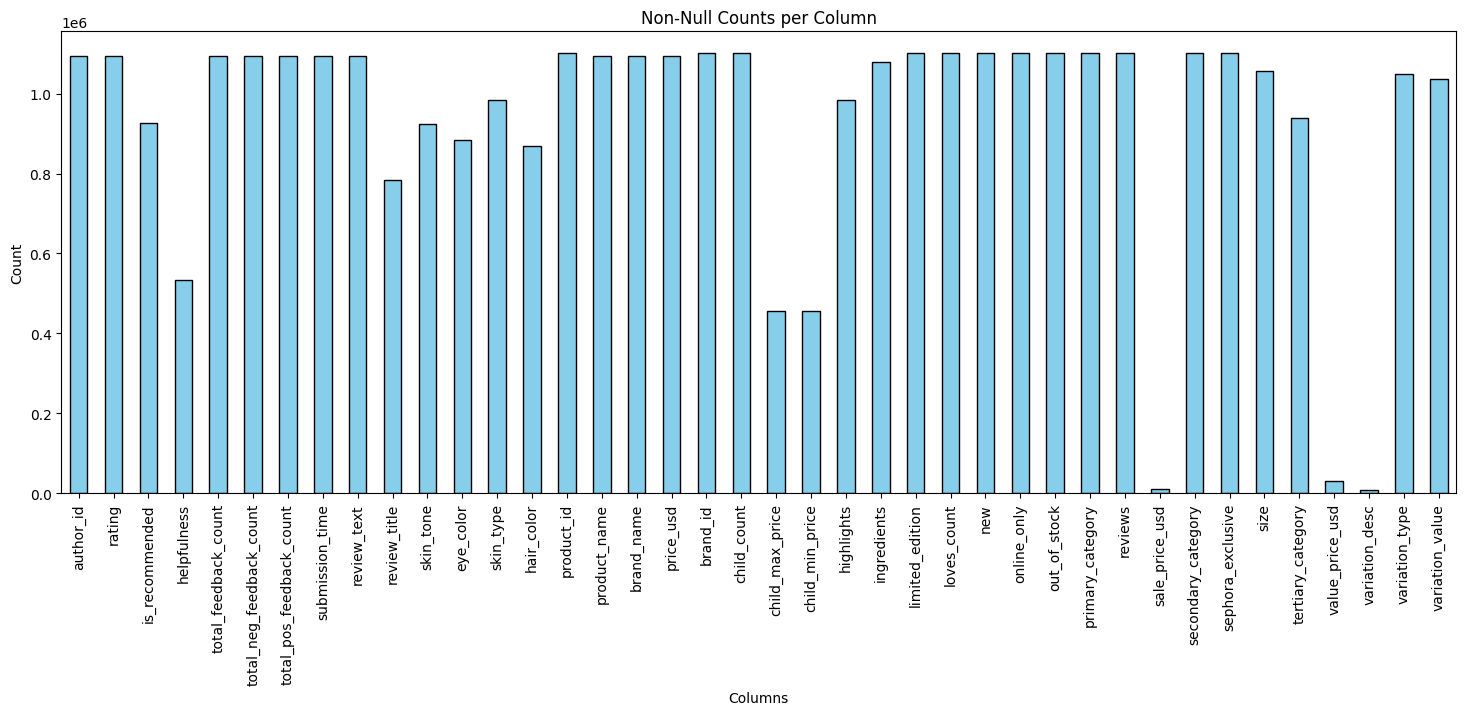

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

non_null_counts = df.notnull().sum()
plt.figure(figsize=(18, 6))
non_null_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Non-Null Counts per Column")
plt.ylabel("Count")
plt.xlabel("Columns")
plt.xticks(rotation=90)
plt.show()


##### Here, the barplot is showing the columns with values

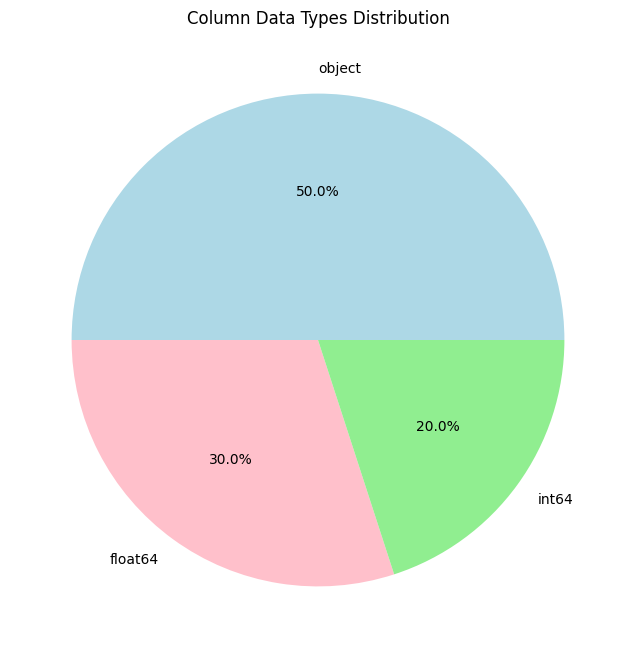

In [21]:
column_types = df.dtypes.value_counts()
column_types.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8), colors=['lightblue', 'pink', 'lightgreen'])
plt.title("Column Data Types Distribution")
plt.ylabel("")  # Removes the y-axis label
plt.show()


In [24]:
df.isna().sum()

author_id                      6143
rating                         6143
is_recommended               174131
helpfulness                  567735
total_feedback_count           6143
total_neg_feedback_count       6143
total_pos_feedback_count       6143
submission_time                6143
review_text                    7587
review_title                 316797
skin_tone                    176682
eye_color                    215771
skin_type                    117700
hair_color                   232911
product_id                        0
product_name                   6143
brand_name                     6143
price_usd                      6143
brand_id                          0
child_count                       0
child_max_price              644796
child_min_price              644796
highlights                   115729
ingredients                   22843
limited_edition                   0
loves_count                       0
new                               0
online_only                 

##### Dropping the columns with high number of missing values

In [25]:
df_cleaned = df.drop(columns = ['child_max_price',
                                    'child_min_price',
                                    'sale_price_usd',
                                    'value_price_usd',
                                    'variation_desc',
                                    'review_title',
                                    'author_id',
                                    ])
df_cleaned

,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,skin_tone,eye_color,...,online_only,out_of_stock,primary_category,reviews,secondary_category,sephora_exclusive,size,tertiary_category,variation_type,variation_value
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Makeup,159.0,Eye,1,0.04 oz/ 1.2 mL,Eyeliner,Size,0.04 oz/ 1.2 mL
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Makeup,96.0,Eye,1,12 x 0.03 oz/ 1 g,Eye Palettes,Size,12 x 0.03 oz/ 1 g
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Makeup,490.0,Brushes & Applicators,1,NaN,Face Brushes,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Makeup,111.0,Eye,1,NaN,Eye Primer,Color,Medium
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Bath & Body,819.0,Body Moisturizers,0,3 oz/ 90 mL,Body Lotions & Body Oils,Color,Cognac Candy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1100549,5.0,NaN,1.0,3.0,0.0,3.0,2008-09-11,"Clean rinse gel, does not leave face tight but...",fair,NaN,...,0,0,Skincare,391.0,Cleansers,0,6.5 oz,Face Wash & Cleansers,Size,6.5 oz
1100550,5.0,NaN,1.0,5.0,0.0,5.0,2008-09-11,I love the way this feels on my face. It clean...,tan,NaN,...,0,0,Skincare,391.0,Cleansers,0,6.5 oz,Face Wash & Cleansers,Size,6.5 oz
1100551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Makeup,1145.0,Cheek,0,0.32 oz/ 9 g,Bronzer,Color,Park Ave Princess
1100552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,Makeup,2867.0,Eye,0,0.38 oz/ 11.5 mL,Mascara,Color,Catwalk Black


In [26]:
df_cleaned.shape

(1100554, 33)

##### Dropping Rows
- Drop rows with missing values

In [27]:
df_cleaned.dropna(axis=0,inplace=True)

In [28]:
df_cleaned.isna().sum()

rating                      0
is_recommended              0
helpfulness                 0
total_feedback_count        0
total_neg_feedback_count    0
total_pos_feedback_count    0
submission_time             0
review_text                 0
skin_tone                   0
eye_color                   0
skin_type                   0
hair_color                  0
product_id                  0
product_name                0
brand_name                  0
price_usd                   0
brand_id                    0
child_count                 0
highlights                  0
ingredients                 0
limited_edition             0
loves_count                 0
new                         0
online_only                 0
out_of_stock                0
primary_category            0
reviews                     0
secondary_category          0
sephora_exclusive           0
size                        0
tertiary_category           0
variation_type              0
variation_value             0
dtype: int

In [29]:
df_cleaned.shape

(304400, 33)

In [30]:
df_cleaned.describe()

,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,price_usd,brand_id,child_count,limited_edition,loves_count,new,online_only,out_of_stock,reviews,sephora_exclusive
count,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000,304400.000000
mean,4.064179,0.768374,0.766871,8.725085,1.884238,6.840848,49.244434,5943.436101,0.818242,0.018991,122587.476097,0.011570,0.064714,0.017934,1737.387710,0.425135
std,1.350590,0.421872,0.316796,31.211750,7.438132,27.058110,40.233560,1140.218908,1.269728,0.136495,149997.349650,0.106941,0.246021,0.132711,1719.687076,0.494364
min,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,3.000000,1063.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,3.000000,1.000000,0.640000,2.000000,0.000000,1.000000,28.000000,5987.000000,0.000000,0.000000,24635.000000,0.000000,0.000000,0.000000,476.000000,0.000000
50%,5.000000,1.000000,0.923077,4.000000,1.000000,3.000000,42.000000,6189.000000,0.000000,0.000000,64038.000000,0.000000,0.000000,0.000000,1121.000000,0.000000
75%,5.000000,1.000000,1.000000,8.000000,2.000000,6.000000,62.000000,6285.000000,1.000000,0.000000,169217.000000,0.000000,0.000000,0.000000,2449.000000,1.000000
max,5.000000,1.000000,1.000000,3851.000000,1094.000000,3481.000000,425.000000,8017.000000,13.000000,1.000000,763168.000000,1.000000,1.000000,1.000000,8733.000000,1.000000


# Exploratory Data Analysis

In this section, I will perform an exploratory data analysis (EDA) on the dataset. The goal of EDA is to gain insights and understanding of the dataset, identify patterns, relationships, and anomalies. Through EDA, we can make informed decisions on how to preprocess and model the data, as well as generate hypotheses for further analysis.

"I will start by analyzing the submission_time of the data and create new columns for day, month, year, and weekday. This will enable me to analyze various factors such as total_feedback_count, total_pos_feedback_count, total_neg_feedback_count, and their trends over the years."

Analyze the distribution of numerical features (e.g., rating, total_feedback_count)

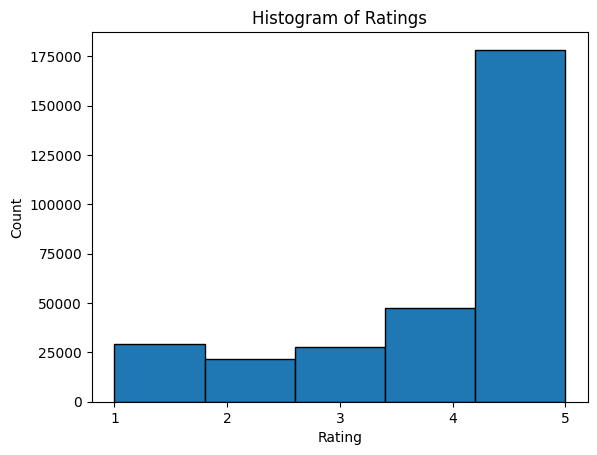

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the histogram
plt.hist(df_cleaned['rating'], bins=5, range=(1, 5), edgecolor='black')  # Ensuring bins from 1 to 5
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Histogram of Ratings')
plt.xticks([1, 2, 3, 4, 5])  # Ensuring ticks match the rating scale
plt.show()

Compare features like rating against is_recommended

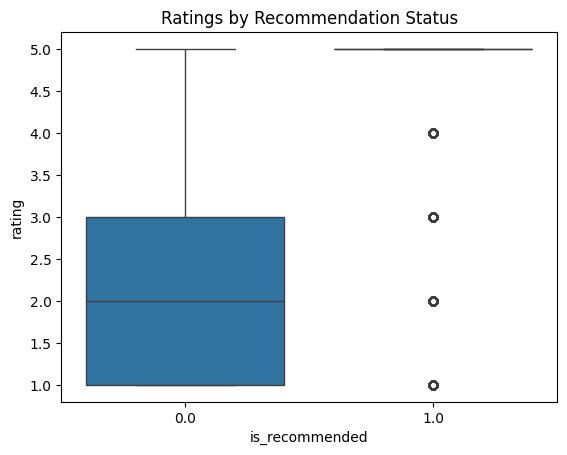

In [32]:
sns.boxplot(data=df_cleaned, x='is_recommended', y='rating')
plt.title('Ratings by Recommendation Status')
plt.show()


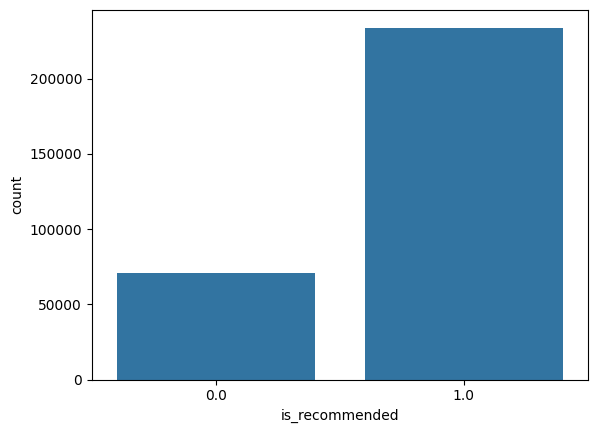

In [33]:
sns.countplot(x=df_cleaned['is_recommended'])
plt.show()

Examine the distribution of categorical variables (e.g., skin_tone, primary_category

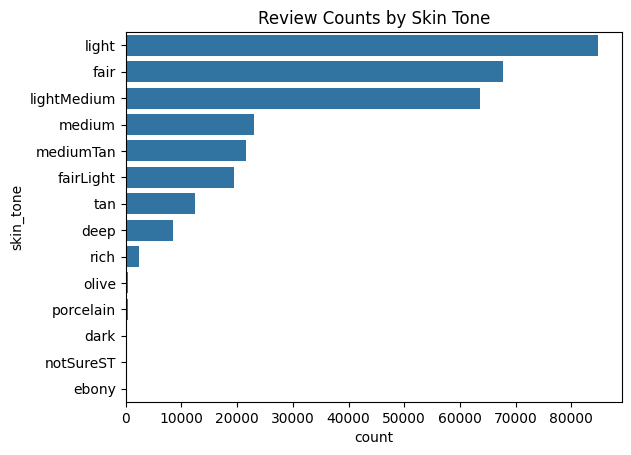

In [34]:
sns.countplot(data=df_cleaned, y='skin_tone', order=df_cleaned['skin_tone'].value_counts().index)
plt.title('Review Counts by Skin Tone')
plt.show()


Explore relationships between numeric features using scatter plots or correlation matrices:

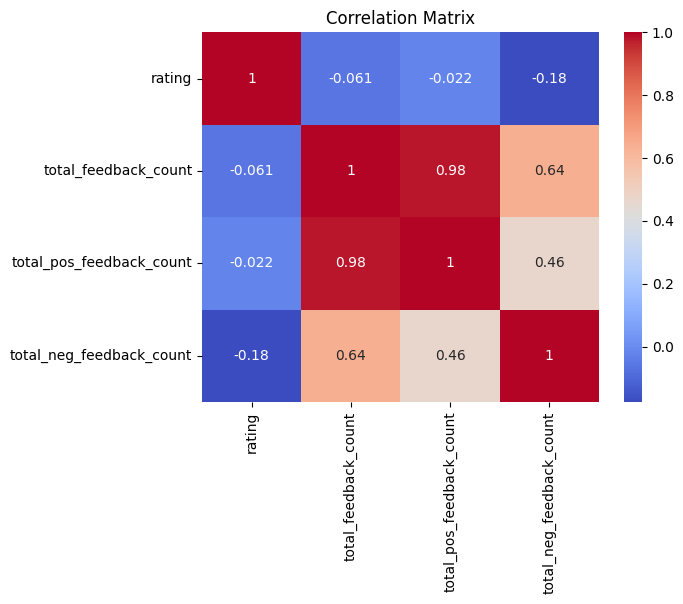

In [35]:
correlation_matrix = df_cleaned[['rating', 'total_feedback_count', 'total_pos_feedback_count', 'total_neg_feedback_count']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


Time Series Analysis

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/606663429.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_cleaned.set_index('submission_time').resample('M')['rating'].mean().plot()


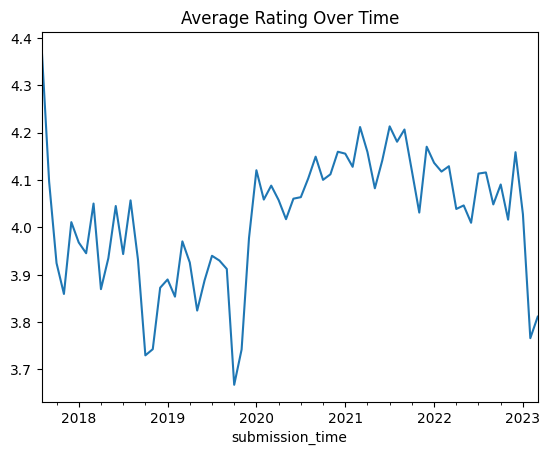

In [36]:
df_cleaned['submission_time'] = pd.to_datetime(df_cleaned['submission_time'])

df_cleaned.set_index('submission_time').resample('M')['rating'].mean().plot()
plt.title('Average Rating Over Time')
plt.show()


Exploring Categories and Sizes

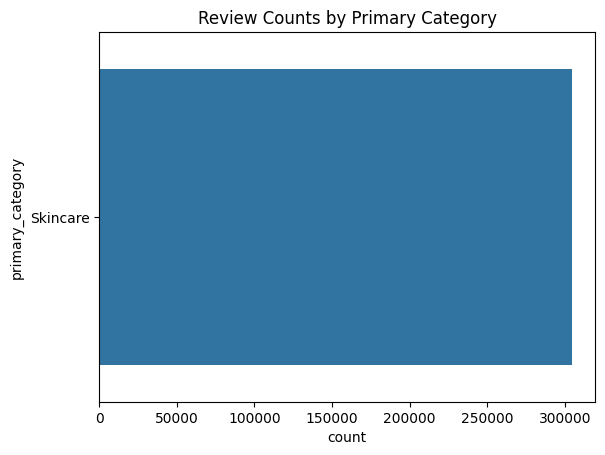

In [37]:
sns.countplot(data=df_cleaned, y='primary_category', order=df_cleaned['primary_category'].value_counts().index)
plt.title('Review Counts by Primary Category')
plt.show()


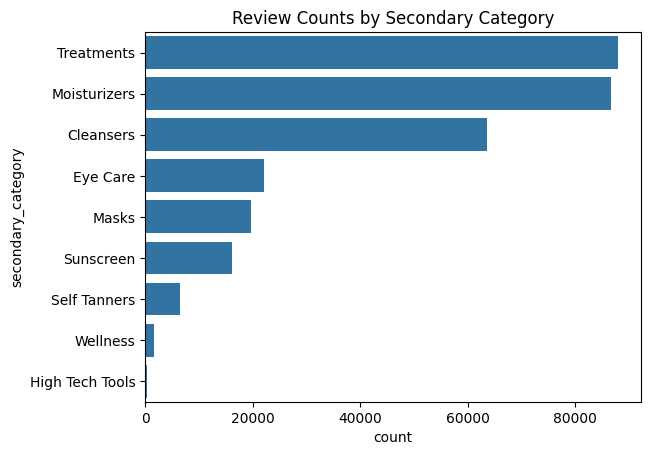

In [39]:
sns.countplot(data=df_cleaned, y='secondary_category', order=df_cleaned['secondary_category'].value_counts().index)
plt.title('Review Counts by Secondary Category')
plt.show()

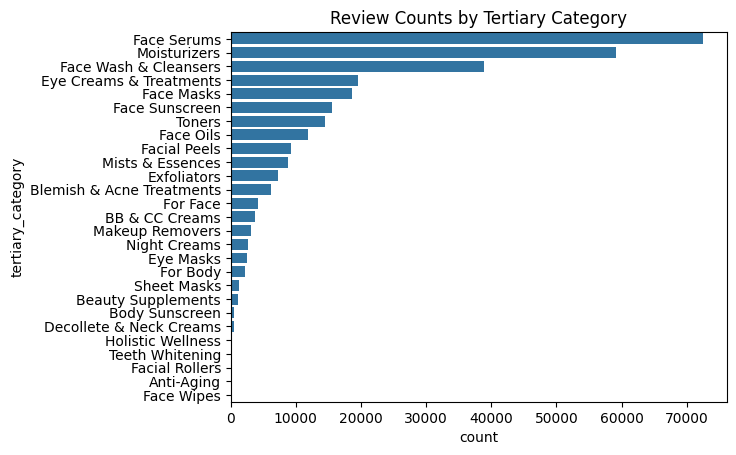

In [40]:

sns.countplot(data=df_cleaned, y='tertiary_category', order=df_cleaned['tertiary_category'].value_counts().index)
plt.title('Review Counts by Tertiary Category')
plt.show()

#### Aggregating the plots for all three categories

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/166834064.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y='primary_category', ax=ax1, palette='Blues')
/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/166834064.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y='secondary_category', ax=ax2, palette='Greens')
/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/166834064.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_cleaned, y='tertia

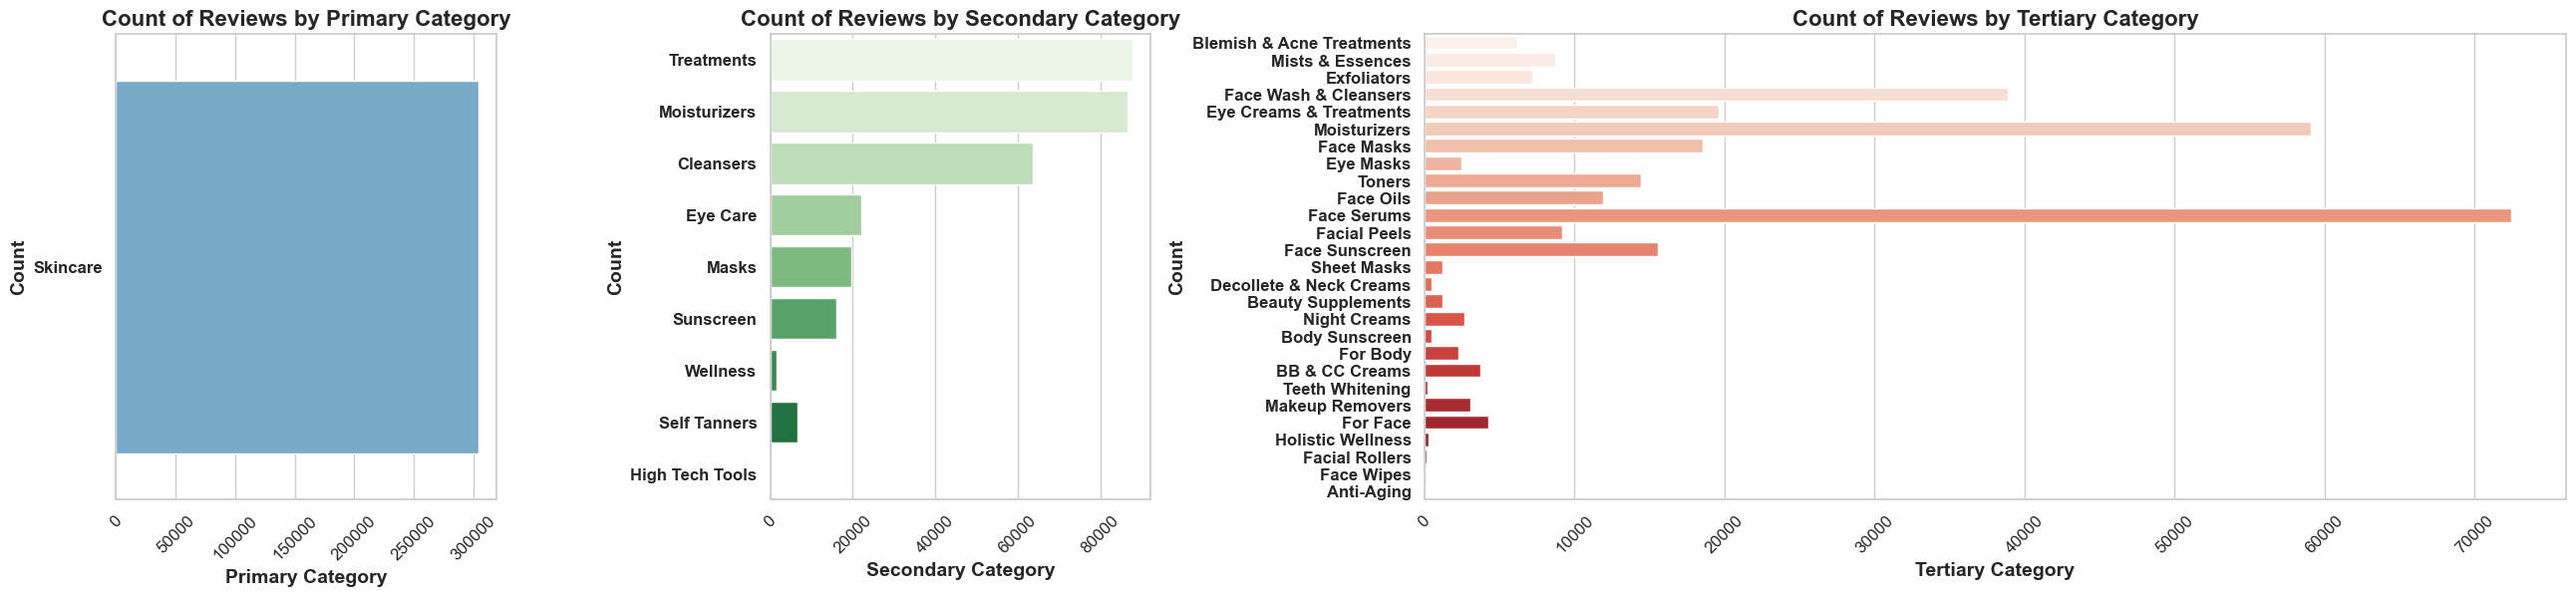

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of seaborn plots
sns.set(style="whitegrid")

# Set up subplots with different widths (using gridspec for custom width ratios)
fig = plt.figure(figsize=(26, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 3])  # Adjust the width ratio for the third plot

# Create axes for each subplot
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Plot countplot for primary_category
sns.countplot(data=df_cleaned, y='primary_category', ax=ax1, palette='Blues')
ax1.set_title('Count of Reviews by Primary Category', fontweight='bold', fontsize=16)  # Increase title fontsize
ax1.set_xlabel('Primary Category', fontweight='bold', fontsize=14)  # Increase xlabel fontsize
ax1.set_ylabel('Count', fontweight='bold', fontsize=14)  # Increase ylabel fontsize
ax1.tick_params(axis='y', labelsize=12)  # Adjust y-axis label size
ax1.tick_params(axis='x', rotation=45, labelsize=12)  # Adjust x-axis tick label size
for label in ax1.get_yticklabels():  # Loop over the y-tick labels
    label.set_fontweight('bold')  # Set each y-tick label to bold

# Plot countplot for secondary_category
sns.countplot(data=df_cleaned, y='secondary_category', ax=ax2, palette='Greens')
ax2.set_title('Count of Reviews by Secondary Category', fontweight='bold', fontsize=16)  # Increase title fontsize
ax2.set_xlabel('Secondary Category', fontweight='bold', fontsize=14)  # Increase xlabel fontsize
ax2.set_ylabel('Count', fontweight='bold', fontsize=14)  # Increase ylabel fontsize
ax2.tick_params(axis='y', labelsize=12)  # Adjust y-axis label size
ax2.tick_params(axis='x', rotation=45, labelsize=12)  # Adjust x-axis tick label size
for label in ax2.get_yticklabels():  # Loop over the y-tick labels
    label.set_fontweight('bold')  # Set each y-tick label to bold

# Plot countplot for tertiary_category
sns.countplot(data=df_cleaned, y='tertiary_category', ax=ax3, palette='Reds')
ax3.set_title('Count of Reviews by Tertiary Category', fontweight='bold', fontsize=16)  # Increase title fontsize
ax3.set_xlabel('Tertiary Category', fontweight='bold', fontsize=14)  # Increase xlabel fontsize
ax3.set_ylabel('Count', fontweight='bold', fontsize=14)  # Increase ylabel fontsize
ax3.tick_params(axis='y', labelsize=12)  # Adjust y-axis label size
ax3.tick_params(axis='x', rotation=45, labelsize=12)  # Adjust x-axis tick label size
for label in ax3.get_yticklabels():  # Loop over the y-tick labels
    label.set_fontweight('bold')  # Set each y-tick label to bold

# Adjust layout and display the plots
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Adjust this to make more space for x-tick labels

# Show the plot
plt.show()







##### Creating the columns for 'year', 'month', 'day' and 'weekday'

In [42]:
df_cleaned['submission_time'] = pd.to_datetime(df_cleaned['submission_time'])

df_cleaned['year']= df_cleaned['submission_time'].dt.year

df_cleaned['month']= df_cleaned['submission_time'].dt.month

df_cleaned['day']= df_cleaned['submission_time'].dt.day

df_cleaned['weekday']= df_cleaned['submission_time'].dt.weekday

dw_mapping={
    0: 'Monday', 
    1: 'Tuesday', 
    2: 'Wednesday', 
    3: 'Thursday', 
    4: 'Friday',
    5: 'Saturday', 
    6: 'Sunday'
} 

df_cleaned['dayofweek']= df_cleaned['submission_time'].dt.weekday.map(dw_mapping)

##### Trying to do some analysis based on time  
- Rating over years
- Feedbacks over years
- helpfullness vs feedback


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1278485767.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_cleaned.set_index('submission_time').resample('M')['rating'].mean().plot(ax=axes[0], color='blue')


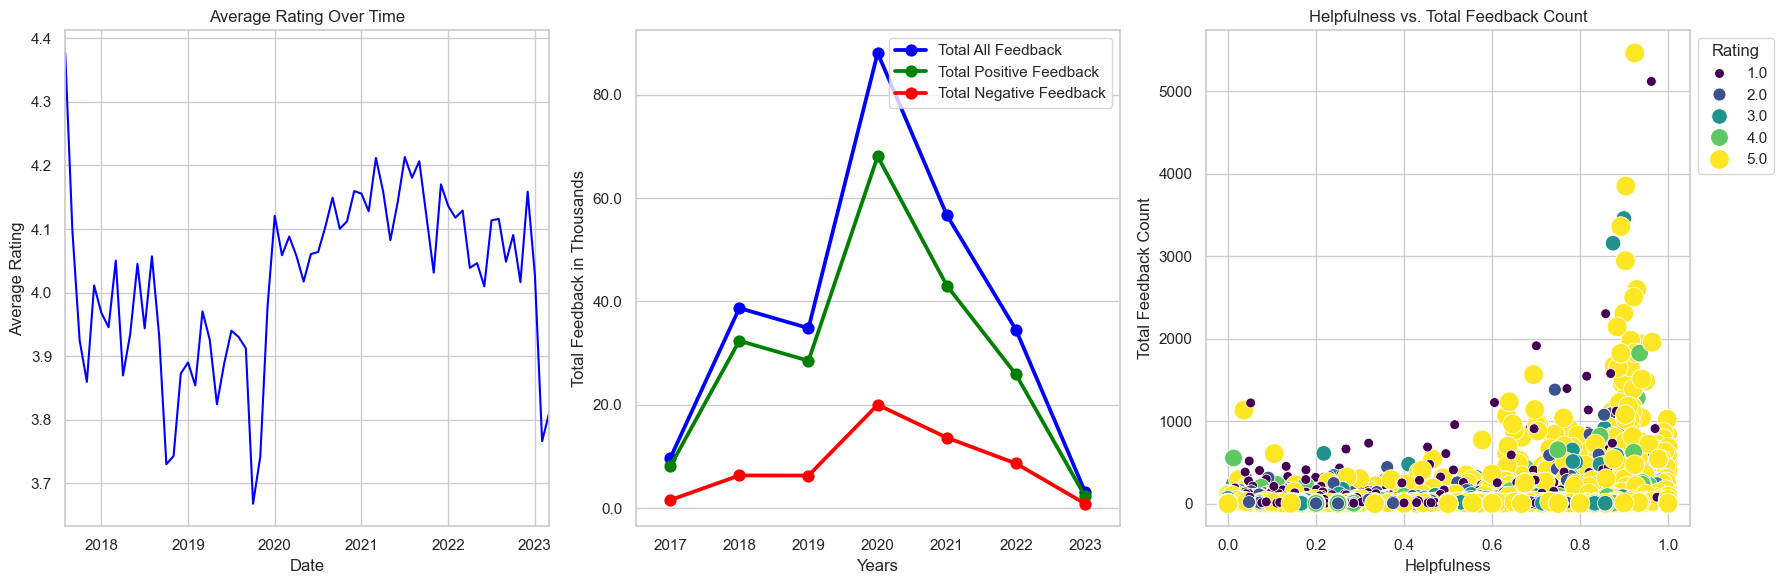

In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'submission_time' to datetime if not already done
df_cleaned['submission_time'] = pd.to_datetime(df_cleaned['submission_time'])

# Set up the subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define a custom formatter for the y-axis
def hundformatter(x, pos):
    return str(round(x / 1e4, 1))

# 1. Line graph: Average rating over time (monthly)
df_cleaned.set_index('submission_time').resample('M')['rating'].mean().plot(ax=axes[0], color='blue')
axes[0].set_title('Average Rating Over Time')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Rating')

# 2. Point plot: Total Feedback Count by Year (replacing the Line graph)
# Group by year and sum feedback counts
total_feedback = df_cleaned.groupby('year').sum(numeric_only=True)['total_feedback_count'].reset_index()
sns.pointplot(total_feedback, x='year', y='total_feedback_count', color="blue", label="Total All Feedback", ax=axes[1])

# Plot Positive Feedback count
total_pos_feedback = df_cleaned.groupby('year').sum(numeric_only=True)['total_pos_feedback_count'].reset_index()
sns.pointplot(total_pos_feedback, x='year', y='total_pos_feedback_count', color="green", label="Total Positive Feedback", ax=axes[1])

# Plot Negative Feedback count
total_neg_feedback = df_cleaned.groupby('year').sum(numeric_only=True)['total_neg_feedback_count'].reset_index()
sns.pointplot(total_neg_feedback, x='year', y='total_neg_feedback_count', color="red", label="Total Negative Feedback", ax=axes[1])

# Apply y-axis formatting and labels
axes[1].yaxis.set_major_formatter(hundformatter)
axes[1].set_ylabel("Total Feedback in Thousands")
axes[1].set_xlabel("Years")
axes[1].legend()

# 3. Scatterplot: Helpfulness vs. Total Feedback Count
sns.scatterplot(
    x='helpfulness', 
    y='total_feedback_count', 
    hue='rating', 
    size='rating', 
    data=df, 
    palette='viridis', 
    sizes=(50, 200), 
    ax=axes[2]
)
axes[2].set_title('Helpfulness vs. Total Feedback Count')
axes[2].set_ylabel('Total Feedback Count')
axes[2].set_xlabel('Helpfulness')
axes[2].legend(title='Rating', loc='upper left', bbox_to_anchor=(1, 1))

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


##### Recommendation vs Feedback

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/4027683193.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_cleaned, x='is_recommended', y='total_pos_feedback_count', ci=None)


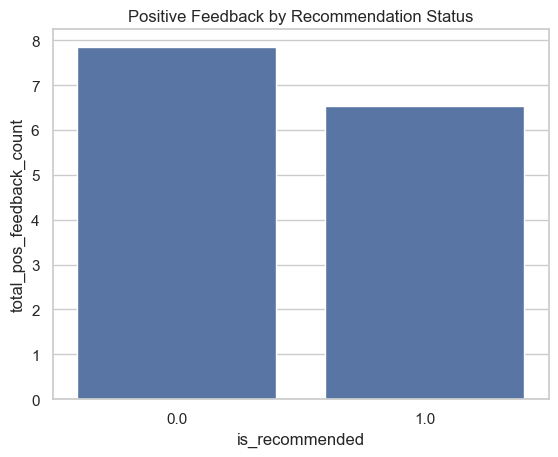

In [45]:
sns.barplot(data=df_cleaned, x='is_recommended', y='total_pos_feedback_count', ci=None)
plt.title('Positive Feedback by Recommendation Status')
plt.show()


##### Out-of-Stock and Online-Only 

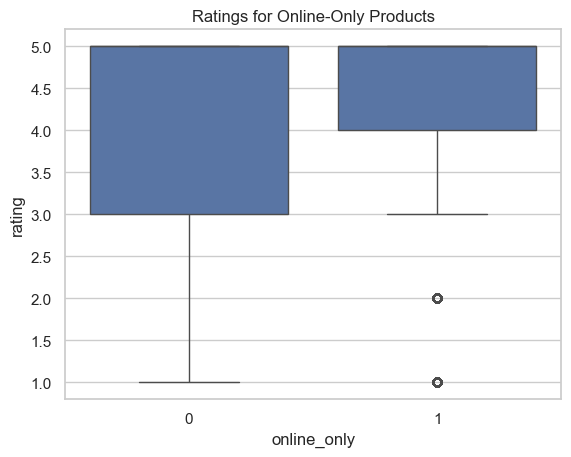

In [46]:
sns.boxplot(data=df_cleaned, x='online_only', y='rating')
plt.title('Ratings for Online-Only Products')
plt.show()


##### Trying to get some idea based on the products recommendation and helpfulness
- Top 10 most recommended products
-  Top 10 most helpfulness products

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/767634684.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(most_reccomended,x='is_recommended',y='product_name',ax=ax1, palette='viridis')
/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/767634684.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(most_helpfulness,x='helpfulness',y='product_name',ax=ax2, palette='mako')


Text(0.5, 0.98, 'Top 10 Product')

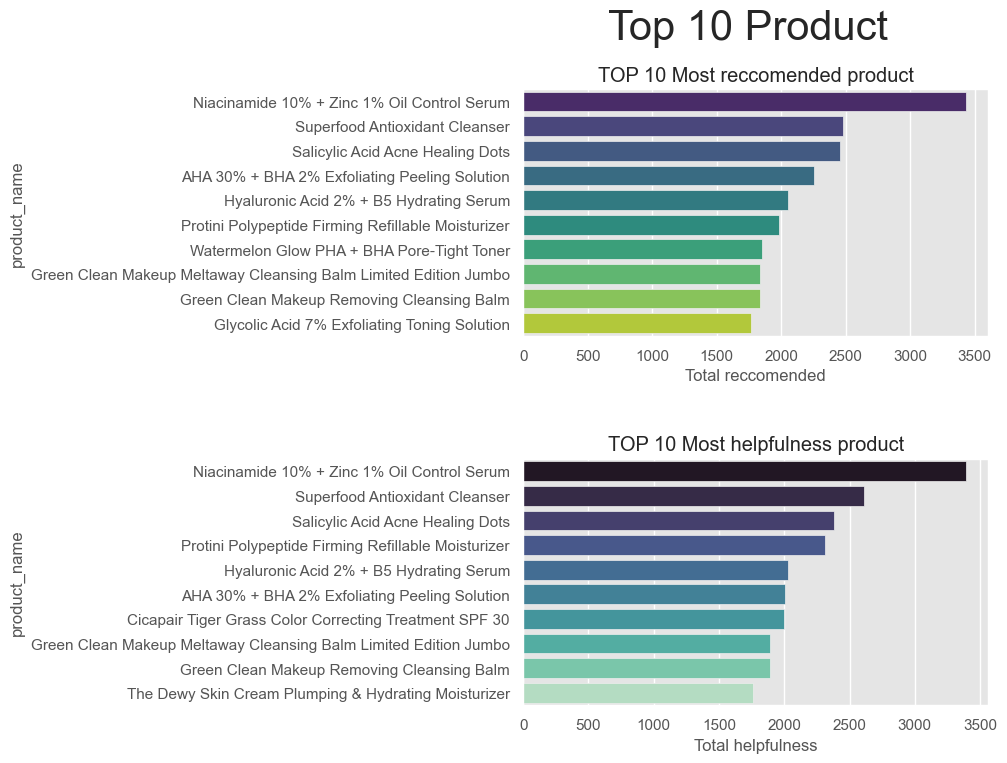

In [48]:
#Top 10  product
fig, (ax1,ax2) = plt.subplots(nrows=2,ncols=1,figsize= (6,8))
fig.subplots_adjust(hspace=0.5)

most_reccomended = df_cleaned.groupby(['product_id','product_name','brand_name']).sum(numeric_only=True)['is_recommended'].reset_index()\
.sort_values('is_recommended',ascending=False).head(10)
sns.barplot(most_reccomended,x='is_recommended',y='product_name',ax=ax1, palette='viridis')
ax1.set_title("TOP 10 Most reccomended product")
ax1.set_xlabel("Total reccomended")

most_helpfulness = df_cleaned.groupby(['product_id','product_name','brand_name']).sum(numeric_only=True)['helpfulness'].reset_index()\
.sort_values('helpfulness',ascending=False).head(10)
sns.barplot(most_helpfulness,x='helpfulness',y='product_name',ax=ax2, palette='mako')
ax2.set_title("TOP 10 Most helpfulness product")
ax2.set_xlabel("Total helpfulness")

plt.suptitle("Top 10 Product",fontsize=30)

##### Top 10 expensive and cheapest products

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1660038468.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(most_expensive, x='price_usd', y='product_name', ax=ax1, palette='mako')
/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1660038468.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(cheapest, x='price_usd', y='product_name', ax=ax2, palette='mako')


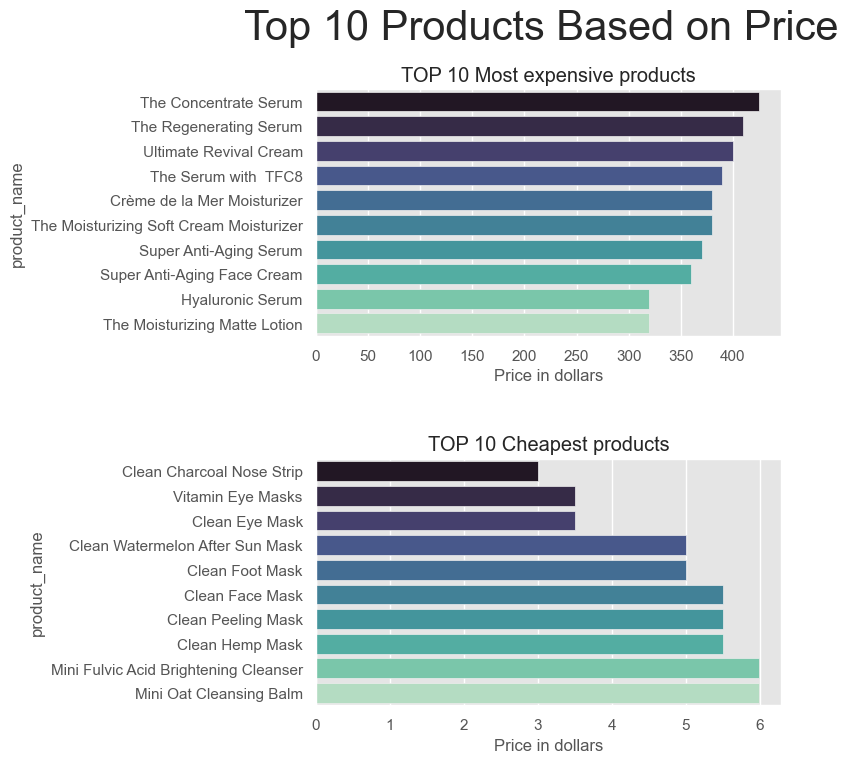

In [49]:
# Set up the figure and subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(6, 8))
fig.subplots_adjust(hspace=0.5)

# Most expensive products
most_expensive = df_cleaned.groupby(['product_id', 'product_name', 'price_usd']).sum(numeric_only=True).reset_index() \
    .sort_values('price_usd', ascending=False).head(10)

sns.barplot(most_expensive, x='price_usd', y='product_name', ax=ax1, palette='mako')
ax1.set_title("TOP 10 Most expensive products")
ax1.set_xlabel("Price in dollars")

# Cheapest products
cheapest = df_cleaned.groupby(['product_id', 'product_name', 'price_usd']).sum(numeric_only=True).reset_index() \
    .sort_values('price_usd', ascending=True).head(10)

sns.barplot(cheapest, x='price_usd', y='product_name', ax=ax2, palette='mako')
ax2.set_title("TOP 10 Cheapest products")
ax2.set_xlabel("Price in dollars")

# Add a title for the entire figure
plt.suptitle("Top 10 Products Based on Price", fontsize=30)

# Show the plots
plt.show()



##### Top ten products with highest ratings

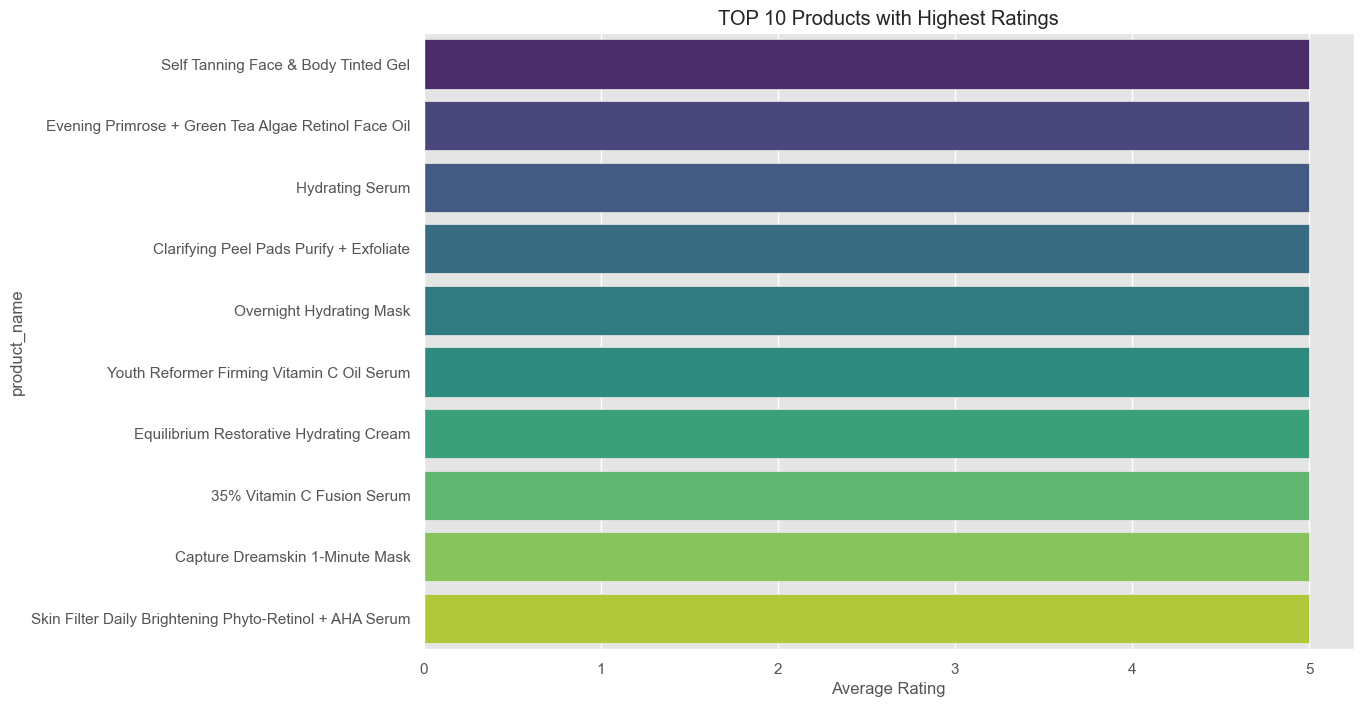

In [50]:
# Group by product and calculate the average rating
top_rated_products = df_cleaned.groupby(['product_id', 'product_name', 'brand_name'])['rating'].mean().reset_index()

# Sort the products by average rating in descending order and select the top 10
top_rated_products = top_rated_products.sort_values('rating', ascending=False).head(10)


fig, ax2 = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_rated_products, x='rating', y='product_name', ax=ax2, hue='product_name', palette='viridis', legend=False)

# Customize the plot
ax2.set_title("TOP 10 Products with Highest Ratings")
ax2.set_xlabel("Average Rating")

plt.show()

##### Most rated products base on skin type
- Top 10 product based on rating and price for normal skin type
- Top 10 product based on rating and price for dry skin type
- Top 10 product based on rating and price for oily skin type
- Top 10 product based on rating and price for combination skin type

Text(0.5, 0.98, 'Most reccomended product for each skin types')

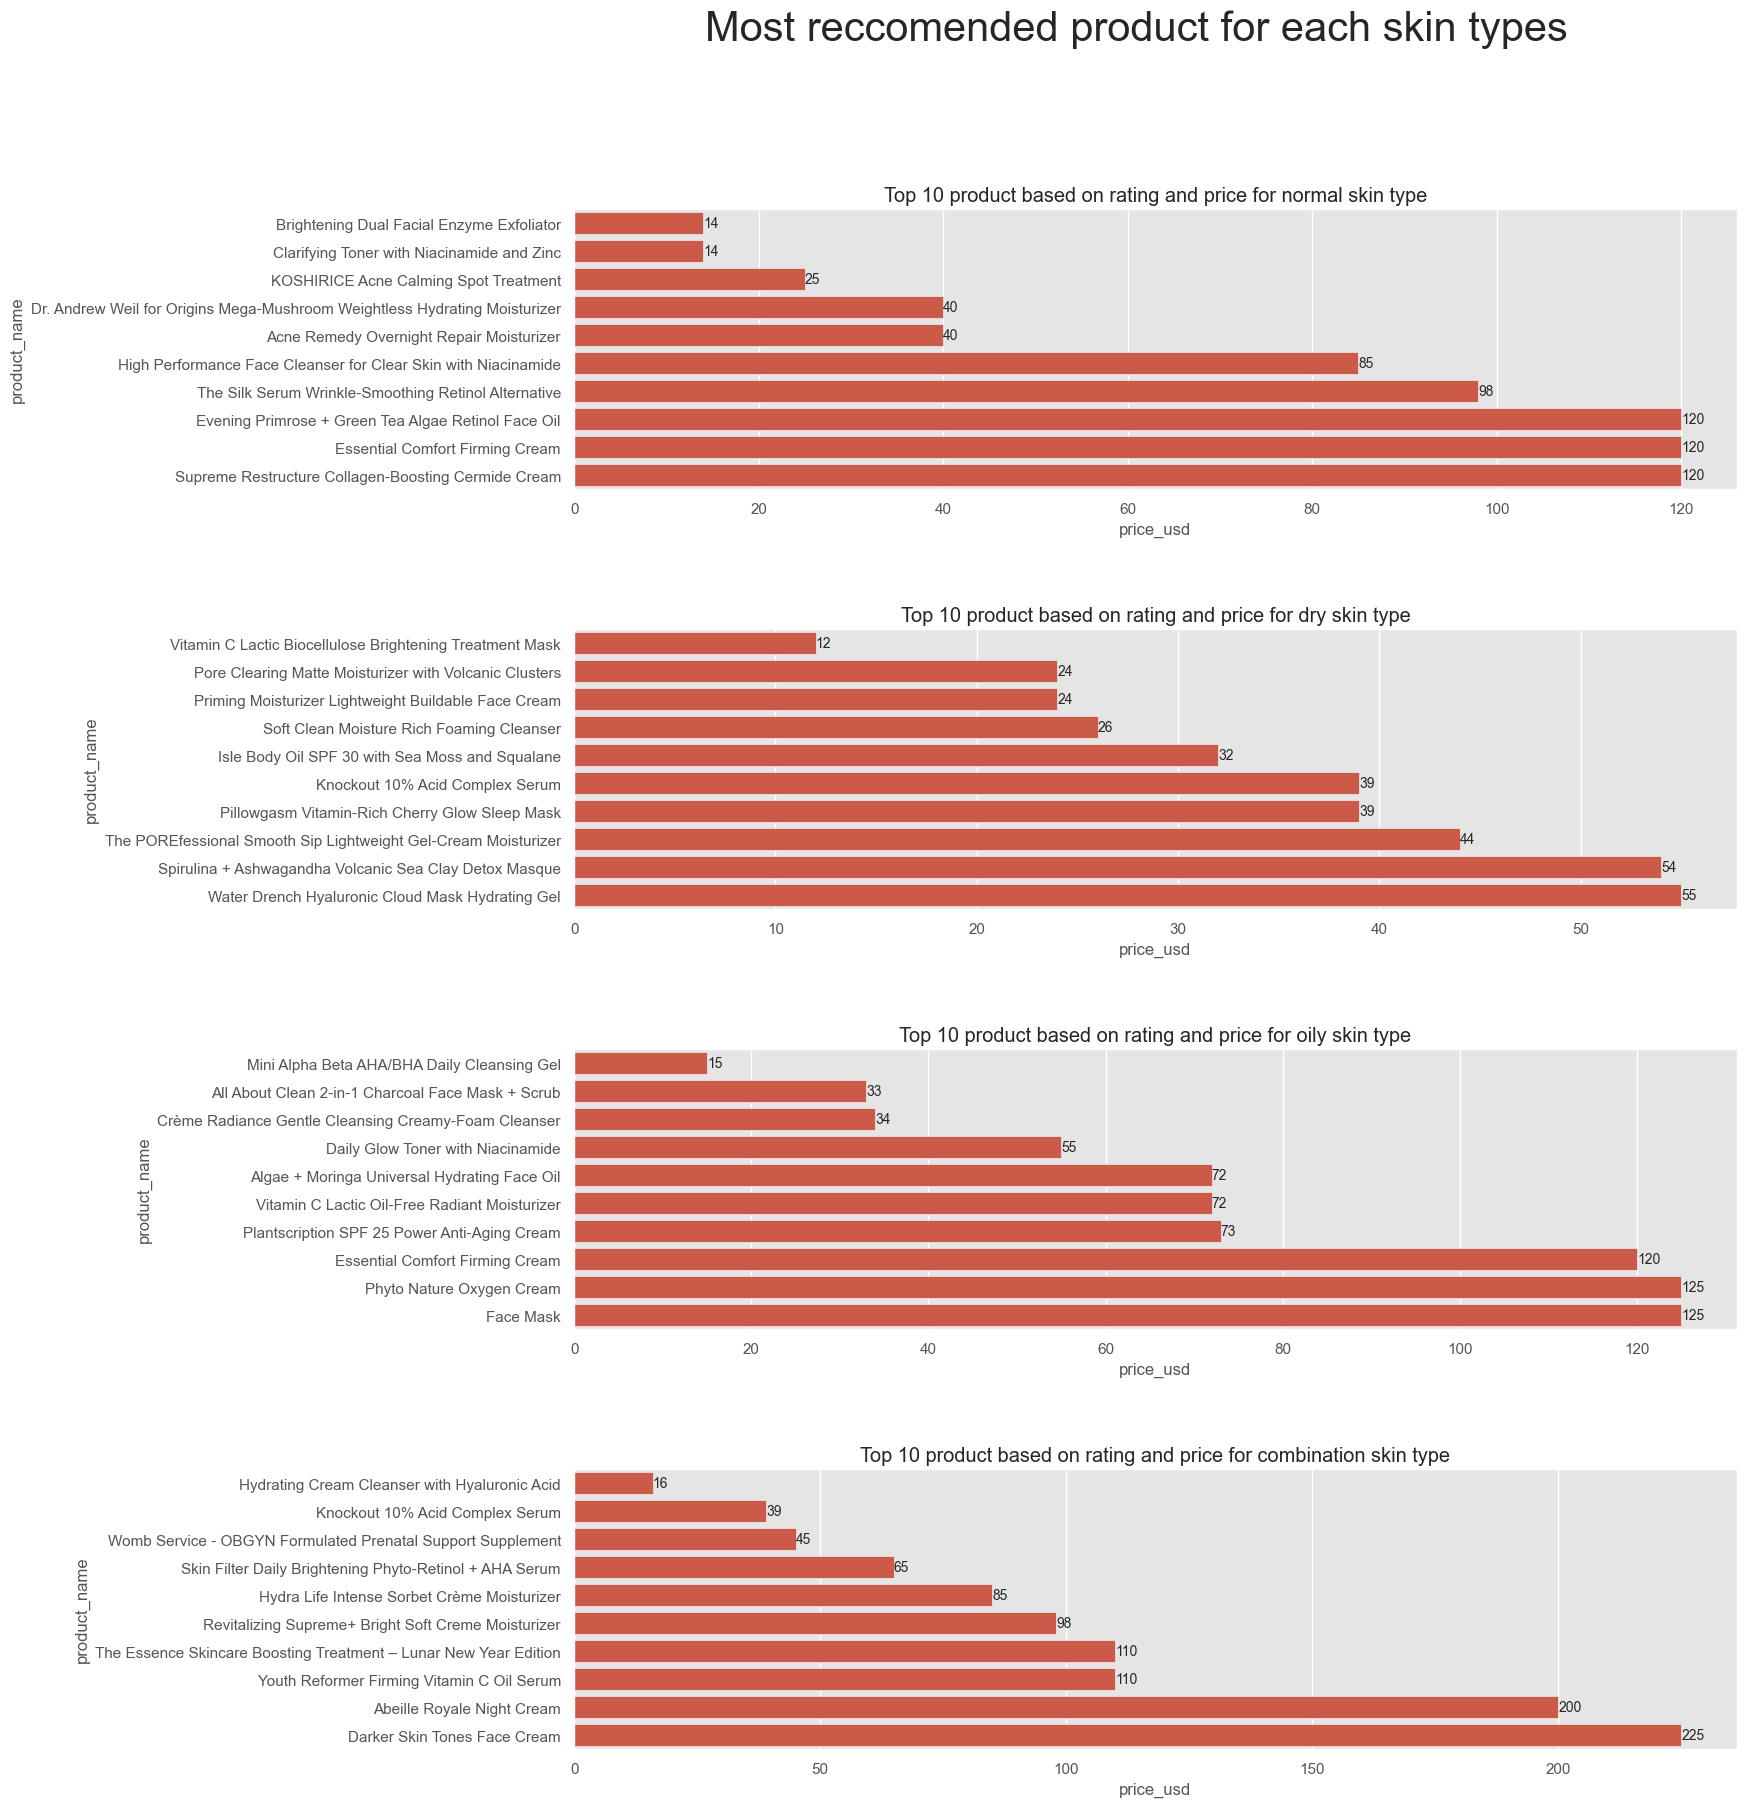

In [51]:
# Most reccomended product for each skin_type
fig, (ax1,ax2,ax3,ax4) = plt.subplots(nrows=4,ncols=1,figsize= (15,20))
fig.subplots_adjust(hspace=0.5)

product_skin = df_cleaned.groupby(['skin_type','product_id','product_name','price_usd']).mean(numeric_only=True)['rating'].reset_index()\
.sort_values('rating',ascending=False)

normal_skin = product_skin[product_skin['skin_type'] == 'normal'].sort_values('price_usd',ascending=True)\
.sort_values(['rating'],ascending=False).head(10)\
.sort_values('price_usd',ascending=True)
ax1 = sns.barplot(normal_skin,x='price_usd',y='product_name',ax=ax1)
ax1.set_title("Top 10 product based on rating and price for normal skin type")
for i in ax1.containers:
    ax1.bar_label(i)
    
dry_skin = product_skin[product_skin['skin_type'] == 'dry'].sort_values('price_usd',ascending=True)\
.sort_values(['rating'],ascending=False).head(10)\
.sort_values('price_usd',ascending=True)
ax2 = sns.barplot(dry_skin,x='price_usd',y='product_name',ax=ax2)
ax2.set_title("Top 10 product based on rating and price for dry skin type")
for i in ax2.containers:
    ax2.bar_label(i)    
    
oily_skin = product_skin[product_skin['skin_type'] == 'oily'].sort_values('price_usd',ascending=True)\
.sort_values(['rating'],ascending=False).head(10)\
.sort_values('price_usd',ascending=True)
ax3 = sns.barplot(oily_skin,x='price_usd',y='product_name',ax=ax3)
ax3.set_title("Top 10 product based on rating and price for oily skin type")
for i in ax3.containers:
    ax3.bar_label(i)    
    
combination_skin = product_skin[product_skin['skin_type'] == 'combination'].sort_values('price_usd',ascending=True)\
.sort_values(['rating'],ascending=False).head(10)\
.sort_values('price_usd',ascending=True)
ax4 = sns.barplot(combination_skin,x='price_usd',y='product_name',ax=ax4)
ax4.set_title("Top 10 product based on rating and price for combination skin type")
for i in ax4.containers:
    ax4.bar_label(i)    

fig.suptitle("Most reccomended product for each skin types",fontsize=30)  
    

<Axes: xlabel='loves_count', ylabel='price_usd'>

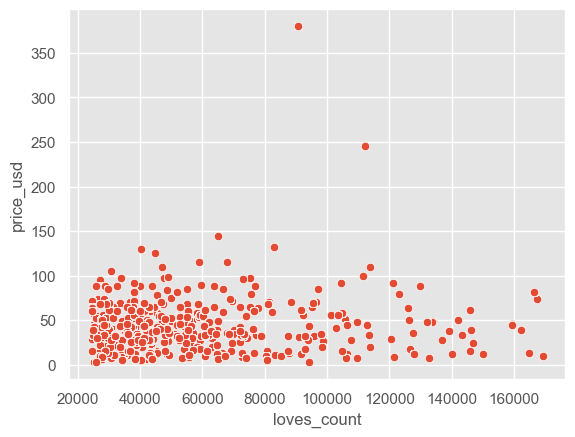

In [52]:
# Lets see the relationship between loves_count and the price_usd of the product
def remove_outliers(data, lower_quantile=0.25, upper_quantile=0.75):
    lower_bound = np.quantile(data, lower_quantile)
    upper_bound = np.quantile(data, upper_quantile)
    cleaned_data = data[(data >= lower_bound) & (data <= upper_bound)]
    return cleaned_data
# Remove outliers using quantiles (5th percentile to 95th percentile)
cleaned_data = remove_outliers(df_cleaned['loves_count'], lower_quantile=0.25, upper_quantile=0.75)

sns.scatterplot(df_cleaned,x = cleaned_data,y=df_cleaned['price_usd'])

<Axes: xlabel='is_recommended', ylabel='helpfulness'>

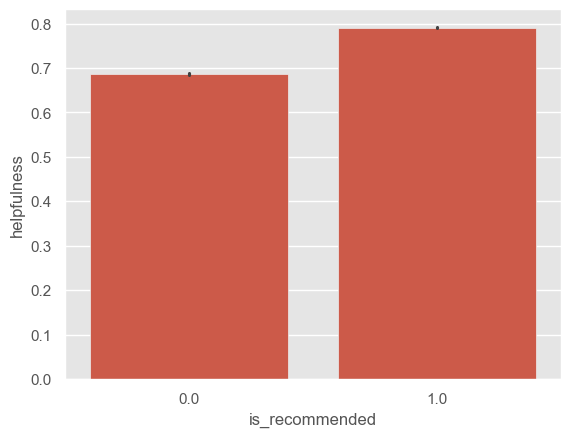

In [53]:
# Lets see is higher the is_recommended score also higher of helpfulness the product
sns.barplot(df_cleaned,y = df_cleaned['helpfulness'],x=df_cleaned['is_recommended'])

# In this final project, we have three reserach question
- Can we perform Sentiment Analysis?
- Can we recommend products?
- Can we do customer segmentation based on the success of products or brands?

### Can we perform Sentiment Analysis?
- By analyzing textual data, we can extract actionable insights that enable Sephora to make data-driven decisions and improve customer experiences.

Sentiment analysis is the process of analyzing digital text to determine if the emotional tone of the message is positive, negative, or neutral

"I will attempt to build a model to categorize products as recommended or not, based on customer review_text.

The first step is to load the dataset and select the necessary columns.

Since the dataset is large, I will downsize it to expedite the model training process.

Additionally, we are dealing with an imbalanced dataset, so I will balance the labels."

In [54]:
df_sentiment = df_cleaned[['review_text','is_recommended']]
df_sentiment.head(5)

,review_text,is_recommended
277,I wanted to try these to help with the texture...,1.0
278,I’ve only been using this product for a few we...,1.0
279,"￼ Ever since I’ve started using this, I’ve had...",1.0
280,I am in love with these must have acne pads. A...,1.0
282,I’m so thankful that I discovered this product...,1.0


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/3148622631.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recommend_counts.index, y=recommend_counts.values, palette='Blues')


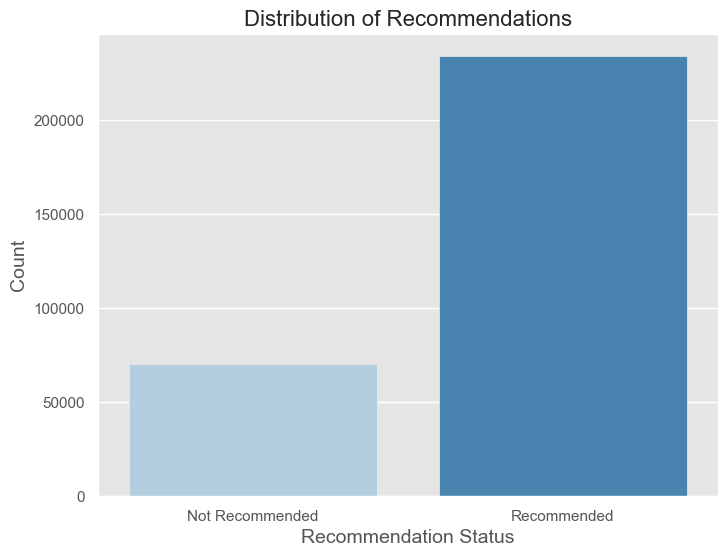

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count the occurrences of each recommendation value
recommend_counts = df_cleaned['is_recommended'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=recommend_counts.index, y=recommend_counts.values, palette='Blues')

# Add labels and title
plt.xlabel('Recommendation Status', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Recommendations', fontsize=16)
plt.xticks(ticks=[0, 1], labels=['Not Recommended', 'Recommended'])
plt.show()


In [206]:
df_sentiment.columns

Index(['text', 'label', 'tokenized_reviews', 'lowercase_reviews',
       'cleaned_reviews', 'lemma_reviews'],
      dtype='object')

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1907573614.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=recommend_counts.index, y=recommend_counts.values, palette='Blues')


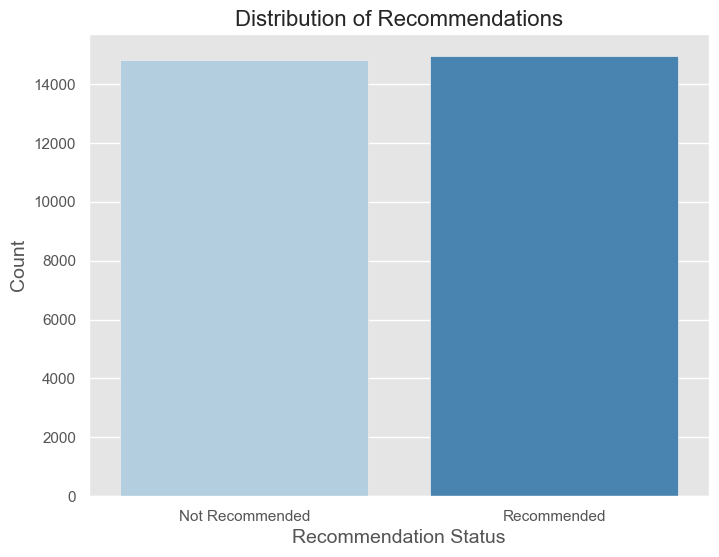

In [208]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count the occurrences of each recommendation value
recommend_counts = df_sentiment['label'].value_counts()

# Create a bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=recommend_counts.index, y=recommend_counts.values, palette='Blues')

# Add labels and title
plt.xlabel('Recommendation Status', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.title('Distribution of Recommendations', fontsize=16)
plt.xticks(ticks=[0, 1], labels=['Not Recommended', 'Recommended'])
plt.show()

In [55]:
df_sentiment.is_recommended.value_counts()

is_recommended
1.0    233893
0.0     70507
Name: count, dtype: int64

##### The dataset is imbalanced. I am going to downsizeand handling the imbalanced dataset

In [56]:
# Rename the columns
df_sentiment.rename(columns={'review_text':'text', 'is_recommended':'label'},  inplace=True)

pos = df_sentiment[df_sentiment['label'] == 1].sample(15000)
neg = df_sentiment[df_sentiment['label'] == 0].sample(15000)

# Concat pos and neg label
df_sentiment = pd.concat([pos,neg],axis=0)
df_sentiment.shape

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/3993370844.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sentiment.rename(columns={'review_text':'text', 'is_recommended':'label'},  inplace=True)


(30000, 2)

In [57]:
#Percentage of Positive/Negative
print("Positive: ", round(df_sentiment.label.value_counts()[1]/len(df_sentiment)*100 , 2 ),"%")
print("Negative: ", round(df_sentiment.label.value_counts()[0]/len(df_sentiment)*100, 2 ),"%")

Positive:  50.0 %
Negative:  50.0 %


##### Text preprocessing

Processing the dataset text to lowercase

In [ ]:
from nltk.tokenize import word_tokenize

# Tokenize the reviews
df_sentiment['tokenized_reviews'] = df_sentiment['text'].apply(word_tokenize)

# Now create lowercase variation of theData['tokenized_reviews']...

df_sentiment['lowercase_reviews'] = df_sentiment['tokenized_reviews'].apply(
    lambda x: [word.lower() for word in x] )

# Display the lowercase tokens
pd.set_option('display.max_colwidth', 100)
df_sentiment[['text', 'lowercase_reviews']].head()

,text,lowercase_reviews
845814,This item was gifted to me from Supergoop for my honest opinion. Hmmm let’s see This sunscreen h...,"[this, item, was, gifted, to, me, from, supergoop, for, my, honest, opinion, ., hmmm, let, ’, s,..."
852012,It’s been about 3-4 days of using consecutively at night in my skincare routine and I have defin...,"[it, ’, s, been, about, 3-4, days, of, using, consecutively, at, night, in, my, skincare, routin..."
282152,I wanted an oil cleanser for my face and this stuff works amazing! Took off all of my makeup rea...,"[i, wanted, an, oil, cleanser, for, my, face, and, this, stuff, works, amazing, !, took, off, al..."
403088,I freaking love this moisturizer!! I have normal to dry skin and I live in the Midwest so it get...,"[i, freaking, love, this, moisturizer, !, !, i, have, normal, to, dry, skin, and, i, live, in, t..."
245076,I’ve used this cleanser for about the last year ever since seeing it hyped up on Tiktok. After t...,"[i, ’, ve, used, this, cleanser, for, about, the, last, year, ever, since, seeing, it, hyped, up..."


Now remove "stop words" and punctuation

In [60]:
import string
from nltk.corpus import stopwords # Import the stopwords resource from NLTK

# Get English stopwords
stop_words = set(stopwords.words('english'))
punctuation = set(string.punctuation)

# Remove stop words and punctuation from theData['lowercase_reviews']

stop_words = set(stopwords.words('english'))
def remove_stopwords(tokens):
       return [word for word in tokens if word not in stop_words and word not in punctuation]
df_sentiment['cleaned_reviews'] = df_sentiment['lowercase_reviews'].apply(remove_stopwords)

print(df_sentiment['cleaned_reviews'])

845814    [item, gifted, supergoop, honest, opinion, hmmm, let, ’, see, sunscreen, white, cast, completely...
852012    [’, 3-4, days, using, consecutively, night, skincare, routine, definitely, seen, skin, tone, eve...
282152    [wanted, oil, cleanser, face, stuff, works, amazing, took, makeup, really, easily, even, tested,...
403088    [freaking, love, moisturizer, normal, dry, skin, live, midwest, gets, reallllyyy, cold, winter, ...
245076    [’, used, cleanser, last, year, ever, since, seeing, hyped, tiktok, trial, error, w/, hormonal, ...
                                                         ...                                                 
338666                                                                [made, pimple, worse, red, ’, go, away]
258611                              [people, color, even, dark, sat, face, like, layer, white/yellow, makeup]
930268    [really, wanted, like, never, could, get, completely, melt, hands, definitely, prefer, farmacy, ...
670957    

Remove special chars and drop duplicates

In [61]:
import re

# Function using regex to remove special characters from tokens
def remove_special_chars(tokens):
    cleaned_text = [re.sub(r'\W', '', word) for word in tokens if re.sub(r'\W', '', word)!= '']
    return cleaned_text
# Apply the function to remove special characters
df_sentiment['cleaned_reviews'] = df_sentiment['cleaned_reviews'].apply(remove_special_chars)

# Drop duplicate reviews (if any)
df_sentiment.drop_duplicates(subset='text', keep='first', inplace=True)

# Display the cleaned tokens (without special characters and duplicates)
df_sentiment[['text', 'cleaned_reviews']].head()

,text,cleaned_reviews
845814,This item was gifted to me from Supergoop for my honest opinion. Hmmm let’s see This sunscreen h...,"[item, gifted, supergoop, honest, opinion, hmmm, let, see, sunscreen, white, cast, completely, r..."
852012,It’s been about 3-4 days of using consecutively at night in my skincare routine and I have defin...,"[34, days, using, consecutively, night, skincare, routine, definitely, seen, skin, tone, even, h..."
282152,I wanted an oil cleanser for my face and this stuff works amazing! Took off all of my makeup rea...,"[wanted, oil, cleanser, face, stuff, works, amazing, took, makeup, really, easily, even, tested,..."
403088,I freaking love this moisturizer!! I have normal to dry skin and I live in the Midwest so it get...,"[freaking, love, moisturizer, normal, dry, skin, live, midwest, gets, reallllyyy, cold, winter, ..."
245076,I’ve used this cleanser for about the last year ever since seeing it hyped up on Tiktok. After t...,"[used, cleanser, last, year, ever, since, seeing, hyped, tiktok, trial, error, w, hormonal, acne..."


Applying lemmaization

In [62]:
df_sentiment['cleaned_reviews']

845814    [item, gifted, supergoop, honest, opinion, hmmm, let, see, sunscreen, white, cast, completely, r...
852012    [34, days, using, consecutively, night, skincare, routine, definitely, seen, skin, tone, even, h...
282152    [wanted, oil, cleanser, face, stuff, works, amazing, took, makeup, really, easily, even, tested,...
403088    [freaking, love, moisturizer, normal, dry, skin, live, midwest, gets, reallllyyy, cold, winter, ...
245076    [used, cleanser, last, year, ever, since, seeing, hyped, tiktok, trial, error, w, hormonal, acne...
                                                         ...                                                 
338666                                                                   [made, pimple, worse, red, go, away]
258611                               [people, color, even, dark, sat, face, like, layer, whiteyellow, makeup]
930268    [really, wanted, like, never, could, get, completely, melt, hands, definitely, prefer, farmacy, ...
670957    

In [63]:
!pip install nltk

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [64]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to get the correct part-of-speech tag for lemmatization
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word])[0][1][0].upper()  # POS tagging
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)  # Default to noun if tag isn't found

# Apply to the DataFrame
df_sentiment['lemma_reviews'] = df_sentiment['cleaned_reviews'].apply(
    lambda x: [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in x]
)

# Compare original and lemmatized reviews
df_sentiment[['text', 'lemma_reviews']].head()


,text,lemma_reviews
845814,This item was gifted to me from Supergoop for my honest opinion. Hmmm let’s see This sunscreen h...,"[item, gift, supergoop, honest, opinion, hmmm, let, see, sunscreen, white, cast, completely, rub..."
852012,It’s been about 3-4 days of using consecutively at night in my skincare routine and I have defin...,"[34, day, use, consecutively, night, skincare, routine, definitely, see, skin, tone, even, hyper..."
282152,I wanted an oil cleanser for my face and this stuff works amazing! Took off all of my makeup rea...,"[want, oil, cleanser, face, stuff, work, amaze, take, makeup, really, easily, even, test, cotton..."
403088,I freaking love this moisturizer!! I have normal to dry skin and I live in the Midwest so it get...,"[freak, love, moisturizer, normal, dry, skin, live, midwest, get, reallllyyy, cold, winter, use,..."
245076,I’ve used this cleanser for about the last year ever since seeing it hyped up on Tiktok. After t...,"[use, cleanser, last, year, ever, since, see, hyped, tiktok, trial, error, w, hormonal, acne, re..."


Visualization for word count

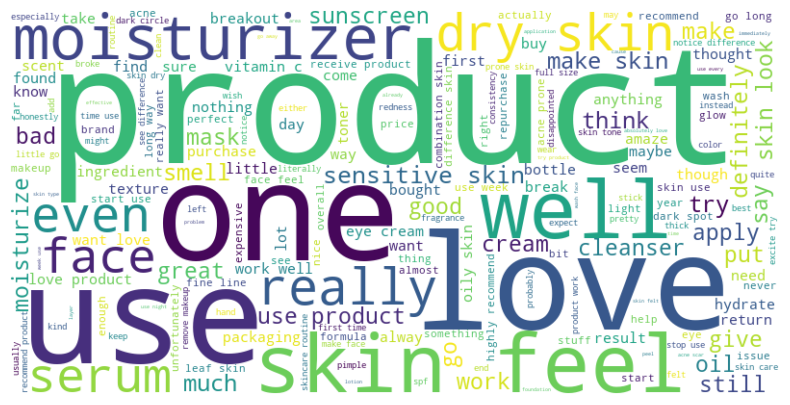

In [65]:
!pip install wordcloud

# Import required libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Flatten the list of all tokens (words) from the 'lemma_reviews' column into a single list
all_tokens = [word for review in df_sentiment['lemma_reviews'] for word in review]

# Join the words into a single string (to make it compatible with WordCloud)
all_tokens_text = ' '.join(all_tokens)

# Create the WordCloud
theCloud = WordCloud(width=800, height=400, background_color='white').generate(all_tokens_text)

# Present the cloud
plt.figure(figsize=(10, 5))
plt.imshow(theCloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


     Product  Cumulative Sentiment
35       zit                8.5637
16     kinda                8.3670
4      knock                7.3380
20  youtuber                5.9049
3    zenovia                4.3230


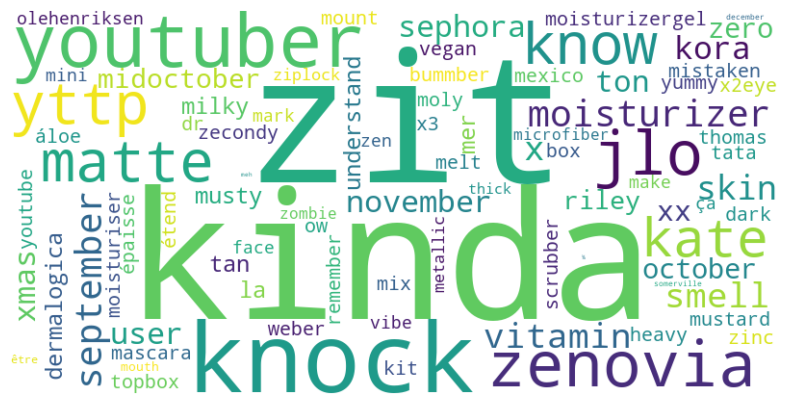

In [66]:
import nltk
nltk.download('vader_lexicon')
from nltk import pos_tag
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import defaultdict

# Initialize Sentiment Analyzer
theSentimeter = SentimentIntensityAnalyzer()

# Initialize the dictionary to store product names and their sentiment scores
product_sentiment = defaultdict(float)

# Function to extract proper nouns (likely product names) and accumulate sentiment
def extract_product_sentiment(review):
    sentiment_score = theSentimeter.polarity_scores(' '.join(review))['compound']
    
    # Use POS tagging to identify proper nouns (NNP - singular, NNPS - plural)
    tagged_tokens = pos_tag(review)
    
    for word, tag in tagged_tokens:
        if tag in ['NNP', 'NNPS']:  # Proper noun (singular or plural)
            product_sentiment[word] += sentiment_score  # Add sentiment score to the product name

# Iterate through each review in the DataFrame
for review in df_sentiment['lemma_reviews']:
    extract_product_sentiment(review)

# Convert the dictionary to a DataFrame for easy visualization
product_sentiment_df = pd.DataFrame(list(product_sentiment.items()), columns=['Product', 'Cumulative Sentiment'])

# Display the results
print(product_sentiment_df.sort_values(by='Cumulative Sentiment', ascending=False).head())

# Create a WordCloud from the product_sentiment dictionary
theCloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(product_sentiment)

# Present the cloud
plt.figure(figsize=(10, 5))
plt.imshow(theCloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis
plt.show()

In [210]:
df_sentiment

,text,label,tokenized_reviews,lowercase_reviews,cleaned_reviews,lemma_reviews
845814,This item was gifted to me from Supergoop for my honest opinion. Hmmm let’s see This sunscreen h...,1.0,"[This, item, was, gifted, to, me, from, Supergoop, for, my, honest, opinion, ., Hmmm, let, ’, s,...","[this, item, was, gifted, to, me, from, supergoop, for, my, honest, opinion, ., hmmm, let, ’, s,...","[item, gifted, supergoop, honest, opinion, hmmm, let, see, sunscreen, white, cast, completely, r...","[item, gift, supergoop, honest, opinion, hmmm, let, see, sunscreen, white, cast, completely, rub..."
852012,It’s been about 3-4 days of using consecutively at night in my skincare routine and I have defin...,1.0,"[It, ’, s, been, about, 3-4, days, of, using, consecutively, at, night, in, my, skincare, routin...","[it, ’, s, been, about, 3-4, days, of, using, consecutively, at, night, in, my, skincare, routin...","[34, days, using, consecutively, night, skincare, routine, definitely, seen, skin, tone, even, h...","[34, day, use, consecutively, night, skincare, routine, definitely, see, skin, tone, even, hyper..."
282152,I wanted an oil cleanser for my face and this stuff works amazing! Took off all of my makeup rea...,1.0,"[I, wanted, an, oil, cleanser, for, my, face, and, this, stuff, works, amazing, !, Took, off, al...","[i, wanted, an, oil, cleanser, for, my, face, and, this, stuff, works, amazing, !, took, off, al...","[wanted, oil, cleanser, face, stuff, works, amazing, took, makeup, really, easily, even, tested,...","[want, oil, cleanser, face, stuff, work, amaze, take, makeup, really, easily, even, test, cotton..."
403088,I freaking love this moisturizer!! I have normal to dry skin and I live in the Midwest so it get...,1.0,"[I, freaking, love, this, moisturizer, !, !, I, have, normal, to, dry, skin, and, I, live, in, t...","[i, freaking, love, this, moisturizer, !, !, i, have, normal, to, dry, skin, and, i, live, in, t...","[freaking, love, moisturizer, normal, dry, skin, live, midwest, gets, reallllyyy, cold, winter, ...","[freak, love, moisturizer, normal, dry, skin, live, midwest, get, reallllyyy, cold, winter, use,..."
245076,I’ve used this cleanser for about the last year ever since seeing it hyped up on Tiktok. After t...,1.0,"[I, ’, ve, used, this, cleanser, for, about, the, last, year, ever, since, seeing, it, hyped, up...","[i, ’, ve, used, this, cleanser, for, about, the, last, year, ever, since, seeing, it, hyped, up...","[used, cleanser, last, year, ever, since, seeing, hyped, tiktok, trial, error, w, hormonal, acne...","[use, cleanser, last, year, ever, since, see, hyped, tiktok, trial, error, w, hormonal, acne, re..."
...,...,...,...,...,...,...
338666,"Made my pimple worse, red and won’t go away",0.0,"[Made, my, pimple, worse, ,, red, and, won, ’, t, go, away]","[made, my, pimple, worse, ,, red, and, won, ’, t, go, away]","[made, pimple, worse, red, go, away]","[make, pimple, bad, red, go, away]"
258611,This is not for people of color. I am not even that dark and it sat on my face like a layer of w...,0.0,"[This, is, not, for, people, of, color, ., I, am, not, even, that, dark, and, it, sat, on, my, f...","[this, is, not, for, people, of, color, ., i, am, not, even, that, dark, and, it, sat, on, my, f...","[people, color, even, dark, sat, face, like, layer, whiteyellow, makeup]","[people, color, even, dark, sat, face, like, layer, whiteyellow, makeup]"
930268,"I really wanted to like this, but I never could get it to completely melt in my hands. I defini...",0.0,"[I, really, wanted, to, like, this, ,, but, I, never, could, get, it, to, completely, melt, in, ...","[i, really, wanted, to, like, this, ,, but, i, never, could, get, it, to, completely, melt, in, ...","[really, wanted, like, never, could, get, completely, melt, hands, definitely, prefer, farmacy, ...","[really, want, like, never, could, get, completely, melt, hand, definitely, prefer, farmacy, elf..."
670957,I received this as a sample from influenster to tr

N-grams Analysis (Bigrams & Trigrams)
Bigram (2-gram): Pairs of consecutive words. Example: "I love NLP" → ['I love', 'love NLP']
Trigram (3-gram): Triplets of consecutive words. Example: "I love NLP" → ['I love NLP']

Generate N-grams using CountVectorizer

In [212]:
import re
from sklearn.feature_extraction.text import CountVectorizer
df_sentiment['lemma_reviews_1'] = df_sentiment['lemma_reviews'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)


# Create a CountVectorizer for bigrams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
bigram_matrix = bigram_vectorizer.fit_transform(df_sentiment['lemma_reviews_1'])

# Convert bigram matrix to DataFrame
bigram_df = pd.DataFrame(bigram_matrix.toarray(), columns=bigram_vectorizer.get_feature_names_out())

# Sum the occurrences of each bigram
bigram_counts = bigram_df.sum(axis=0).sort_values(ascending=False)

# Display top 10 bigrams
print("Top 10 Bigrams:")
print(bigram_counts.head(10))


Top 10 Bigrams:
skin feel         2796
dry skin          2495
sensitive skin    2241
make skin         2064
use product       2014
feel like         1845
skin look         1526
love product      1264
oily skin         1164
eye cream         1096
dtype: int64


Trigram Analysis:

In [213]:
df_sentiment['lemma_reviews_1'] = df_sentiment['lemma_reviews'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x)
# Create a CountVectorizer for trigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), stop_words='english')
trigram_matrix = trigram_vectorizer.fit_transform(df_sentiment['lemma_reviews_1'])

# Convert trigram matrix to DataFrame
trigram_df = pd.DataFrame(trigram_matrix.toarray(), columns=trigram_vectorizer.get_feature_names_out())

# Sum the occurrences of each trigram
trigram_counts = trigram_df.sum(axis=0).sort_values(ascending=False)

# Display top 10 trigrams
print("Top 10 Trigrams:")
print(trigram_counts.head(10))


Top 10 Trigrams:
make skin feel                   708
little long way                  560
acne prone skin                  493
leaf skin feel                   351
really want love                 327
make skin look                   320
skin feel soft                   291
receive product free             289
receive product complimentary    244
want love product                232
dtype: int64


Visualization of N-grams (Bigrams Example)

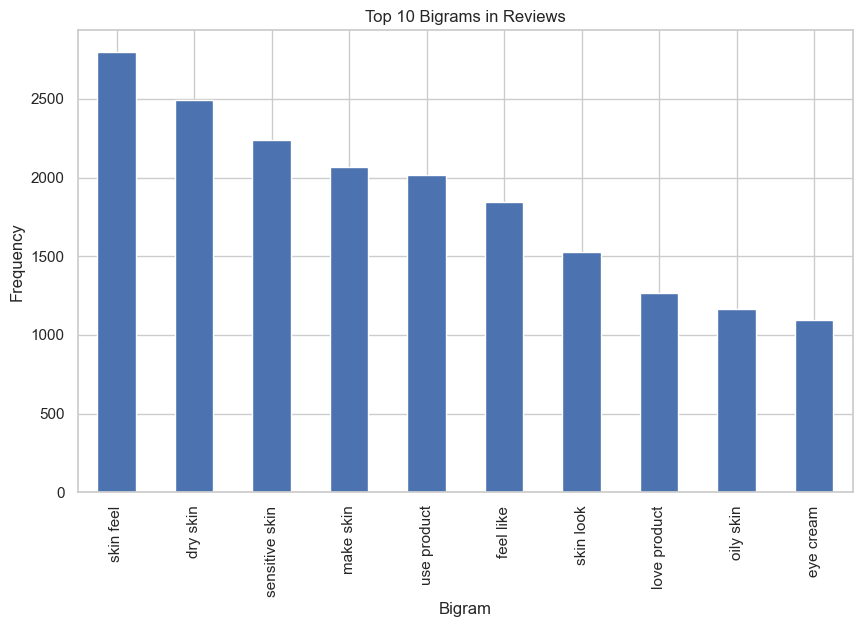

In [413]:
import matplotlib.pyplot as plt

# Plot the top 10 bigrams
top_bigrams = bigram_counts.head(10)

plt.figure(figsize=(10, 6))
top_bigrams.plot(kind='bar')
plt.title('Top 10 Bigrams in Reviews')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()


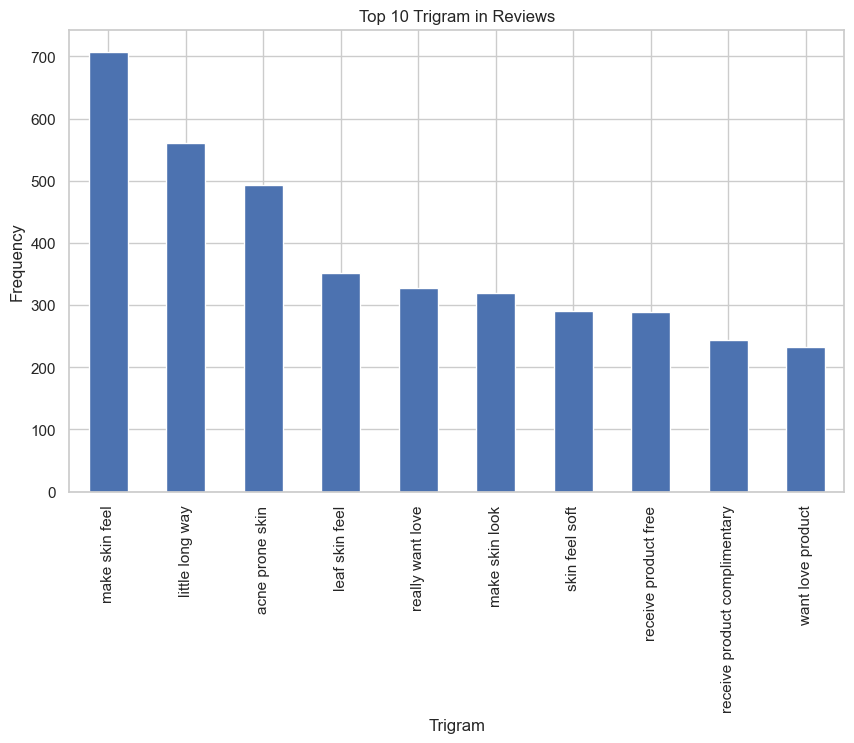

In [417]:
import matplotlib.pyplot as plt

# Plot the top 10 bigrams
top_trigram = trigram_counts.head(10)

plt.figure(figsize=(10, 6))
top_trigram.plot(kind='bar')
plt.title('Top 10 Trigram in Reviews')
plt.xlabel('Trigram')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

Sentiment Analysis:
Sentiment analysis evaluates whether text expresses positive, negative, or neutral sentiment. Here, we'll use the TextBlob and VADER libraries.

Option 1: Using TextBlob for Sentiment Analysis

In [218]:
from textblob import TextBlob

# Function to compute sentiment polarity
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity  # Returns a score between -1 (negative) and 1 (positive)

# Apply sentiment analysis
df_sentiment['sentiment_polarity'] = df_sentiment['lemma_reviews_1'].apply(get_sentiment)

# Classify sentiment based on polarity
df_sentiment['sentiment_label'] = df_sentiment['sentiment_polarity'].apply(lambda x: 'Positive' if x > 0 else ('Negative' if x < 0 else 'Neutral'))

# Display the results
print(df_sentiment[['text', 'sentiment_polarity', 'sentiment_label']])


                                                                                                       text  \
845814  This item was gifted to me from Supergoop for my honest opinion. Hmmm let’s see This sunscreen h...   
852012  It’s been about 3-4 days of using consecutively at night in my skincare routine and I have defin...   
282152  I wanted an oil cleanser for my face and this stuff works amazing! Took off all of my makeup rea...   
403088  I freaking love this moisturizer!! I have normal to dry skin and I live in the Midwest so it get...   
245076  I’ve used this cleanser for about the last year ever since seeing it hyped up on Tiktok. After t...   
...                                                                                                     ...   
338666                                                          Made my pimple worse, red and won’t go away   
258611  This is not for people of color. I am not even that dark and it sat on my face like a layer of w...   
9

Option 2: Using VADER (Valence Aware Dictionary for Sentiment Reasoning)
VADER is particularly effective for short texts like reviews and works well on social media data.

In [219]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download VADER lexicon if not already done
nltk.download('vader_lexicon')

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to compute VADER sentiment
def vader_sentiment(text):
    scores = analyzer.polarity_scores(text)
    return scores['compound']  # Returns a score between -1 and 1

# Apply sentiment analysis
df_sentiment['vader_sentiment_score'] = df_sentiment['text'].apply(vader_sentiment)

# Classify based on the compound score
df_sentiment['vader_sentiment_label'] = df_sentiment['vader_sentiment_score'].apply(lambda x: 'Positive' if x > 0.05 else ('Negative' if x < -0.05 else 'Neutral'))

# Display the results
print(df_sentiment[['text', 'vader_sentiment_score', 'vader_sentiment_label']])


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/mousumykundu/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


                                                                                                       text  \
845814  This item was gifted to me from Supergoop for my honest opinion. Hmmm let’s see This sunscreen h...   
852012  It’s been about 3-4 days of using consecutively at night in my skincare routine and I have defin...   
282152  I wanted an oil cleanser for my face and this stuff works amazing! Took off all of my makeup rea...   
403088  I freaking love this moisturizer!! I have normal to dry skin and I live in the Midwest so it get...   
245076  I’ve used this cleanser for about the last year ever since seeing it hyped up on Tiktok. After t...   
...                                                                                                     ...   
338666                                                          Made my pimple worse, red and won’t go away   
258611  This is not for people of color. I am not even that dark and it sat on my face like a layer of w...   
9

Visualization of Sentiment Analysis

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/2386850029.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')


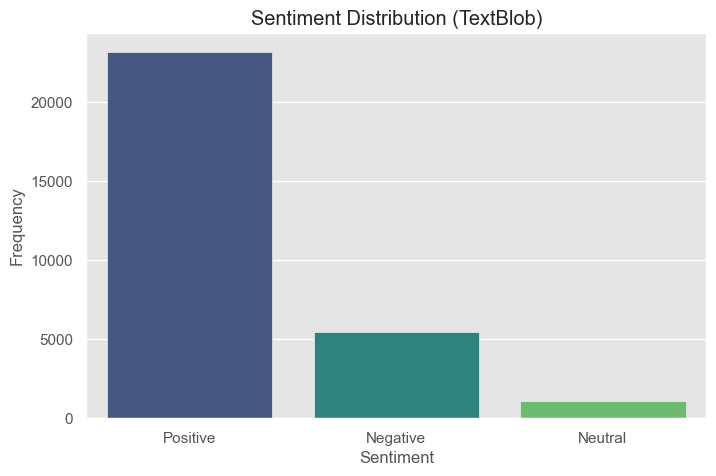

In [224]:
import seaborn as sns

# Count the sentiment labels
sentiment_counts = df_sentiment['sentiment_label'].value_counts()

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='viridis')
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/2777143352.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vader_sentiment_counts.index, y=vader_sentiment_counts.values, palette='viridis')


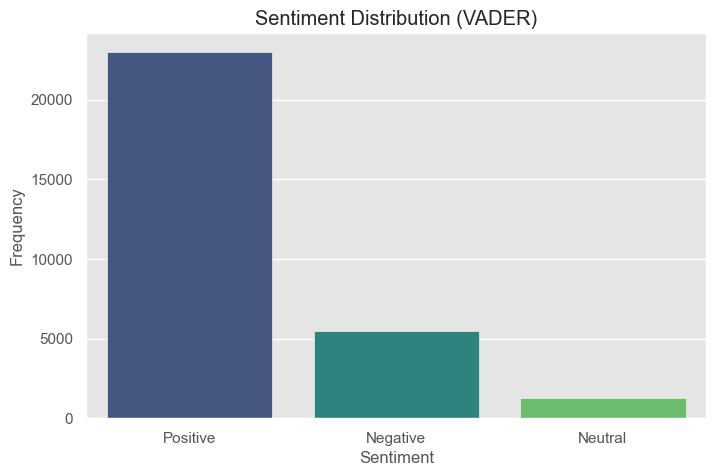

In [223]:
# Count the VADER sentiment labels
vader_sentiment_counts = df_sentiment['vader_sentiment_label'].value_counts()

# Plot VADER sentiment distribution
plt.figure(figsize=(8, 5))
sns.barplot(x=vader_sentiment_counts.index, y=vader_sentiment_counts.values, palette='viridis')
plt.title('Sentiment Distribution (VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Frequency')
plt.show()


##### Preprocessing the Data:
Before diving into the model architecture, we need to preprocess the data to prepare it for the LSTM model.

a. Text Preprocessing:
Tokenize the text: Convert the text into sequences of integers (each unique word gets a unique integer). Pad sequences: Ensure that the input sequences have the same length for LSTM input.

In [226]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



# Example: Preparing text and labels
texts = df_sentiment['text']  
labels = df_sentiment['label']  

# Tokenize the text (convert words into integers)
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

# Pad sequences to ensure uniform input size
X = pad_sequences(sequences, padding='post')

y = labels.to_numpy()

# Define vocab_size
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding or OOV token
print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 19756


#### b. Split the data:
Split the data into training and testing sets.

In [227]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##2.2 Build the LSTM Model:
We can now apply different LSTM architectures. Will start with a basic LSTM model and modify it by changing the number/size of LSTM layers, adding Dense layers, and varying the embedding dimensions.

basic LSTM model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Initialize the model
model = Sequential()

# Embedding layer: Convert integers into dense vectors of fixed size
model.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=X_train.shape[1]))

# Add the first LSTM layer
model.add(LSTM(256, return_sequences=True))  # First LSTM layer

# Add the second LSTM layer
model.add(LSTM(128))  # Second LSTM layer

# Add Dense layers after LSTM layers
model.add(Dense(128, activation='relu'))  # First Dense layer
model.add(Dense(64, activation='relu'))   # Second Dense layer

# Output layer for classification (3 classes)
model.add(Dense(3, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
#model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test))
print(history.history.keys())  # Check again after fit

Epoch 1/5


/opt/anaconda3/envs/MAS_200/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


744/744 ━━━━━━━━━━━━━━━━━━━━ 409s 548ms/step - accuracy: 0.4984 - loss: 0.7158 - val_accuracy: 0.4910 - val_loss: 0.6947
Epoch 2/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 410s 551ms/step - accuracy: 0.5017 - loss: 0.6949 - val_accuracy: 0.4910 - val_loss: 0.7029
Epoch 3/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 410s 551ms/step - accuracy: 0.5039 - loss: 0.6947 - val_accuracy: 0.5090 - val_loss: 0.6933
Epoch 4/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 410s 552ms/step - accuracy: 0.5044 - loss: 0.6941 - val_accuracy: 0.4910 - val_loss: 0.6958
Epoch 5/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 409s 550ms/step - accuracy: 0.5046 - loss: 0.6942 - val_accuracy: 0.5090 - val_loss: 0.6936


In [411]:
print(history.history)

{'accuracy': [0.5013653635978699, 0.4972902536392212, 0.49750030040740967, 0.5026257038116455, 0.49825653433799744], 'loss': [0.6937978863716125, 0.6936413049697876, 0.6935234665870667, 0.6933103203773499, 0.6935821771621704], 'val_accuracy': [0.5089901089668274, 0.491009920835495, 0.5089901089668274, 0.5089901089668274, 0.5089901089668274], 'val_loss': [0.6939260959625244, 0.6935999393463135, 0.6931692361831665, 0.6930062174797058, 0.6930393576622009]}


In [229]:
# Evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


186/186 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.5088 - loss: 0.6936
Test Accuracy: 50.90%
Test Loss: 0.6936


Training vs. Validation Accuracy & Loss Visualization

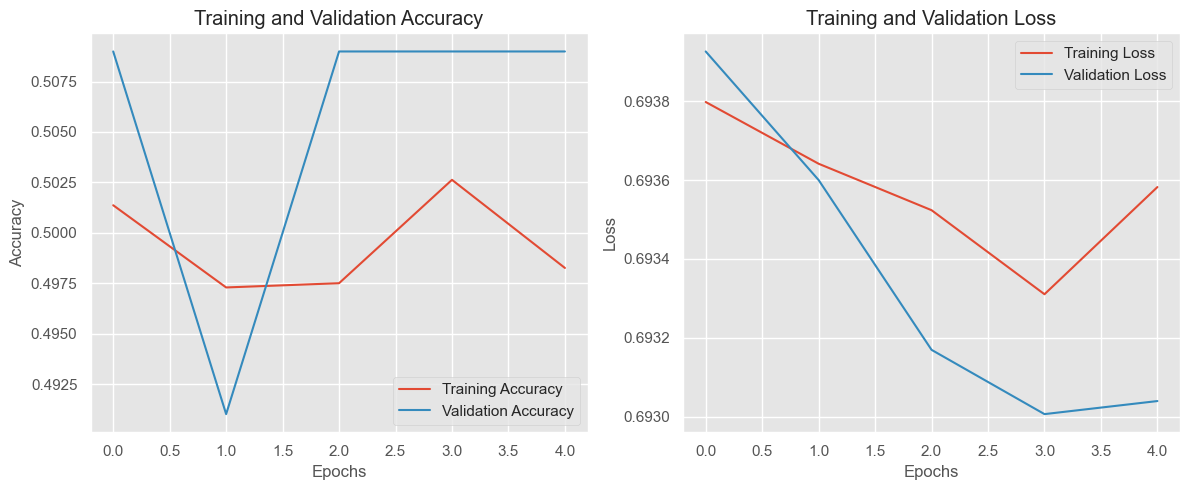

In [236]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
if 'accuracy' in history.history or 'sparse_categorical_accuracy' in history.history:
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get('accuracy', history.history.get('sparse_categorical_accuracy')), label='Training Accuracy')
    plt.plot(history.history.get('val_accuracy', history.history.get('val_sparse_categorical_accuracy')), label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

# Plot Loss
if 'loss' in history.history:
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

plt.tight_layout()
plt.show()



adding Dense layers, and varying the embedding dimensions.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Initialize the model
model_LSTM_Bidirectional = Sequential()

# Embedding layer
model_LSTM_Bidirectional.add(Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=100, input_length=X_train.shape[1]))

# Add Bidirectional LSTM layers
model_LSTM_Bidirectional.add(Bidirectional(LSTM(256, return_sequences=True)))  # First Bidirectional LSTM layer
model_LSTM_Bidirectional.add(Bidirectional(LSTM(128)))  # Second Bidirectional LSTM layer

# Add Dense layers
model_LSTM_Bidirectional.add(Dense(128, activation='relu'))
model_LSTM_Bidirectional.add(Dense(64, activation='relu'))
model_LSTM_Bidirectional.add(Dropout(0.2))  # Add dropout

# Output layer
model_LSTM_Bidirectional.add(Dense(3, activation='softmax'))

# Compile the model
model_LSTM_Bidirectional.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Add early stopping and learning rate reduction
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=2, verbose=1, factor=0.5, min_lr=0.0001)

# Train the model with callbacks
history_LSTM_Bidirectional = model_LSTM_Bidirectional.fit(X_train, y_train, epochs=5, batch_size=32, validation_data=(X_test, y_test),
          callbacks=[early_stopping, lr_reduction])
print(history_LSTM_Bidirectional.history.keys())  # Check again after fit


Epoch 1/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 662s 887ms/step - accuracy: 0.7059 - loss: 0.5604 - val_accuracy: 0.8671 - val_loss: 0.3326 - learning_rate: 0.0010
Epoch 2/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 686s 922ms/step - accuracy: 0.8969 - loss: 0.2684 - val_accuracy: 0.8899 - val_loss: 0.2774 - learning_rate: 0.0010
Epoch 3/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 690s 927ms/step - accuracy: 0.9204 - loss: 0.2197 - val_accuracy: 0.8829 - val_loss: 0.2812 - learning_rate: 0.0010
Epoch 4/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9370 - loss: 0.1802
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
744/744 ━━━━━━━━━━━━━━━━━━━━ 1898s 3s/step - accuracy: 0.9370 - loss: 0.1801 - val_accuracy: 0.8992 - val_loss: 0.2895 - learning_rate: 0.0010
Epoch 5/5
744/744 ━━━━━━━━━━━━━━━━━━━━ 729s 980ms/step - accuracy: 0.9615 - loss: 0.1165 - val_accuracy: 0.9074 - val_loss: 0.2582 - learning_rate: 5.0000e-04
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate

In [244]:
# Evaluate the model on the test data
test_loss_LSTM_Bidirectional, test_accuracy_LSTM_Bidirectional = model_LSTM_Bidirectional.evaluate(X_test, y_test)

print(f"Test Accuracy: {test_accuracy_LSTM_Bidirectional * 100:.2f}%")
print(f"Test Loss: {test_loss_LSTM_Bidirectional:.4f}")

186/186 ━━━━━━━━━━━━━━━━━━━━ 38s 205ms/step - accuracy: 0.9105 - loss: 0.2354
Test Accuracy: 90.74%
Test Loss: 0.2582


In [408]:
print(history_LSTM_Bidirectional.history)

{'accuracy': [0.7928832769393921, 0.8961055278778076, 0.920640230178833, 0.9383270740509033, 0.9608452916145325], 'loss': [0.4503161311149597, 0.2704503834247589, 0.21566545963287354, 0.1718788892030716, 0.12059259414672852], 'val_accuracy': [0.8670811653137207, 0.8899344801902771, 0.8828768134117126, 0.8991765975952148, 0.9074105024337769], 'val_loss': [0.33258432149887085, 0.27739229798316956, 0.2812316417694092, 0.2895318269729614, 0.25816333293914795], 'learning_rate': [0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0010000000474974513, 0.0005000000237487257]}


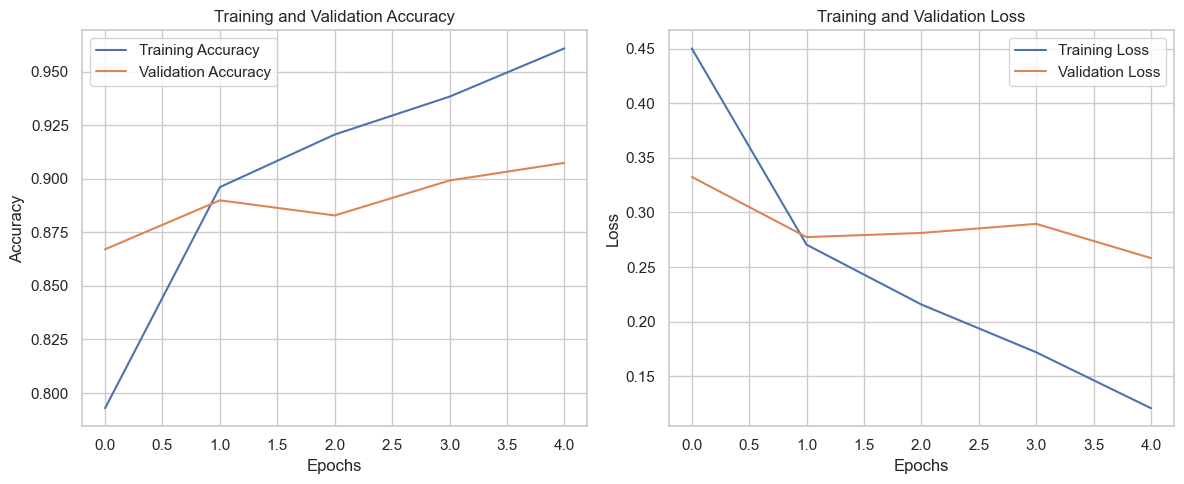

In [409]:
plt.figure(figsize=(12, 5))

# Plot Accuracy
if 'accuracy' in history_LSTM_Bidirectional.history or 'sparse_categorical_accuracy' in history_LSTM_Bidirectional.history:
    plt.subplot(1, 2, 1)
    plt.plot(history_LSTM_Bidirectional.history.get('accuracy', history_LSTM_Bidirectional.history.get('sparse_categorical_accuracy')), label='Training Accuracy')
    plt.plot(history_LSTM_Bidirectional.history.get('val_accuracy', history_LSTM_Bidirectional.history.get('val_sparse_categorical_accuracy')), label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

# Plot Loss
if 'loss' in history_LSTM_Bidirectional.history:
    plt.subplot(1, 2, 2)
    plt.plot(history_LSTM_Bidirectional.history['loss'], label='Training Loss')
    plt.plot(history_LSTM_Bidirectional.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

plt.tight_layout()
plt.show()

In [245]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Evaluate the model on the test set to get the loss and accuracy
#test_loss, test_accuracy = history_LSTM_Bidirectional.evaluate(X_test, y_test, verbose=0)

# Print the results
print(f"Test Accuracy: {test_accuracy_LSTM_Bidirectional * 100:.2f}%")
print(f"Test Loss: {test_loss_LSTM_Bidirectional:.4f}")

# 2. Generate predictions on the test set
y_pred = model_LSTM_Bidirectional.predict(X_test)

# Since y_pred is the output of the softmax layer, we need to convert it to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# 3. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)


Test Accuracy: 90.74%
Test Loss: 0.2582
186/186 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step


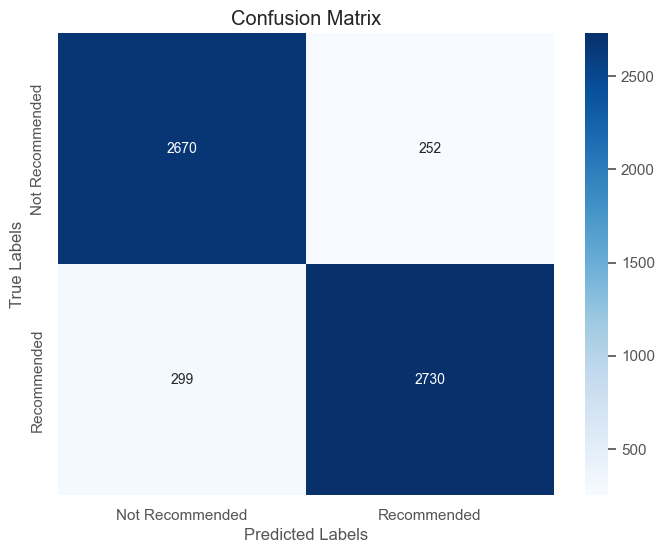

In [259]:
# Define the class labels
class_labels = ['Not Recommended', 'Recommended']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)

# Add labels and title
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [248]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred_classes)

# Precision
precision = precision_score(y_test, y_pred_classes)

# Recall
recall = recall_score(y_test, y_pred_classes)

# F1 Score
f1 = f1_score(y_test, y_pred_classes)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

report = classification_report(y_test, y_pred_classes, target_names=['Not Recommended', 'Recommended'])
print(report)

Accuracy: 0.91
Precision: 0.92
Recall: 0.90
F1 Score: 0.91
                 precision    recall  f1-score   support

Not Recommended       0.90      0.91      0.91      2922
    Recommended       0.92      0.90      0.91      3029

       accuracy                           0.91      5951
      macro avg       0.91      0.91      0.91      5951
   weighted avg       0.91      0.91      0.91      5951



In [ ]:
report['Not Recommended']['precision']

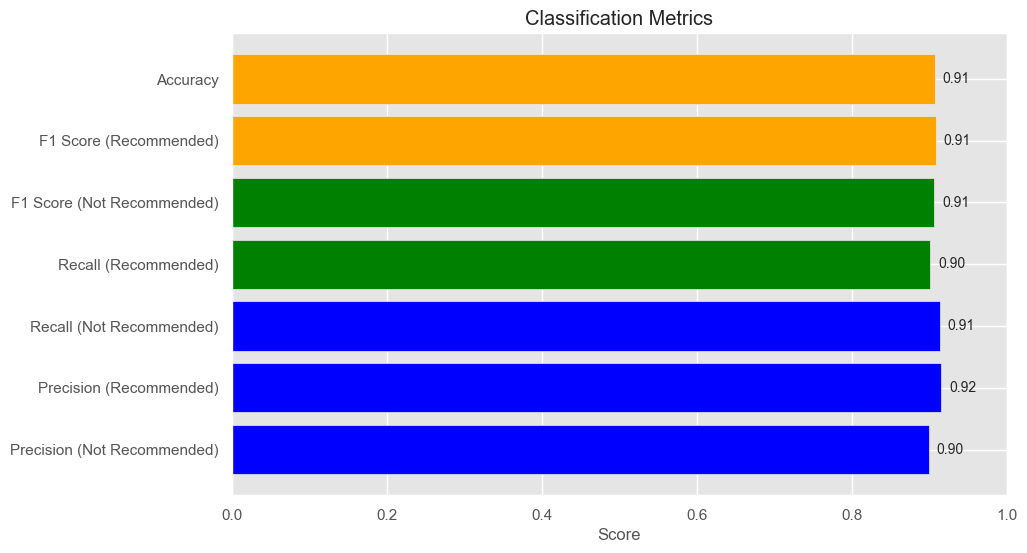

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Assuming y_test and y_pred_classes are already defined
report = classification_report(y_test, y_pred_classes, target_names=['Not Recommended', 'Recommended'], output_dict=True)

# Extracting precision, recall, and F1 scores from the report (which is now a dictionary)
precision_not_recommended = report['Not Recommended']['precision']
recall_not_recommended = report['Not Recommended']['recall']
f1_not_recommended = report['Not Recommended']['f1-score']

precision_recommended = report['Recommended']['precision']
recall_recommended = report['Recommended']['recall']
f1_recommended = report['Recommended']['f1-score']

# Plotting precision, recall, and F1-score for each class
metrics = {
    "Precision (Not Recommended)": precision_not_recommended,
    "Precision (Recommended)": precision_recommended,
    "Recall (Not Recommended)": recall_not_recommended,
    "Recall (Recommended)": recall_recommended,
    "F1 Score (Not Recommended)": f1_not_recommended, 
    "F1 Score (Recommended)": f1_recommended,
    "Accuracy": accuracy
}

# Bar plot with values on x-axis
plt.figure(figsize=(10, 6))
bars = plt.barh(list(metrics.keys()), list(metrics.values()), color=['blue', 'blue', 'blue', 'green', 'green', 'orange', 'orange'])

# Adding the value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.2f}', va='center', ha='left')

plt.xlabel('Score')
plt.title('Classification Metrics')
plt.xlim(0, 1)  # Ensure the x-axis is between 0 and 1
plt.show()


# Customer Segmentation


## Group Customers by Behavior
Use rating, helpfulness, is_recommended, and total_feedback_count to classify customer behavior into Loyal, Satisfied, or Critical categories.

In [82]:
# Define a function to classify customer behavior
def classify_behavior(row):
    if row['rating'] >= 4.5 and row['helpfulness'] > 0.8 and row['is_recommended'] == 1:
        return 'Loyal'
    elif row['rating'] >= 3 and row['helpfulness'] > 0.5:
        return 'Satisfied'
    else:
        return 'Critical'

# Apply the function
df_cleaned['customer_behavior'] = df_cleaned.apply(classify_behavior, axis=1)

# Group by behavior
behavior_groups = df_cleaned.groupby('customer_behavior').size().reset_index(name='customer_count')

print(behavior_groups)


  customer_behavior  customer_count
0          Critical          101050
1             Loyal          125420
2         Satisfied           77930


Behavioral Segmentation Visualization

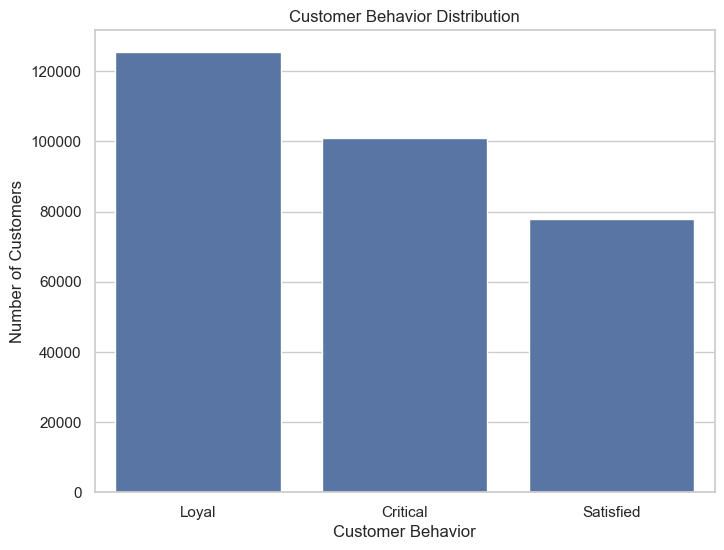

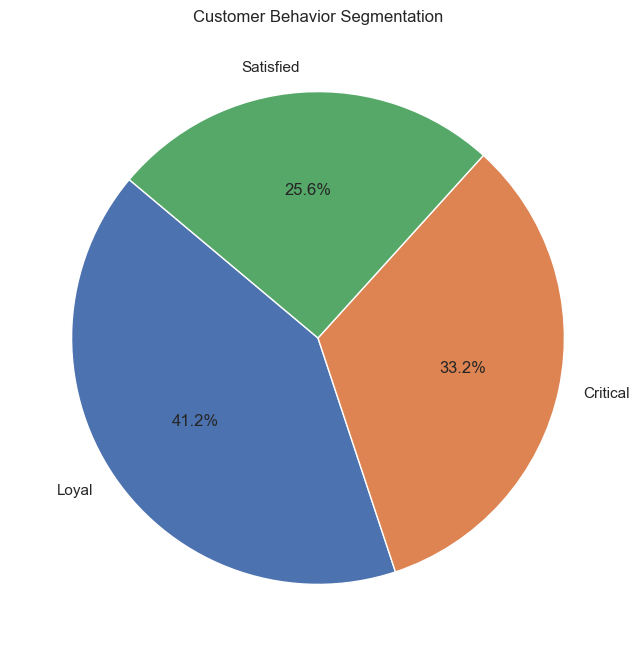

In [421]:
# Plot customer behavior distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df_cleaned, x='customer_behavior', order=df_cleaned['customer_behavior'].value_counts().index)
plt.title('Customer Behavior Distribution')
plt.ylabel('Number of Customers')
plt.xlabel('Customer Behavior')
plt.show()

# Pie chart for customer behavior
behavior_counts = df_cleaned['customer_behavior'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(behavior_counts, labels=behavior_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Customer Behavior Segmentation')
plt.show()


## Combine Demographics and Behavior Segments

In [84]:
# Merge demographic and behavior groups
combined_segments = df_cleaned.groupby(['skin_tone', 'eye_color', 'skin_type', 'customer_behavior']).size().reset_index(name='customer_count')

# Display top segments
print(combined_segments.sort_values('customer_count', ascending=False).head(10))


       skin_tone eye_color    skin_type customer_behavior  customer_count
297  lightMedium     brown  combination             Loyal            9504
296  lightMedium     brown  combination          Critical            8316
227        light     brown  combination             Loyal            7879
226        light     brown  combination          Critical            6809
298  lightMedium     brown  combination         Satisfied            6073
228        light     brown  combination         Satisfied            5186
77          fair      blue  combination             Loyal            4824
215        light      blue  combination             Loyal            4513
89          fair     brown  combination             Loyal            4431
362       medium     brown  combination             Loyal            4315


Combined Segmentation Visualization

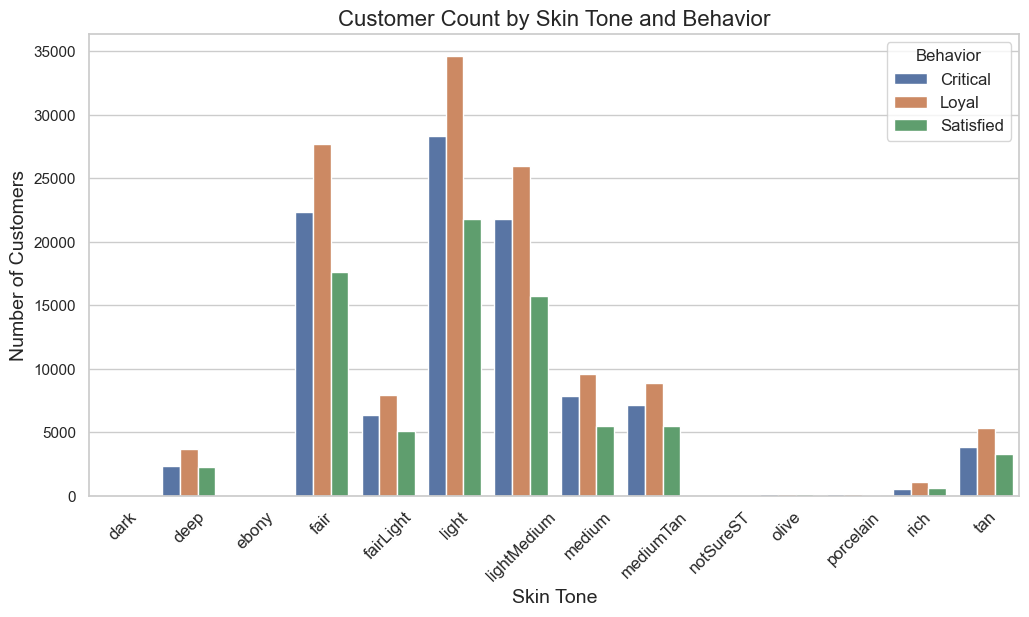

In [422]:
# Group by skin tone and customer behavior for visualization
combined_data = df_cleaned.groupby(['skin_tone', 'customer_behavior']).size().reset_index(name='customer_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_data, x='skin_tone', y='customer_count', hue='customer_behavior')

# Increase fontsize for various elements
plt.title('Customer Count by Skin Tone and Behavior', fontsize=16)
plt.xticks(rotation=45, fontsize=12)  # Increase fontsize of x-axis labels
plt.ylabel('Number of Customers', fontsize=14)  # Increase fontsize of y-axis label
plt.xlabel('Skin Tone', fontsize=14)  # Increase fontsize of x-axis label
plt.legend(title='Behavior', fontsize=12)  # Increase fontsize of legend labels

plt.show()

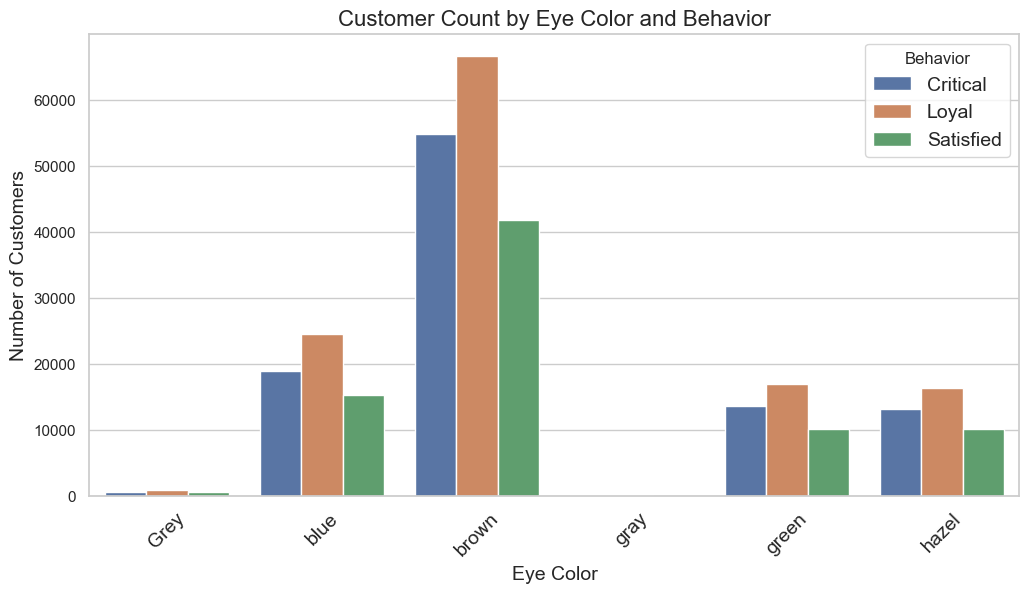

In [426]:
# Group by eye color and customer behavior for visualization
combined_data = df_cleaned.groupby(['eye_color', 'customer_behavior']).size().reset_index(name='customer_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_data, x='eye_color', y='customer_count', hue='customer_behavior')

# Increase font sizes for different elements
plt.title('Customer Count by Eye Color and Behavior', fontsize=16)  # Title font size
plt.xticks(rotation=45, fontsize=14)  # X-axis ticks font size (set to reasonable value)
plt.ylabel('Number of Customers', fontsize=14)  # Y-axis label font size
plt.xlabel('Eye Color', fontsize=14)  # X-axis label font size
plt.legend(title='Behavior', fontsize=14)  # Legend font size

plt.show()



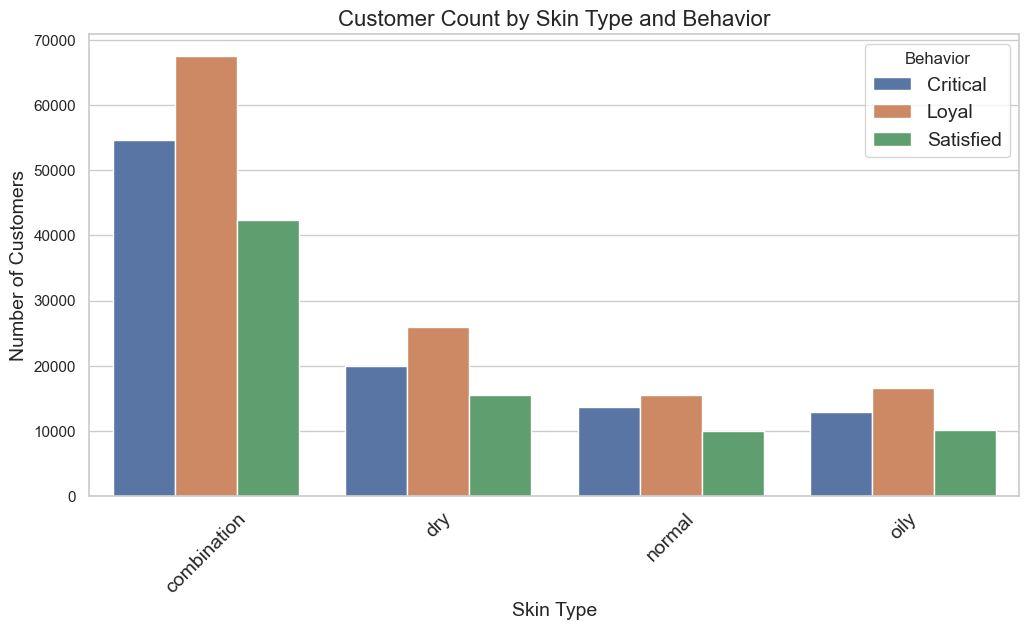

In [427]:
# Group by eye color and customer behavior for visualization
combined_data = df_cleaned.groupby(['skin_type', 'customer_behavior']).size().reset_index(name='customer_count')

plt.figure(figsize=(12, 6))
sns.barplot(data=combined_data, x='skin_type', y='customer_count', hue='customer_behavior')

# Increase font sizes for different elements
plt.title('Customer Count by Skin Type and Behavior', fontsize=16)  # Title font size
plt.xticks(rotation=45, fontsize=14)  # X-axis ticks font size (set to reasonable value)
plt.ylabel('Number of Customers', fontsize=14)  # Y-axis label font size
plt.xlabel('Skin Type', fontsize=14)  # X-axis label font size
plt.legend(title='Behavior', fontsize=14)  # Legend font size

plt.show()


# Can we recommend products? 
By analyzing customers' purchase history and reviews, we can suggest products tailored to their preferences and likely to interest them.

Prepare Content for TF-IDF
Here I am going to downsize the dataset and randomly selecting 10000 rows. Because the dataset is too large and it's taking long time to run tfidf.

- I am going to add attributes for prducts

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df_sample = df_cleaned.sample(10000)  # Select 10000 rows randomly
# Combine product attributes into a single content field
df_sample['content'] = df_sample['product_name'].astype(str) + ' ' + df_sample['brand_name'].astype(str) + ' ' + df_sample['ingredients'].astype(str)

# Apply TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_sample['content'])

# Compute Cosine Similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)


In [103]:
cosine_sim

array([[1.        , 0.1850555 , 0.33169427, ..., 0.11005476, 0.41302425,
        0.1778934 ],
       [0.1850555 , 1.        , 0.14936632, ..., 0.0504887 , 0.08450121,
        0.06307702],
       [0.33169427, 0.14936632, 1.        , ..., 0.08630414, 0.28649704,
        0.27036133],
       ...,
       [0.11005476, 0.0504887 , 0.08630414, ..., 1.        , 0.13499309,
        0.10403467],
       [0.41302425, 0.08450121, 0.28649704, ..., 0.13499309, 1.        ,
        0.21253282],
       [0.1778934 , 0.06307702, 0.27036133, ..., 0.10403467, 0.21253282,
        1.        ]])

Create Product Recommendation Function

In [104]:
df_sample['product_id']

487974    P434548
430293    P428095
599977    P447592
739918    P459141
151582    P381030
           ...   
264700    P414293
852756    P470507
936081    P479125
938692    P479327
811835    P467248
Name: product_id, Length: 10000, dtype: object

In [432]:
def recommend_products_with_scores(product_id, cosine_sim=cosine_sim, df=df_sample):
    if product_id not in df['product_id'].values:
        return "Product ID not found in the sampled data."
    
    # Get index of the product in the sampled DataFrame
    idx = df[df['product_id'] == product_id].index[0]
    sample_idx = list(df.index).index(idx)
    
    # Get similarity scores
    sim_scores = list(enumerate(cosine_sim[sample_idx]))
    
    # Sort by similarity score
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top 5 unique similar products (excluding the queried product)
    top_indices = []
    seen_product_ids = set([product_id])  # Initialize with the queried product to exclude it
    
    for i, score in sim_scores:
        product_row = df.iloc[i]
        prod_id = product_row['product_id']
        if prod_id not in seen_product_ids:
            seen_product_ids.add(prod_id)
            top_indices.append(i)
        if len(top_indices) == 5:
            break
    
    # Retrieve recommended products and their similarity scores
    recommended = df.iloc[top_indices][['product_id', 'product_name']].copy()
    recommended['similarity_score'] = [cosine_sim[sample_idx][i] for i in top_indices]
    
    return recommended


In [435]:
recommended_products = recommend_products_with_scores('P470507')
print(recommended_products)

       product_id                                       product_name  \
853518    P470509          The Rich Cream with TFC8 Face Moisturizer   
852547    P470506  The Cream Cleansing Gel with TFC8 Gentle Cleanser   
916492    P475906                           The Eye Cream with  TFC8   
916603    P475907                               The Serum with  TFC8   
478948    P433521           Charlotte’s Magic Eye Cream with Retinol   

        similarity_score  
853518          0.491886  
852547          0.411669  
916492          0.408480  
916603          0.374031  
478948          0.364646  


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/2568742270.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


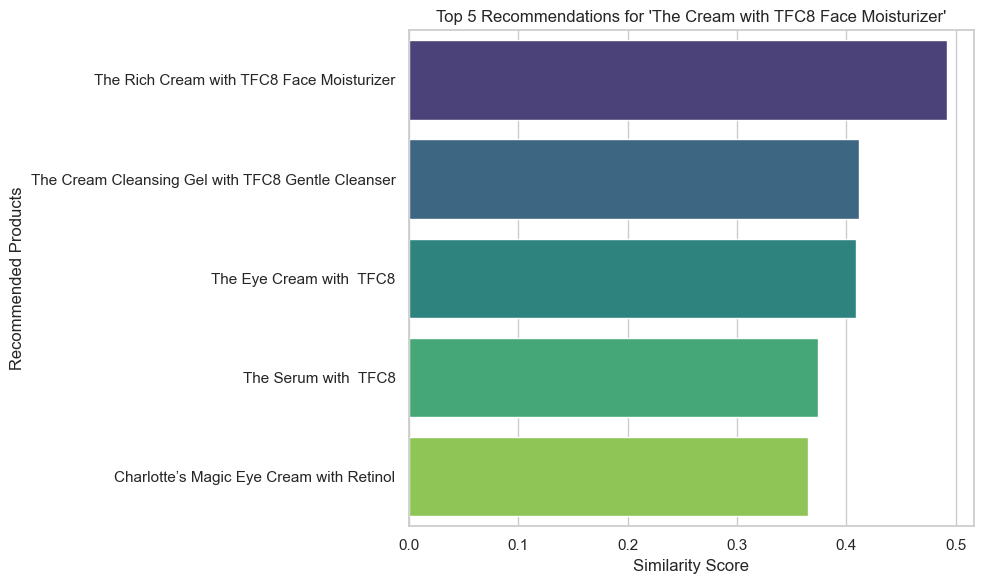

In [436]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_recommendations(recommended_products, product_id, df=df_sample):
    # Retrieve the product name for the queried product_id
    product_name = df[df['product_id'] == product_id]['product_name'].iloc[0]
    
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=recommended_products, 
        x='similarity_score', 
        y='product_name', 
        palette='viridis'
    )
    
    plt.xlabel('Similarity Score')
    plt.ylabel('Recommended Products')
    plt.title(f"Top 5 Recommendations for '{product_name}'")
    plt.tight_layout()
    plt.show()

# Example Usage
recommended_products = recommend_products_with_scores('P470507')
plot_recommendations(recommended_products, 'P470507')


Clustering based on the cosine similarity
- k-means

In [280]:
from sklearn.cluster import KMeans
import numpy as np

# Let's assume 'cosine_sim' is the cosine similarity matrix already calculated

# Number of clusters, you can experiment with different values
num_clusters = 5

# Apply K-Means clustering using the similarity matrix (this requires the cosine similarity matrix to be a dense matrix)
# We will first convert cosine_sim into a distance matrix (since KMeans uses distances)
distance_matrix = 1 - cosine_sim  # Cosine similarity to distance: 1 - similarity

# KMeans clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(distance_matrix)

# Add cluster labels to the original dataframe
df_sample['kmeans_cluster'] = clusters

# Display the cluster assignments for each product
print(df_sample[['product_id', 'product_name', 'kmeans_cluster']].head())

# You can analyze the products in each cluster
clustered_products = df_sample.groupby('kmeans_cluster').apply(lambda x: x[['product_id', 'product_name']])
print(clustered_products)


       product_id  \
487974    P434548   
430293    P428095   
599977    P447592   
739918    P459141   
151582    P381030   

                                                       product_name  \
487974                   Honeymoon Glow AHA Resurfacing Night Serum   
430293                            Ready Steady Glow Daily AHA Tonic   
599977                  Alpha Beta Pore Perfecting & Refining Serum   
739918  Deep Sweep 2% BHA Pore Cleaning Toner with Moringa + Papaya   
151582                  Dramatically Different Moisturizing Lotion+   

        kmeans_cluster  
487974               2  
430293               4  
599977               2  
739918               2  
151582               1  
                      product_id  \
kmeans_cluster                     
0              82749     P269122   
               831573    P468821   
               754878    P460779   
               995551    P482320   
               252925    P411401   
...                          ...   
4       

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/3213218952.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  clustered_products = df_sample.groupby('kmeans_cluster').apply(lambda x: x[['product_id', 'product_name']])


Content-Based Product Grouping:
The cluster groups are based on content similarity, meaning products within the same cluster share more textual features in common (e.g., product names, ingredients, or descriptions). This can provide insight into how products are perceived or described by customers.
Example Insight: You could look at the cluster descriptions to identify which product attributes (brand, ingredients, name) dominate certain clusters. If a cluster predominantly consists of products related to skincare, this could suggest a trend or market opportunity within the skincare domain.

In [287]:
# Loop through each cluster and look at the top products in each cluster
for cluster_id in df_sample['kmeans_cluster'].unique():
    print(f"\nCluster {cluster_id} Products:")
    cluster_products = df_sample[df_sample['kmeans_cluster'] == cluster_id]
    # Display the top 5 products in this cluster
    print(cluster_products[['product_id', 'product_name', 'brand_name', 'ingredients']].head())


Cluster 2 Products:
       product_id  \
487974    P434548   
599977    P447592   
739918    P459141   
549822    P442839   
290753    P417238   

                                                       product_name  \
487974                   Honeymoon Glow AHA Resurfacing Night Serum   
599977                  Alpha Beta Pore Perfecting & Refining Serum   
739918  Deep Sweep 2% BHA Pore Cleaning Toner with Moringa + Papaya   
549822             Barrier+ Triple Lipid-Peptide Lotion Moisturizer   
290753                   Green Clean Makeup Removing Cleansing Balm   

                       brand_name  \
487974                    Farmacy   
599977  Dr. Dennis Gross Skincare   
739918                    Farmacy   
549822                    Skinfix   
290753                    Farmacy   

                                                                                                ingredients  
487974  ['Water/Aqua/Eau, Lactic Acid, Propanediol, Jojoba Esters, Glycolic Acid, Potassium 

In [291]:
# Most common brands per cluster
cluster_brand_freq = df_sample.groupby('kmeans_cluster')['brand_name'].apply(lambda x: x.value_counts().idxmax())
print("Most common brand in each cluster:")
print(cluster_brand_freq)

# Most common ingredients per cluster
cluster_ingredient_freq = df_sample.groupby('kmeans_cluster')['ingredients'].apply(lambda x: x.value_counts().idxmax())
print("\nMost common ingredient in each cluster:")
print(cluster_ingredient_freq)

Most common brand in each cluster:
kmeans_cluster
0           The Ordinary
1           The Ordinary
2            Glow Recipe
3                 Tatcha
4    Youth To The People
Name: brand_name, dtype: object

Most common ingredient in each cluster:
kmeans_cluster
0    ['Aqua (Water), Niacinamide, Pentylene Glycol, Zinc PCA, Dimethyl Isosorbide, Tamarindus Indica ...
1    ['Salicylic Acid 0.5%, Aloe Barbadensis (Aloe Vera) Leaf Extract, Retinyl Acetate (Vitamin A), H...
2    ['Water/Eau/Aqua, Caprylic/Capric Triglyceride, Glycerin, Butyrospermum Parkii (Shea) Butter, Ve...
3    ['Aqua/Water/Eau, Saccharomyces/Rice Ferment Filtrate, Glycerin, Propanediol, Dimethicone, Squal...
4    ['Prunus Amygdalus Dulcis (Sweet Almond) Oil, Cetearyl Alcohol, PEG-6 Caprylic/Capric Glycerides...
Name: ingredients, dtype: object


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/195474421.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='count', y='brand_name', hue='kmeans_cluster', data=top_brands_per_cluster, ci=None)


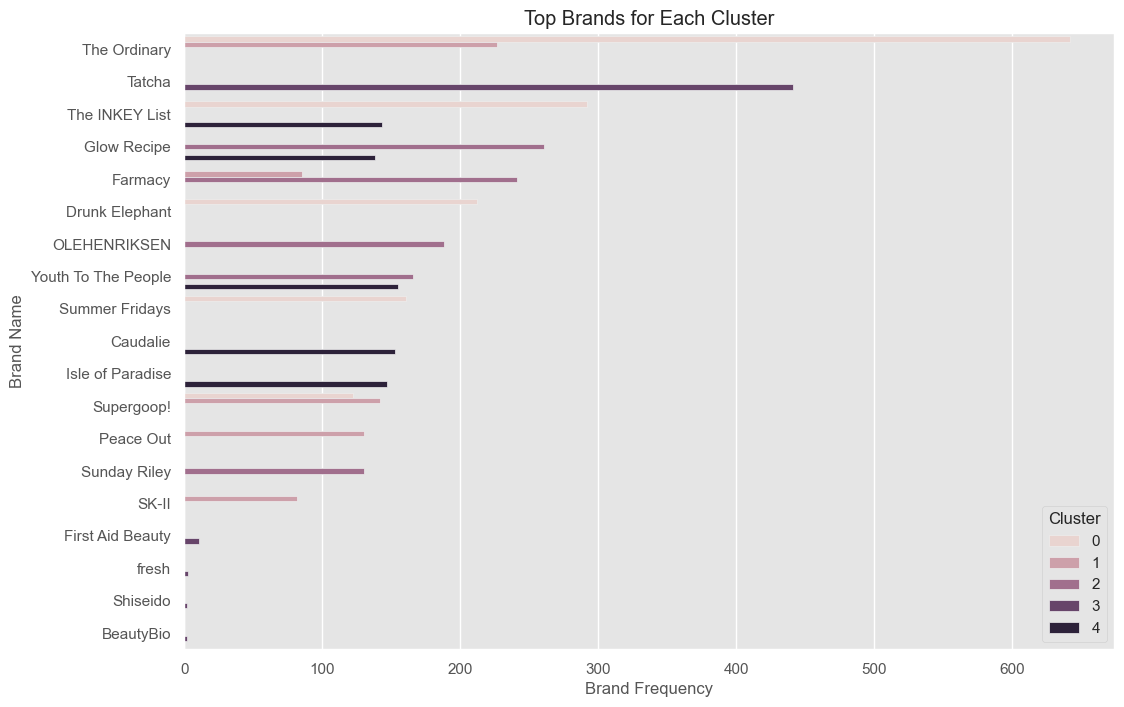

In [293]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group the DataFrame by 'kmeans_cluster' and 'brand_name' to count occurrences
brand_cluster_counts = df_sample.groupby(['kmeans_cluster', 'brand_name']).size().reset_index(name='count')

# Get the top brands for each cluster
top_brands_per_cluster = brand_cluster_counts.sort_values('count', ascending=False).groupby('kmeans_cluster').head(5)  # Top 5 brands per cluster

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='brand_name', hue='kmeans_cluster', data=top_brands_per_cluster, ci=None)
plt.title('Top Brands for Each Cluster')
plt.xlabel('Brand Frequency')
plt.ylabel('Brand Name')
plt.legend(title='Cluster')
plt.show()


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/3635395118.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='count', y='product_name', hue='kmeans_cluster', data=top_products_per_cluster, ci=None)


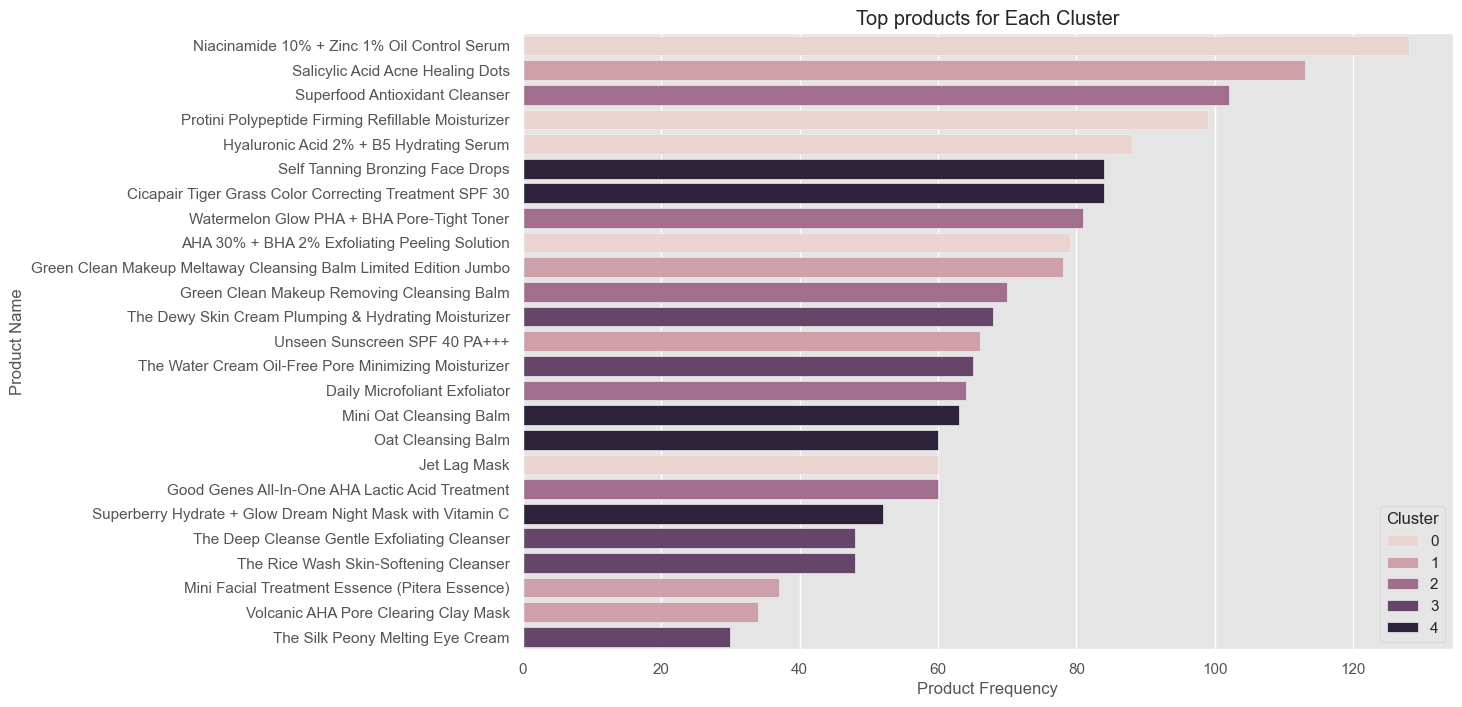

In [296]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group the DataFrame by 'kmeans_cluster' and 'brand_name' to count occurrences
products_cluster_counts = df_sample.groupby(['kmeans_cluster', 'product_name']).size().reset_index(name='count')

# Get the top brands for each cluster
top_products_per_cluster = products_cluster_counts.sort_values('count', ascending=False).groupby('kmeans_cluster').head(5)  # Top 5 brands per cluster

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x='count', y='product_name', hue='kmeans_cluster', data=top_products_per_cluster, ci=None)
plt.title('Top products for Each Cluster')
plt.xlabel('Product Frequency')
plt.ylabel('Product Name')
plt.legend(title='Cluster')
plt.show()

In [297]:
top_products_per_cluster

,kmeans_cluster,product_name,count
130,0,Niacinamide 10% + Zinc 1% Oil Control Serum,128
399,1,Salicylic Acid Acne Healing Dots,113
652,2,Superfood Antioxidant Cleanser,102
146,0,Protini Polypeptide Firming Refillable Moisturizer,99
91,0,Hyaluronic Acid 2% + B5 Hydrating Serum,88
1025,4,Self Tanning Bronzing Face Drops,84
797,4,Cicapair Tiger Grass Color Correcting Treatment SPF 30,84
697,2,Watermelon Glow PHA + BHA Pore-Tight Toner,81
9,0,AHA 30% + BHA 2% Exfoliating Peeling Solution,79
322,1,Green Clean Makeup Meltaway Cleansing Balm Limited Edition Jumbo,78



### Analysis for Cluster 0 ###


/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1105046485.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='product_name', data=top_rated_products, palette="coolwarm")


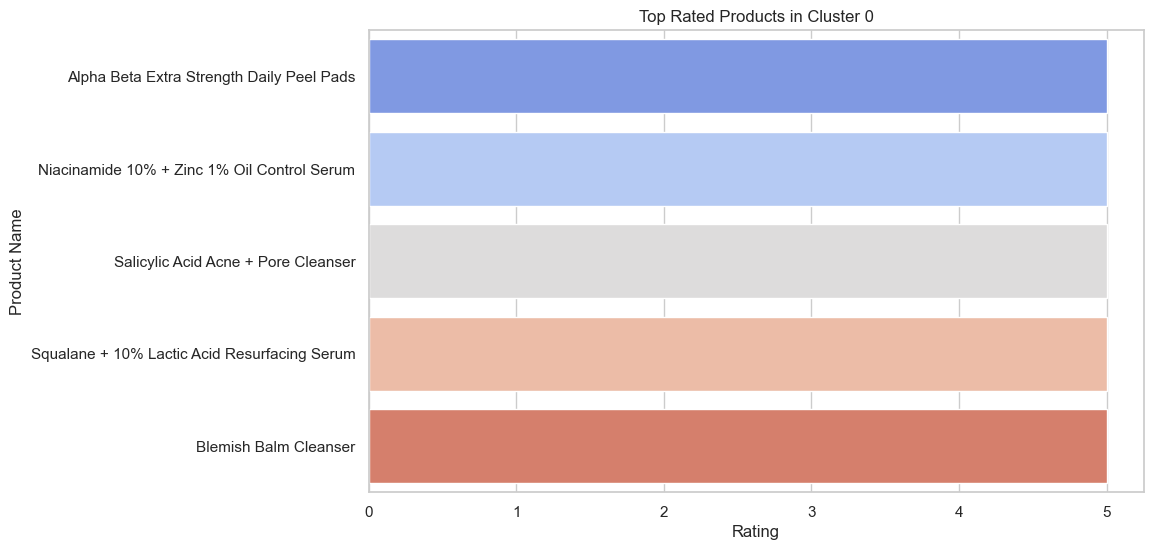

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1105046485.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=cluster_df, palette="viridis")


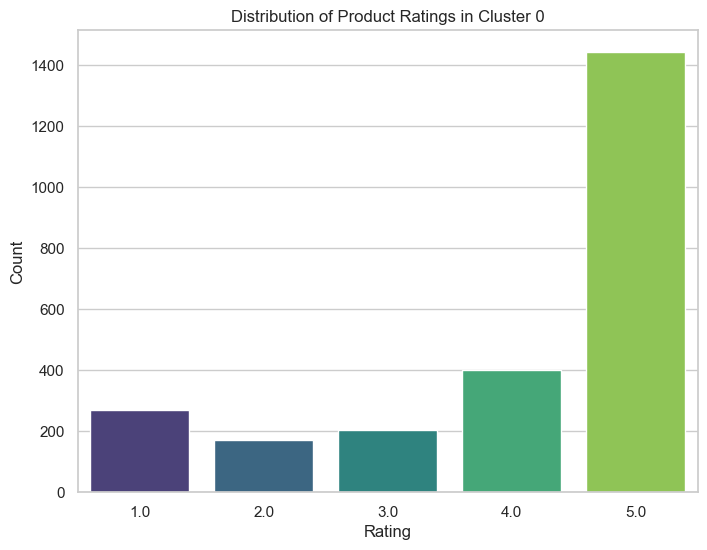

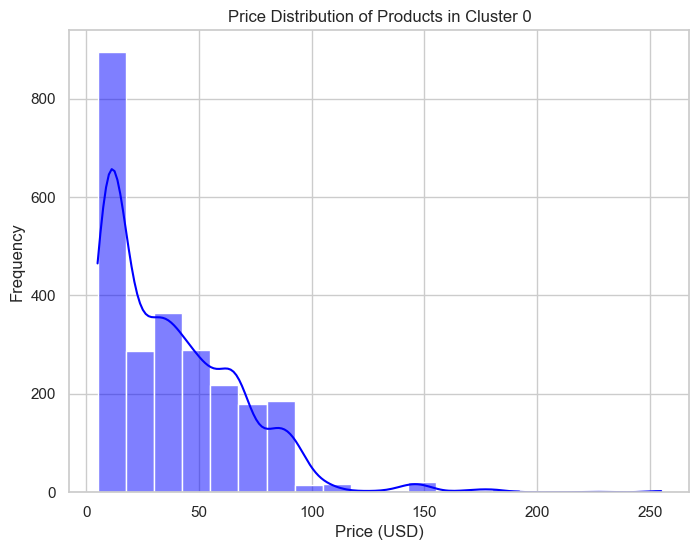

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1105046485.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="Blues_d")


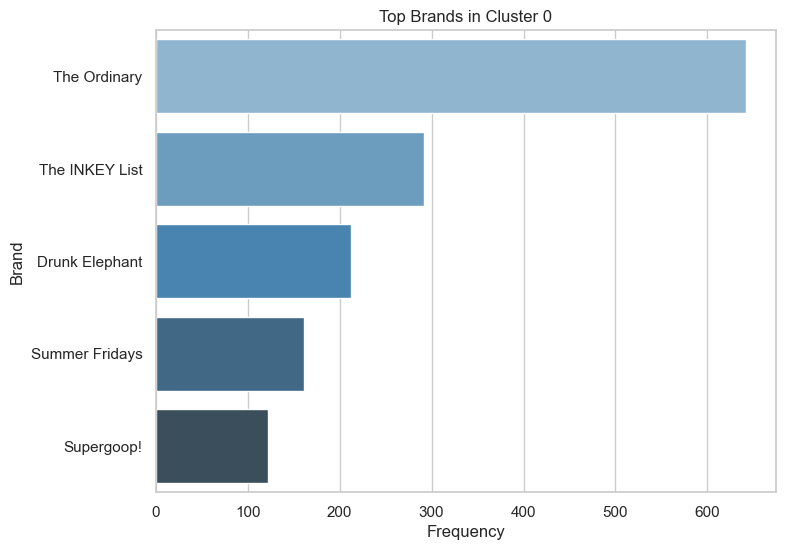

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1105046485.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rating', y='product_name', data=top_rated_products, palette="coolwarm")



### Analysis for Cluster 1 ###


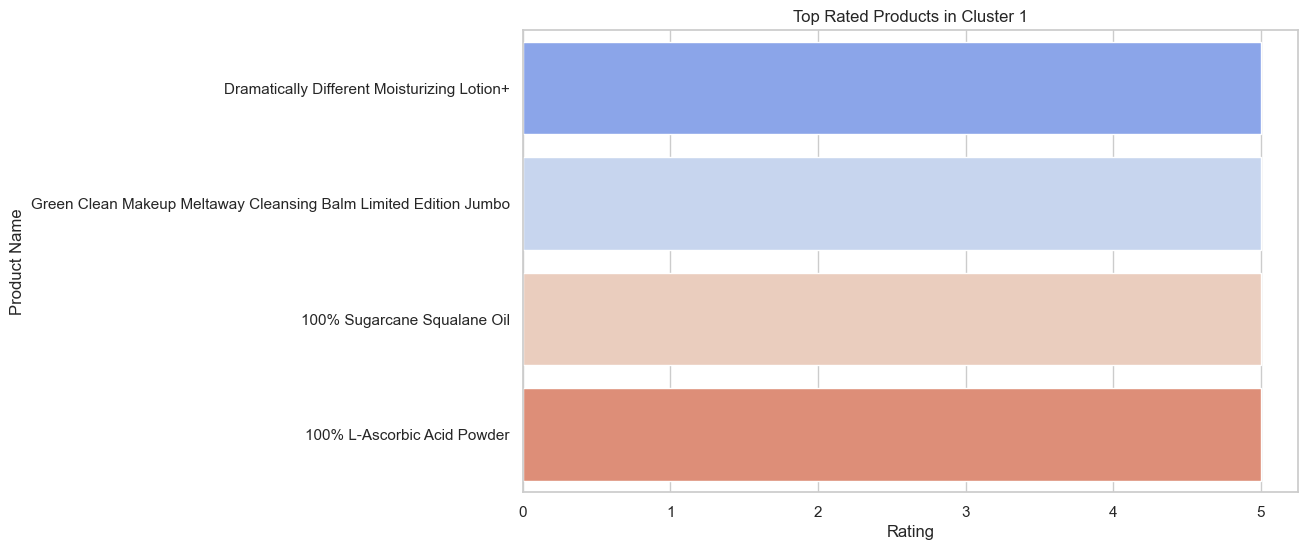

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1105046485.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=cluster_df, palette="viridis")


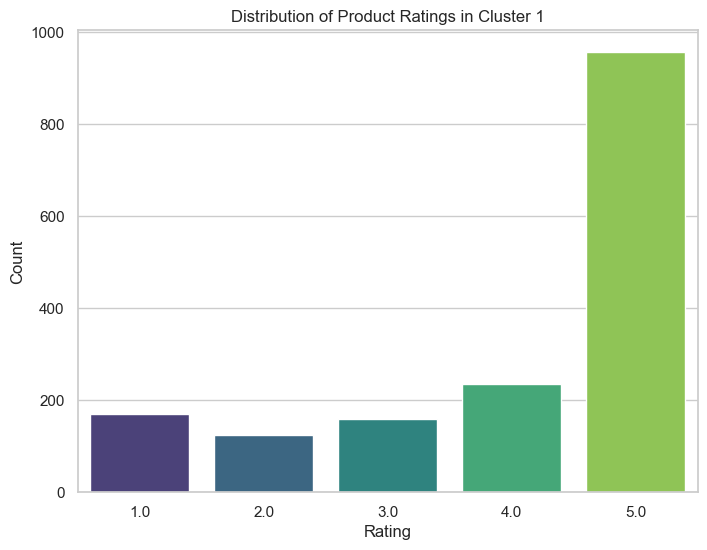

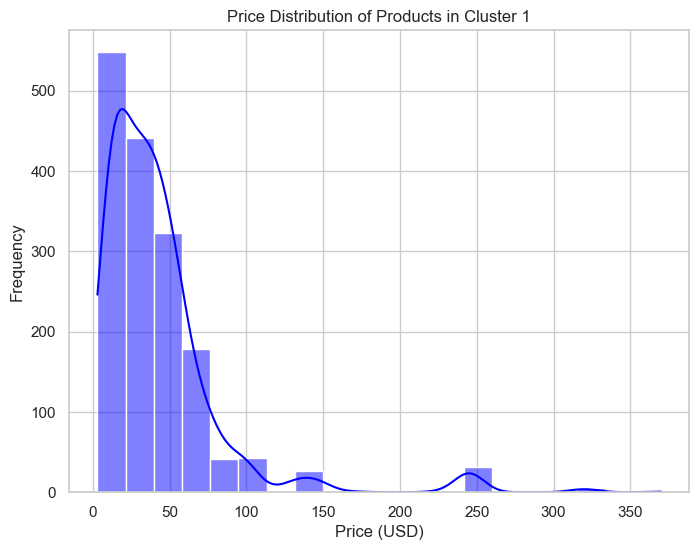

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1105046485.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="Blues_d")


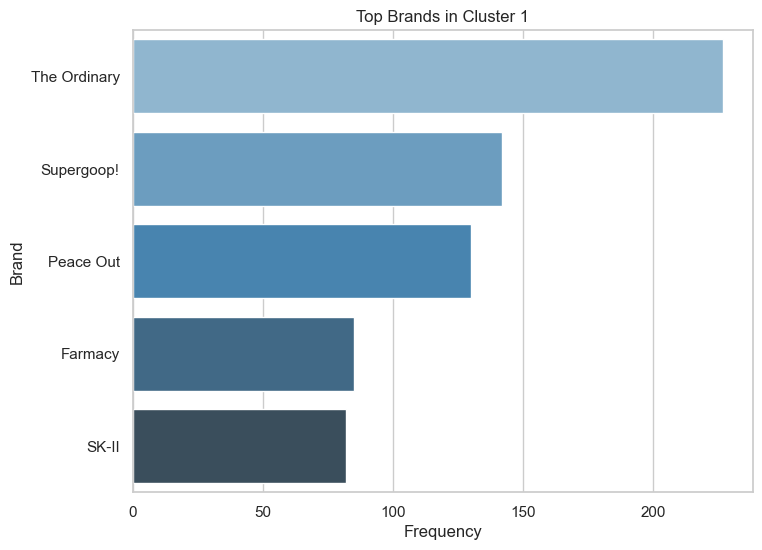

In [346]:
import matplotlib.pyplot as plt
import seaborn as sns

clusters = df_sample['kmeans_cluster'].unique()
selected_clusters = [0, 1]
for cluster in selected_clusters:
    print(f"\n### Analysis for Cluster {cluster} ###")
    
    # Filter the DataFrame for the current cluster
    cluster_df = df_sample[df_sample['kmeans_cluster'] == cluster]
    
    # 1. Top Rated Products
    cluster_sorted = cluster_df.sort_values(by='rating', ascending=False)
    top_rated_products = cluster_sorted[['product_name', 'brand_name', 'rating', 'price_usd']].head(5)  # Top 5 for the plot
    #print("\nTop Rated Products:")
    #print(top_rated_products)

    # Plot Top Rated Products in Cluster
    plt.figure(figsize=(10, 6))
    sns.barplot(x='rating', y='product_name', data=top_rated_products, palette="coolwarm")
    plt.title(f'Top Rated Products in Cluster {cluster}')
    plt.xlabel('Rating')
    plt.ylabel('Product Name')
    plt.show()
    
    # 2. Combination Skin Recommendations
    combination_skin_df = cluster_df[cluster_df['skin_type'] == 'combination']
    combination_skin_products = combination_skin_df[['product_name', 'brand_name', 'skin_type', 'rating', 'price_usd']].head(3)
    #print("\nProducts for Combination Skin:")
    #print(combination_skin_products)
    
    # 3. Recommendations for Loyal Customers
    loyal_customers_df = cluster_df[cluster_df['customer_behavior'] == 'Loyal']
    loyal_products = loyal_customers_df[['product_name', 'brand_name', 'customer_behavior', 'rating', 'price_usd']].head(3)
    #print("\nRecommended Products for Loyal Customers:")
    #print(loyal_products)
    
    # 4. Affordable Products (Price Range)
    affordable_products_df = cluster_df[(cluster_df['price_usd'] >= 20) & (cluster_df['price_usd'] <= 60)]
    affordable_products = affordable_products_df[['product_name', 'brand_name', 'price_usd', 'rating']].head(3)
    #print("\nAffordable Products:")
   # print(affordable_products)

    # 5. Distribution of Product Ratings in Cluster
    plt.figure(figsize=(8, 6))
    sns.countplot(x='rating', data=cluster_df, palette="viridis")
    plt.title(f'Distribution of Product Ratings in Cluster {cluster}')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.show()

    # 6. Price Distribution in Cluster
    plt.figure(figsize=(8, 6))
    sns.histplot(cluster_df['price_usd'], bins=20, kde=True, color='blue')
    plt.title(f'Price Distribution of Products in Cluster {cluster}')
    plt.xlabel('Price (USD)')
    plt.ylabel('Frequency')
    plt.show()
    
    # 7. Top Brands in Cluster
    top_brands = cluster_df['brand_name'].value_counts().head(5)  # Top 5 brands
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_brands.values, y=top_brands.index, palette="Blues_d")
    plt.title(f'Top Brands in Cluster {cluster}')
    plt.xlabel('Frequency')
    plt.ylabel('Brand')
    plt.show()


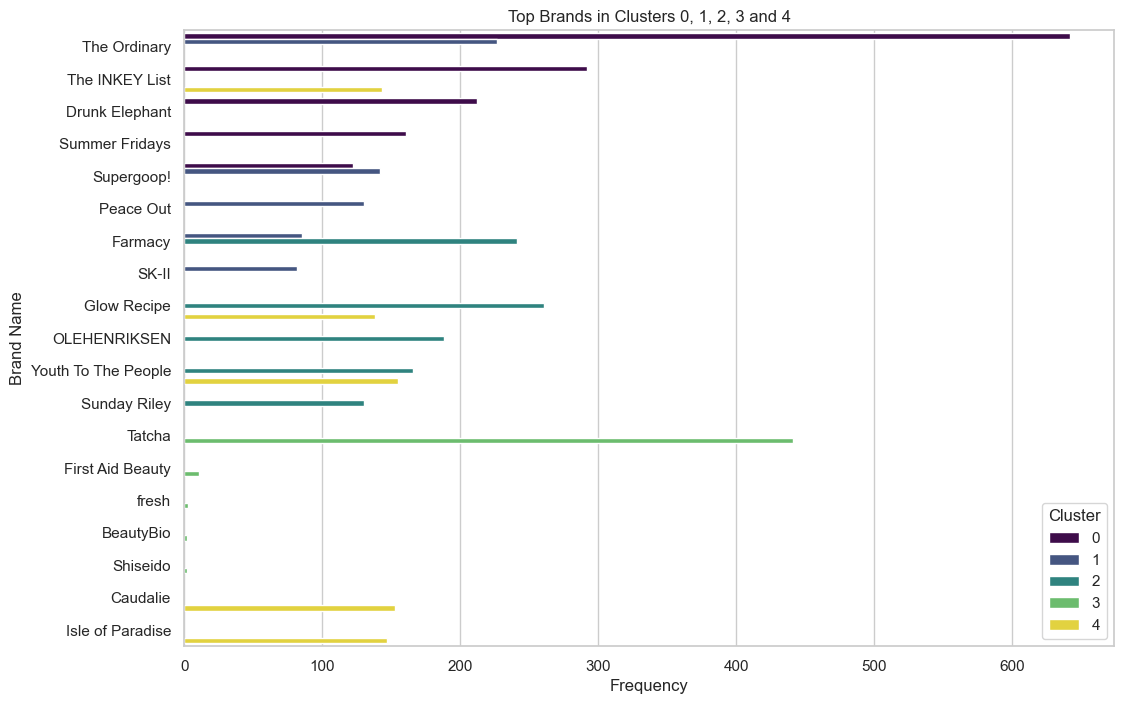

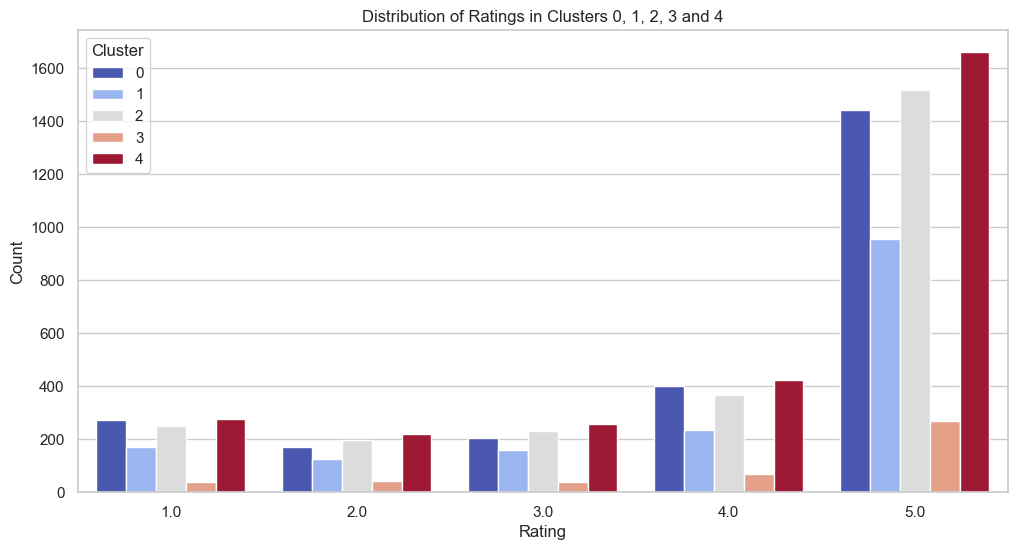

/var/folders/kl/7gdtx_110_17mw4gvs45lvxc0000gn/T/ipykernel_31411/1398705601.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='kmeans_cluster', y='price_usd', data=filtered_df, palette='Set3')


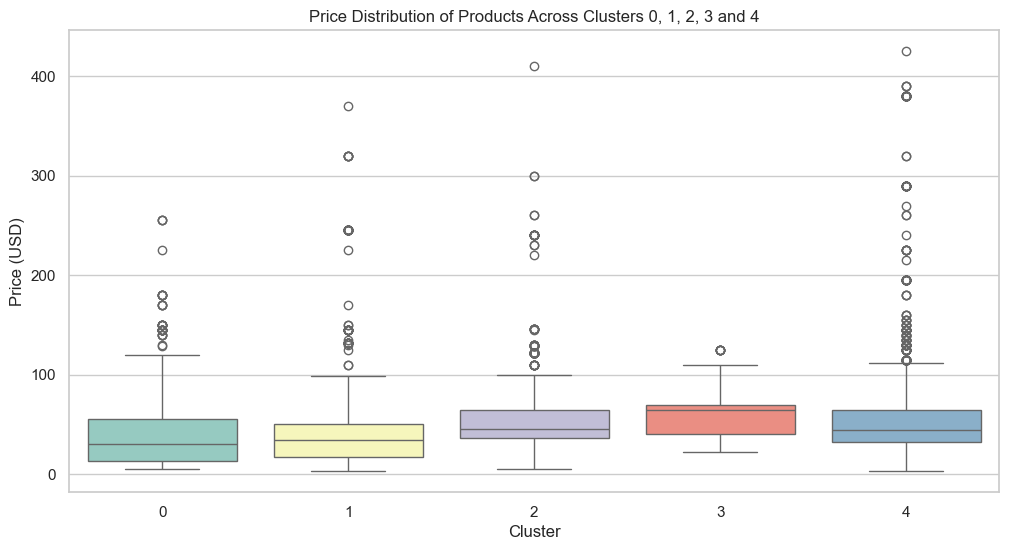

In [351]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filter data for selected clusters (0, 1, 2)
selected_clusters = [0, 1, 2, 3, 4]
filtered_df = df_sample[df_sample['kmeans_cluster'].isin(selected_clusters)]

### 1. Top Brands Across Clusters ###
# Count top 5 brands per cluster
top_brands_cluster = (
    filtered_df.groupby(['kmeans_cluster', 'brand_name'])
    .size()
    .reset_index(name='count')
    .sort_values(['kmeans_cluster', 'count'], ascending=[True, False])
)

# Select top 5 brands in each cluster
top_brands_cluster = top_brands_cluster.groupby('kmeans_cluster').head(5)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    x='count', y='brand_name', hue='kmeans_cluster', data=top_brands_cluster, palette='viridis'
)
plt.title('Top Brands in Clusters 0, 1, 2, 3 and 4')
plt.xlabel('Frequency')
plt.ylabel('Brand Name')
plt.legend(title='Cluster')
plt.show()

### 2. Distribution of Ratings Across Clusters ###
plt.figure(figsize=(12, 6))
sns.countplot(x='rating', hue='kmeans_cluster', data=filtered_df, palette='coolwarm')
plt.title('Distribution of Ratings in Clusters 0, 1, 2, 3 and 4')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

### 3. Price Distribution Across Clusters ###
plt.figure(figsize=(12, 6))
sns.boxplot(x='kmeans_cluster', y='price_usd', data=filtered_df, palette='Set3')
plt.title('Price Distribution of Products Across Clusters 0, 1, 2, 3 and 4')
plt.xlabel('Cluster')
plt.ylabel('Price (USD)')
plt.show()


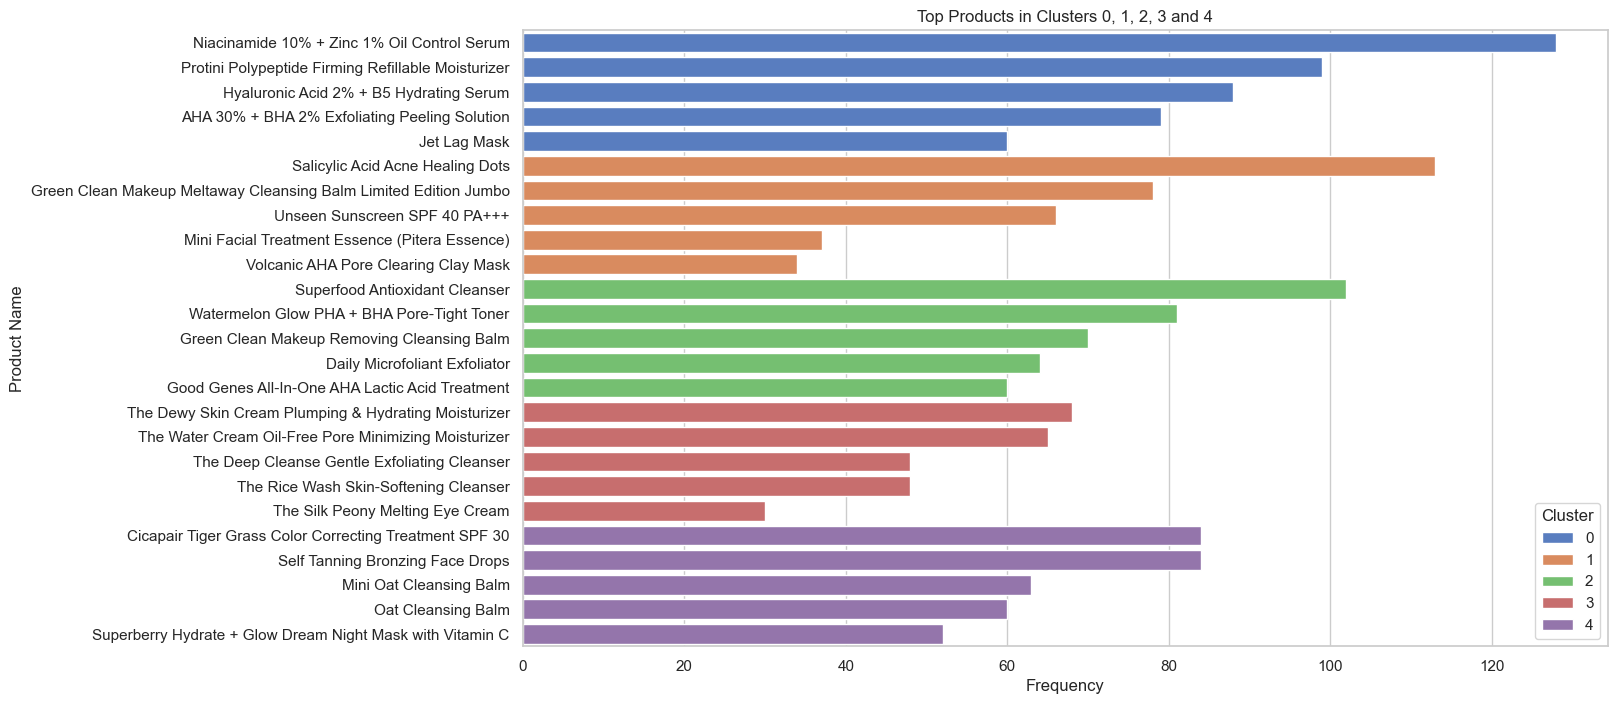

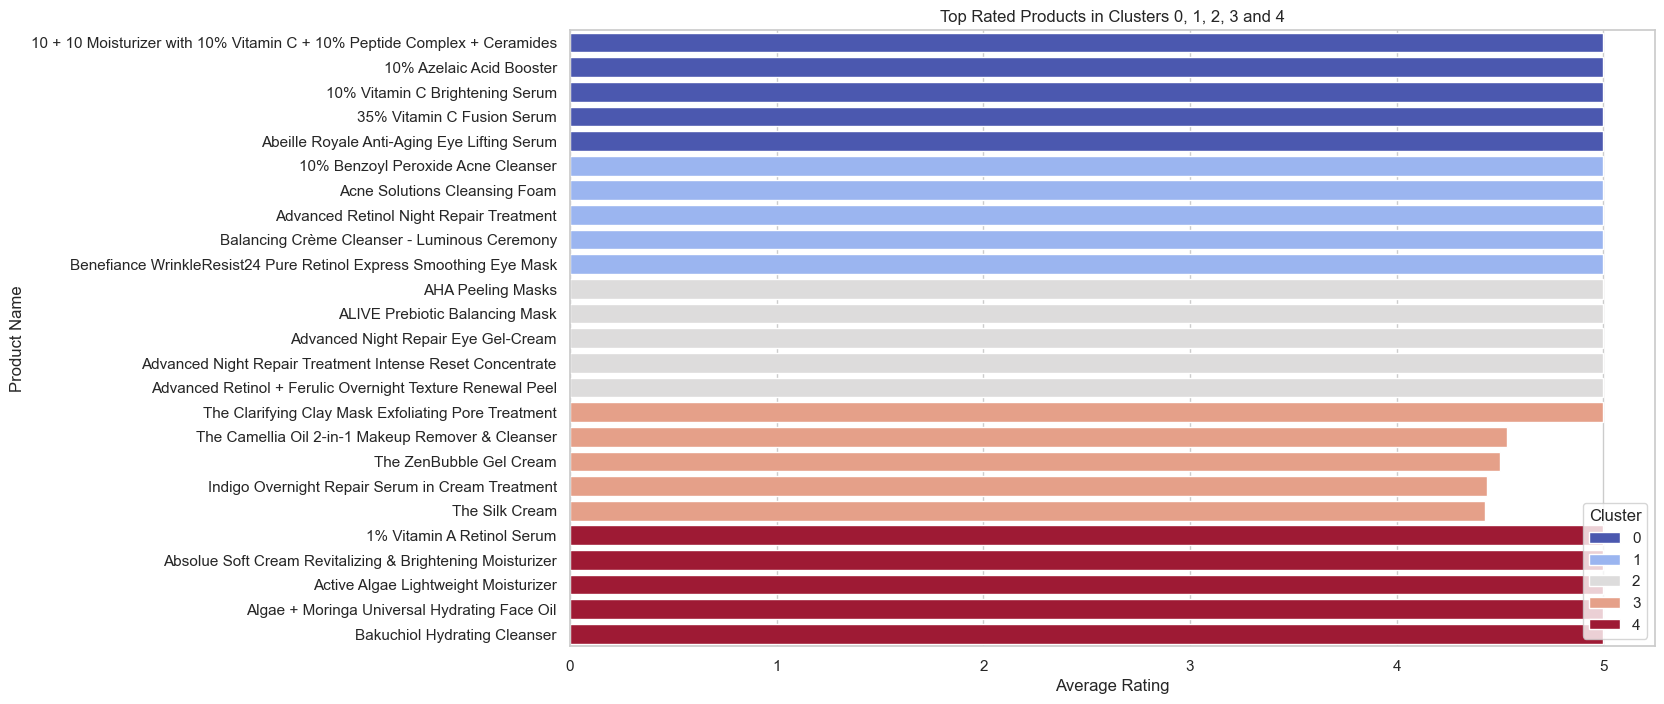

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select clusters 0, 1, and 2
selected_clusters = [0, 1, 2, 3, 4]
filtered_df = df_sample[df_sample['kmeans_cluster'].isin(selected_clusters)]

### 1. Top Products in Each Cluster (by Frequency) ###
# Group by cluster and product_name, count occurrences
top_products_cluster = (
    filtered_df.groupby(['kmeans_cluster', 'product_name'])
    .size()
    .reset_index(name='count')
    .sort_values(['kmeans_cluster', 'count'], ascending=[True, False])
)

# Select top 5 products in each cluster
top_products_cluster = top_products_cluster.groupby('kmeans_cluster').head(5)

# Plot top products by cluster
plt.figure(figsize=(14, 8))
sns.barplot(
    x='count', 
    y='product_name', 
    hue='kmeans_cluster', 
    data=top_products_cluster, 
    palette='muted'
)
plt.title('Top Products in Clusters 0, 1, 2, 3 and 4')
plt.xlabel('Frequency')
plt.ylabel('Product Name')
plt.legend(title='Cluster')
plt.show()

### 2. Top Rated Products by Cluster ###
# Sort by rating and select top-rated products
top_rated_products_cluster = (
    filtered_df.groupby(['kmeans_cluster', 'product_name'])['rating']
    .mean()
    .reset_index()
    .sort_values(['kmeans_cluster', 'rating'], ascending=[True, False])
)

# Select top 5 rated products per cluster
top_rated_products_cluster = top_rated_products_cluster.groupby('kmeans_cluster').head(5)

# Plot top-rated products
plt.figure(figsize=(14, 8))
sns.barplot(
    x='rating', 
    y='product_name', 
    hue='kmeans_cluster', 
    data=top_rated_products_cluster, 
    palette='coolwarm'
)
plt.title('Top Rated Products in Clusters 0, 1, 2, 3 and 4')
plt.xlabel('Average Rating')
plt.ylabel('Product Name')
plt.legend(title='Cluster')
plt.show()




### Trying to cluster using k-means/dbscan based on 'rating', 'helpfulness', 'total_feedback_count', 'total_pos_feedback_count', 'total_neg_feedback_count'

In [142]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = df_cleaned[['rating', 'helpfulness', 'total_feedback_count', 'total_pos_feedback_count', 'total_neg_feedback_count']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [143]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_cleaned['cluster'] = kmeans.fit_predict(scaled_features)


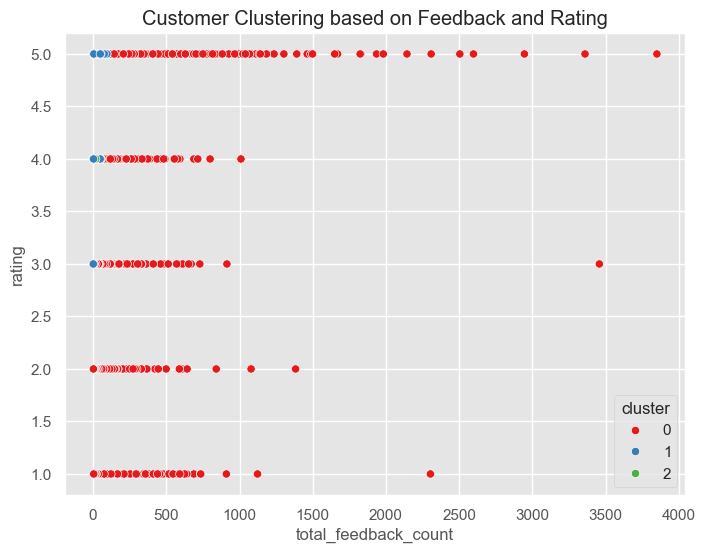

In [144]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df_cleaned['total_feedback_count'], y=df_cleaned['rating'], hue=df_cleaned['cluster'], palette='Set1')
plt.title("Customer Clustering based on Feedback and Rating")
plt.show()


In [145]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns

In [147]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df_cleaned['dbscan_cluster'] = dbscan.fit_predict(scaled_features)


In [148]:
unique_clusters = df_cleaned['dbscan_cluster'].unique()
print(f"Clusters found: {unique_clusters}")


Clusters found: [ 0  1  2  3  4 -1 30 28  5  6  7  8 23 26 14  9 10 11 20 12 13 15 16 17
 18 27 19 21 22 25 24 29]


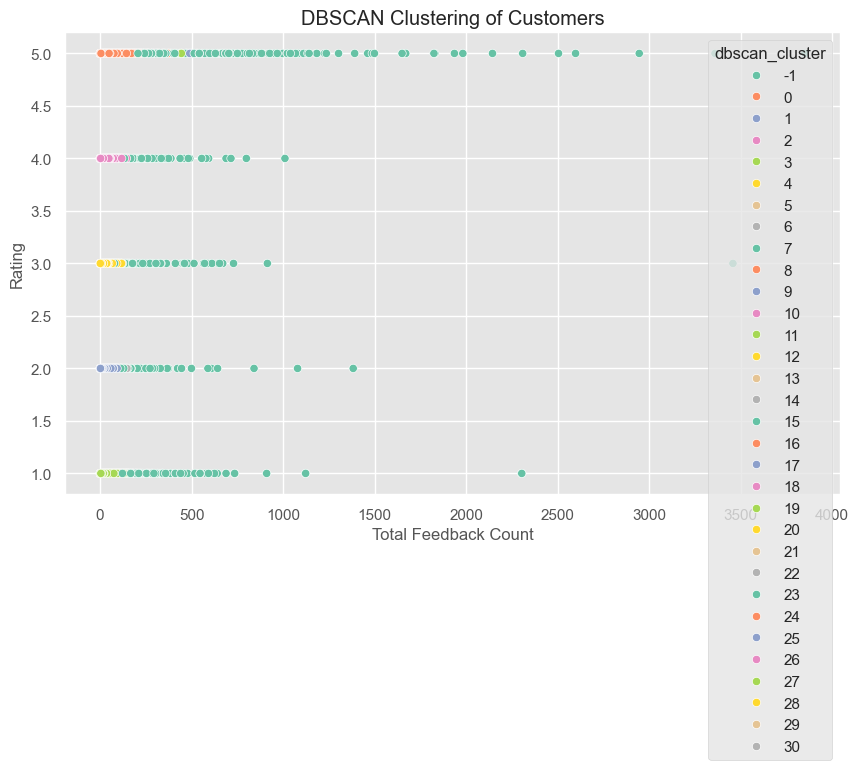

In [149]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_cleaned['total_feedback_count'],
    y=df_cleaned['rating'],
    hue=df_cleaned['dbscan_cluster'],
    palette='Set2',
    legend='full'
)
plt.title("DBSCAN Clustering of Customers")
plt.xlabel("Total Feedback Count")
plt.ylabel("Rating")
plt.show()


# Can we predict the success of products or brands?
By examining user purchasing behavior, reviews, and other relevant insights, we can forecast the potential success of products and brands.


In [150]:
df_recommendation = df_cleaned.copy()

In [151]:
df_recommendation.columns

Index(['rating', 'is_recommended', 'helpfulness', 'total_feedback_count',
       'total_neg_feedback_count', 'total_pos_feedback_count',
       'submission_time', 'review_text', 'skin_tone', 'eye_color', 'skin_type',
       'hair_color', 'product_id', 'product_name', 'brand_name', 'price_usd',
       'brand_id', 'child_count', 'highlights', 'ingredients',
       'limited_edition', 'loves_count', 'new', 'online_only', 'out_of_stock',
       'primary_category', 'reviews', 'secondary_category',
       'sephora_exclusive', 'size', 'tertiary_category', 'variation_type',
       'variation_value', 'year', 'month', 'day', 'weekday', 'dayofweek',
       'customer_behavior', 'cluster', 'dbscan_cluster'],
      dtype='object')

In [152]:
%pip install textblob

Note: you may need to restart the kernel to use updated packages.


extracting sentiment from reviews using TextBlob

In [153]:
from textblob import TextBlob

df_recommendation['review_sentiment'] = df_recommendation['review_text'].apply(lambda x: TextBlob(x).sentiment.polarity)


Classification Problem:
Predict whether a product will be successful (e.g., high sales, positive ratings).

In [ ]:
df_recommendation.columns

A product is considered successful if:
- Its rating is greater than or equal to 4.5 (i.e., a high rating).
- Its loves_count is greater than the average loves_count across all products (i.e., more love from customers compared to the mean value).

In [370]:
import numpy as np

# Define criteria for success: products with high ratings or a high loves_count
df_recommendation['success_label'] = np.where((df_recommendation['rating'] >= 4.5) & (df_recommendation['loves_count'] > df_recommendation['loves_count'].mean()), 1, 0)



In [371]:
df_recommendation[['success_label', 'is_recommended']]

,success_label,is_recommended
277,0,1.0
278,0,1.0
279,0,1.0
280,0,1.0
282,0,1.0
...,...,...
1100307,0,1.0
1100311,0,1.0
1100312,0,0.0
1100313,0,1.0


In [372]:
df_recommendation['success_label'].value_counts()

success_label
0    245834
1     58566
Name: count, dtype: int64

We can see that the data is not balanced. I will do the analysis for both imblance and balanced dataset

Analysis for imbalance data

In [373]:
features = [
    'rating', 'is_recommended', 'helpfulness', 'total_feedback_count',
    'total_pos_feedback_count', 'total_neg_feedback_count',
    'price_usd', 'online_only', 'out_of_stock', 'review_sentiment'
]

X = df_recommendation[features]
y = df_recommendation['success_label']


In [378]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

In [379]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [380]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [381]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8641097240473061
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.92      0.92     49154
           1       0.66      0.62      0.64     11726

    accuracy                           0.86     60880
   macro avg       0.78      0.77      0.78     60880
weighted avg       0.86      0.86      0.86     60880



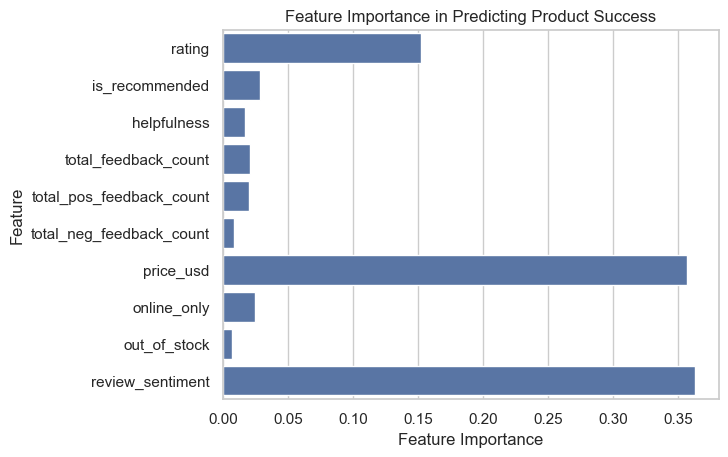

In [382]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
feature_importance = model.feature_importances_
sns.barplot(x=feature_importance, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Predicting Product Success')
plt.show()


balancing dataset by downsizing the majority class

In [383]:
import pandas as pd

# Separate the data into two groups based on the success_label
class_0 = df_recommendation[df_recommendation['success_label'] == 0]
class_1 = df_recommendation[df_recommendation['success_label'] == 1]

# Randomly sample from class_0 to match the size of class_1
class_0_downsampled = class_0.sample(n=len(class_1), random_state=42)

# Combine the downsampled class_0 with class_1
balanced_df = pd.concat([class_0_downsampled, class_1])

# Shuffle the combined dataset to mix both classes
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Check the distribution
print(balanced_df['success_label'].value_counts())


success_label
1    58566
0    58566
Name: count, dtype: int64


In [384]:
features = [
    'rating', 'is_recommended', 'helpfulness', 'total_feedback_count',
    'total_pos_feedback_count', 'total_neg_feedback_count',
    'price_usd', 'online_only', 'out_of_stock', 'review_sentiment'
]

X = balanced_df[features]
y = balanced_df['success_label']

In [385]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

In [386]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [387]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [388]:
from sklearn.metrics import accuracy_score, classification_report

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8427882357963035
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.81      0.84     11689
           1       0.82      0.87      0.85     11738

    accuracy                           0.84     23427
   macro avg       0.84      0.84      0.84     23427
weighted avg       0.84      0.84      0.84     23427



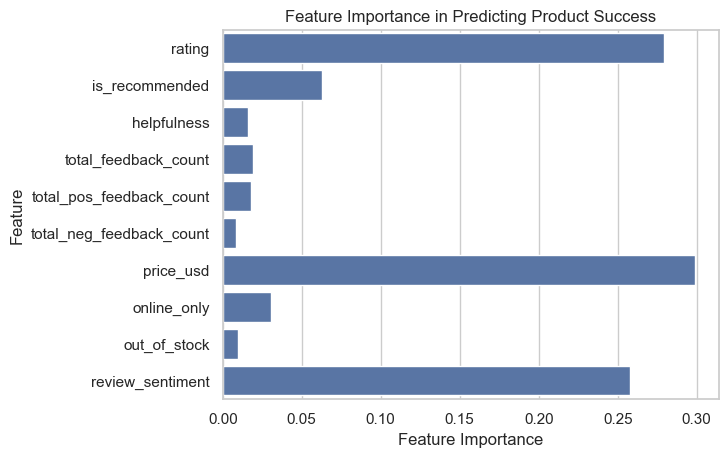

In [389]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance
feature_importance = model.feature_importances_
sns.barplot(x=feature_importance, y=features)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance in Predicting Product Success')
plt.show()

In [183]:
feature_importance

array([8.01656059e+00, 7.58544721e-02, 3.16965054e-01, 4.12868787e-03,
       2.87592355e-03, 7.00461142e-03, 1.34462206e-02, 2.62571599e+00,
       8.05928380e+00, 4.47062811e-01])

In [394]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Dictionary to store model results
model_results = {}

# List of models to try
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    #'Support Vector Machine': SVC(probability=True),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    #'Gradient Boosting': GradientBoostingClassifier(),
    'XGBoost': XGBClassifier(eval_metric='logloss')
}

# Train and evaluate each model
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    # Store results
    model_results[name] = {'Accuracy': acc, 'Report': report}

    print(f"Model: {name}")
    print(f"Accuracy: {acc:.2f}")
    print("Classification Report:")
    print(report)
    print("-" * 50)


Model: Logistic Regression
Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73     11689
           1       0.70      0.97      0.81     11738

    accuracy                           0.78     23427
   macro avg       0.83      0.78      0.77     23427
weighted avg       0.83      0.78      0.77     23427

--------------------------------------------------
Model: K-Nearest Neighbors
Accuracy: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79     11689
           1       0.77      0.88      0.82     11738

    accuracy                           0.81     23427
   macro avg       0.81      0.81      0.81     23427
weighted avg       0.81      0.81      0.81     23427

--------------------------------------------------
Model: XGBoost
Accuracy: 0.89
Classification Report:
              precision    recall  f1-score   support

      

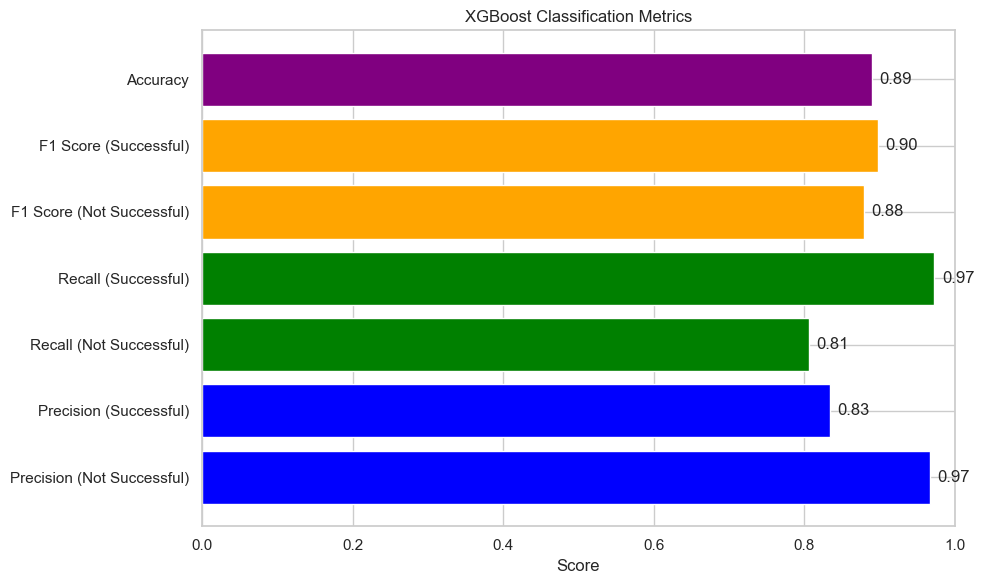

In [404]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Ensure xgboost_report is a dictionary by using output_dict=True during its creation
xgboost_report_dict = classification_report(
    y_test, 
    y_pred, 
    target_names=['Not Successful', 'Successful'], 
    output_dict=True  # Output as dict for easier extraction
)

# Extracting precision, recall, and F1 scores from the report dictionary
precision_not_successful = xgboost_report_dict['Not Successful']['precision']
recall_not_successful = xgboost_report_dict['Not Successful']['recall']
f1_not_successful = xgboost_report_dict['Not Successful']['f1-score']

precision_successful = xgboost_report_dict['Successful']['precision']
recall_successful = xgboost_report_dict['Successful']['recall']
f1_successful = xgboost_report_dict['Successful']['f1-score']

# Accuracy (already calculated)
accuracy = xgboost_report_dict['accuracy']

# Plotting metrics
metrics = {
    "Precision (Not Successful)": precision_not_successful,
    "Precision (Successful)": precision_successful,
    "Recall (Not Successful)": recall_not_successful,
    "Recall (Successful)": recall_successful,
    "F1 Score (Not Successful)": f1_not_successful,
    "F1 Score (Successful)": f1_successful,
    "Accuracy": accuracy
}

# Bar plot
plt.figure(figsize=(10, 6))
bars = plt.barh(
    list(metrics.keys()), 
    list(metrics.values()), 
    color=['blue', 'blue', 'green', 'green', 'orange', 'orange', 'purple']
)

# Adding value labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f'{width:.2f}', va='center')

plt.xlabel('Score')
plt.title('XGBoost Classification Metrics')
plt.xlim(0, 1)  # Limit x-axis to [0, 1]
plt.tight_layout()
plt.show()


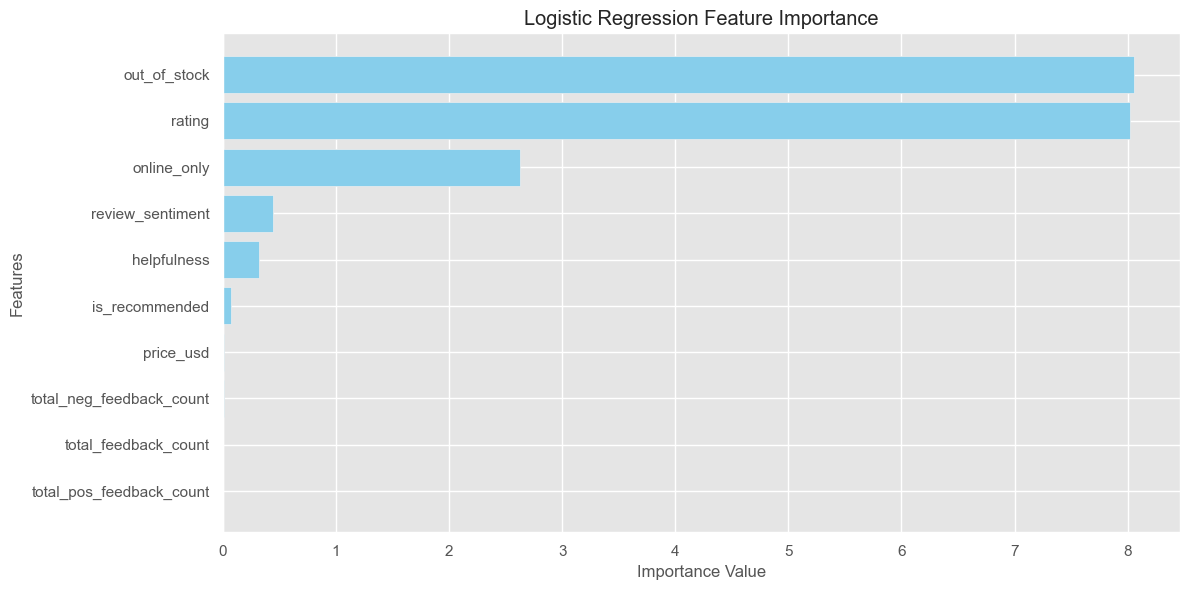

In [180]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_importance(features, importance, title):
    plt.figure(figsize=(12, 6))
    indices = np.argsort(importance)[::-1]
    
    plt.barh(np.array(features)[indices], importance[indices], color='skyblue')
    plt.xlabel("Importance Value")
    plt.ylabel("Features")
    plt.title(title)
    plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature at the top
    plt.tight_layout()
    plt.show()


# Logistic Regression Feature Importance
if 'Logistic Regression' in model_results:
    model = models['Logistic Regression']
    feature_importance = np.abs(model.coef_[0])
    feature_names = X_train.columns
    plot_feature_importance(feature_names, feature_importance, "Logistic Regression Feature Importance")



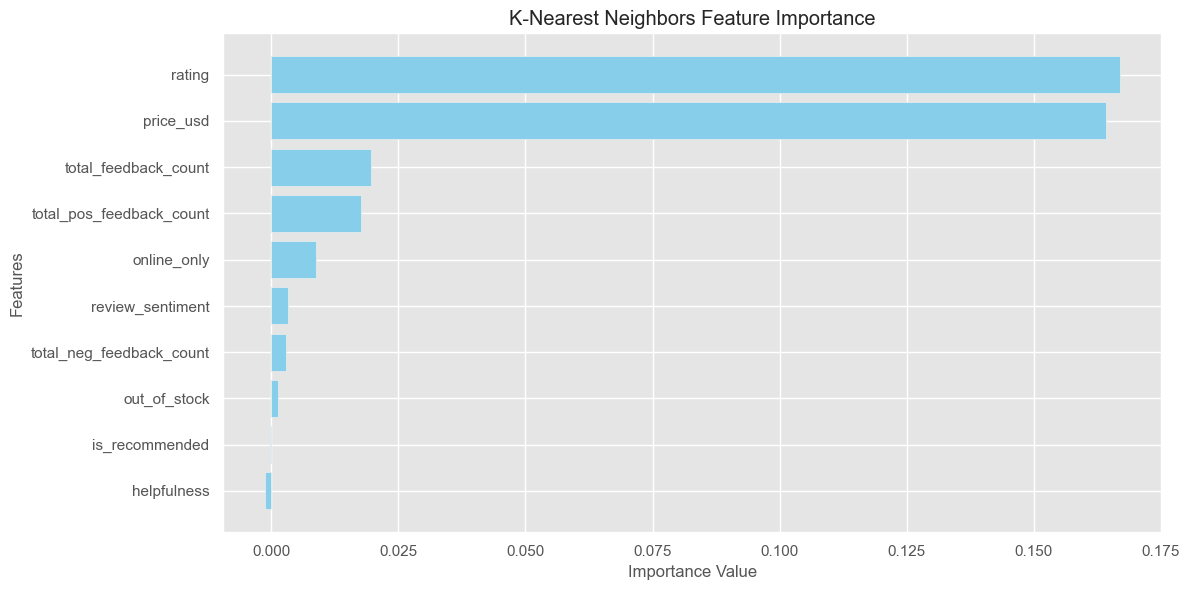

In [181]:
from sklearn.inspection import permutation_importance

# K-Nearest Neighbors Feature Importance using Permutation
if 'K-Nearest Neighbors' in model_results:
    model = models['K-Nearest Neighbors']
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
    perm_importance = result.importances_mean
    plot_feature_importance(X_train.columns, perm_importance, "K-Nearest Neighbors Feature Importance")


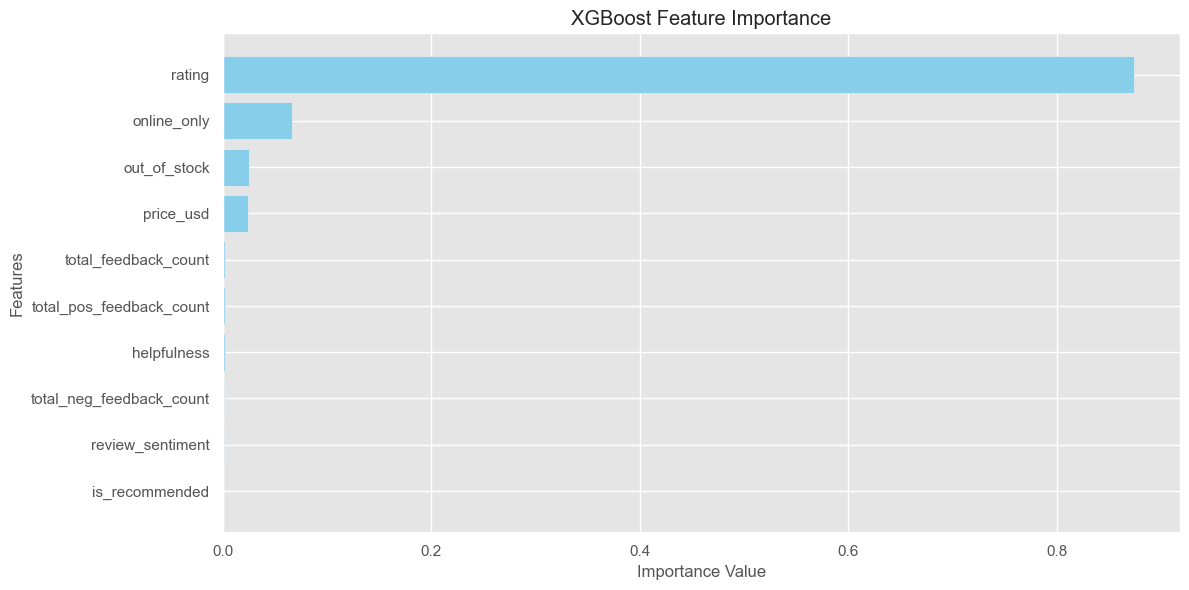

In [182]:
# XGBoost Feature Importance
if 'XGBoost' in model_results:
    model = models['XGBoost']
    xgb_importance = model.feature_importances_
    plot_feature_importance(X_train.columns, xgb_importance, "XGBoost Feature Importance")


In [184]:
xgb_importance

array([8.7440872e-01, 5.7881925e-04, 1.8692455e-03, 2.2765205e-03,
       1.9111444e-03, 1.3620040e-03, 2.4437495e-02, 6.6276006e-02,
       2.5562562e-02, 1.3174826e-03], dtype=float32)

In [187]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [199]:
def plot_confusion_matrix_heatmap_with_labels(y_test, y_pred, model_name, class_labels=['Not Successfull', 'Successfull']):
    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Create a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels, cbar=False, annot_kws={"size": 14})
    
    # Add labels and title
    plt.xlabel("Predicted Labels", fontsize=14)
    plt.ylabel("True Labels", fontsize=14)
    plt.title(f"Confusion Matrix for {model_name}", fontsize=16)
    
    plt.show()

Model: Logistic Regression
Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73     11689
           1       0.70      0.97      0.81     11738

    accuracy                           0.78     23427
   macro avg       0.83      0.78      0.77     23427
weighted avg       0.83      0.78      0.77     23427

--------------------------------------------------


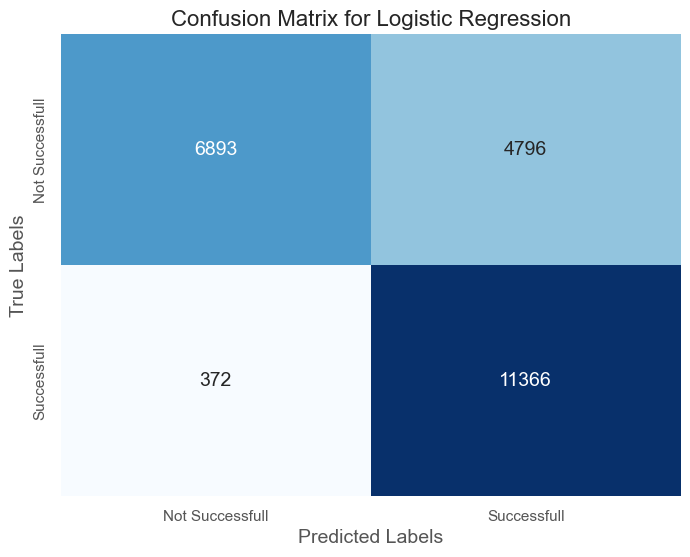

Model: K-Nearest Neighbors
Accuracy: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.75      0.82     11689
           1       0.79      0.91      0.84     11738

    accuracy                           0.83     23427
   macro avg       0.84      0.83      0.83     23427
weighted avg       0.84      0.83      0.83     23427

--------------------------------------------------


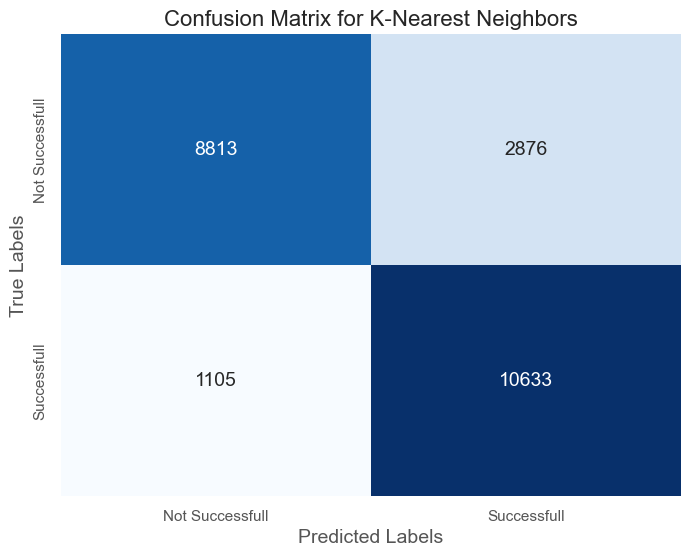

Model: XGBoost
Accuracy: 0.89
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.81      0.88     11689
           1       0.84      0.97      0.90     11738

    accuracy                           0.89     23427
   macro avg       0.90      0.89      0.89     23427
weighted avg       0.90      0.89      0.89     23427

--------------------------------------------------


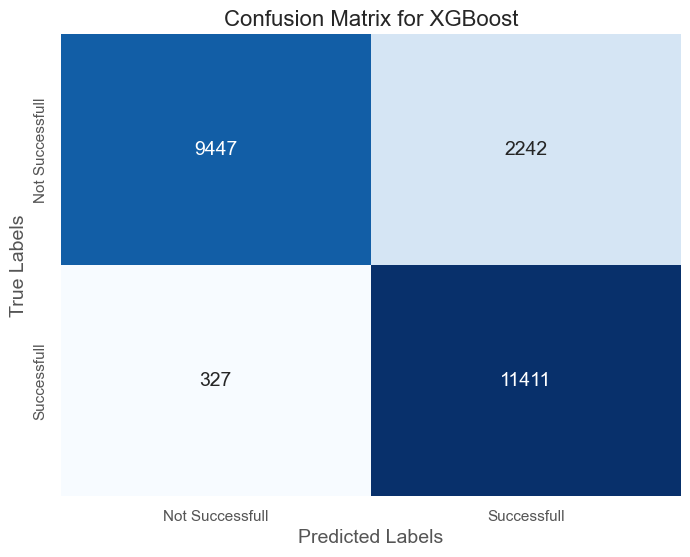

In [200]:
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluate the model
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    
    # Store results
    model_results[name] = {'Accuracy': acc, 'Report': report}
    
    # Print results
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.2f}")
    print("Classification Report:")
    print(report)
    print("-" * 50)
    
    # Plot the confusion matrix heatmap with class labels
    plot_confusion_matrix_heatmap_with_labels(y_test, y_pred, name)



Overall the XGBoost model outperforms well than ther outher models

#### Overall Insights and recommendation:

Predicting whether customers will recommend a product based on their review text can be highly valuable towards marketing, customer engagement, and retention strategies.
By using TF-IDF and cosine similarity, we can effectively measure how similar products are to each other. This helps identify related products that share similar attributes, enabling personalized recommendations. This will improve the shopping experience, fostering loyalty and trust.

Behavioral patterns across demographics reveals specific types of products or brands can be targeted for marketing. 
Provides clarity on which product features resonate with each customer segment.

Identifying product success indicates both customer satisfaction and emotional connection. 
Using negative sentiment feedback to identify areas for product improvement, while leveraging positive feedback for marketing.
Proactively addressing customer needs and concerns boosts satisfaction and loyalty.
